# Analisis Predictivo de Churn — Concesionario de Automoviles

**Objetivo:** Desarrollar un modelo de Machine Learning para predecir la fuga de clientes
del servicio de taller oficial, permitiendo implementar estrategias de retencion proactivas.

---

### Estructura del Notebook

**FASE 1: Exploracion y Preparacion de Datos**
1. Configuracion, importaciones y carga de datos
2. Analisis general del dataset
3. Analisis de churn (variable objetivo)
4. Perfil del cliente: churner vs no-churner
5. Analisis de revisiones y taller
6. Analisis economico (margenes y costes)
7. Correlaciones entre variables
8. Conclusiones previas al modelo + DataMart

**FASE 2: Modelado ML — Evolucion en 4 Enfoques**
- Enfoque 1: Baseline (Random Forest + XGBoost)
- Enfoque 2: Modelo de retencion (filtrado)
- Enfoque 3: Feature Engineering (`nunca_ha_venido`)
- **Enfoque 2: Eliminacion del leakage logico (modelo final)**

**FASE 3: Prediccion sobre Datos Fresh**
- Aplicacion del modelo final a 10,000 nuevos clientes

---

**Dataset:** 58,049 registros historicos (2018-2023) | 44,053 clientes unicos | 11 modelos

## 1. Configuracion, Importaciones y Carga de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Estilo global de los gráficos
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid")
COLORES = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']

print("✅ Librerías cargadas correctamente")

# Instalar librerias de ML si no estan disponibles
import subprocess
import sys

for lib in ['xgboost', 'lightgbm']:
    try:
        __import__(lib)
        print('OK: ' + lib + ' ya esta instalado')
    except ImportError:
        print('Instalando ' + lib + '...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', lib, '-q'])
        print('OK: ' + lib + ' instalado')



# ─── CONFIGURACIÓN ────────────────────────────────────────────────
USAR_NUBE = True  # True = histórico desde nube, False = todo local
# ──────────────────────────────────────────────────────────────────

print(" Cargando datos...")

if USAR_NUBE:
    # HISTÓRICO desde la nube
    URL_HISTORICO = "https://storage.googleapis.com/jvelare-public/bq-results-20260211-093843-1770799837095"
    df_historico = pd.read_csv(URL_HISTORICO)
    print(f"   ✅ Histórico (nube): {len(df_historico):,} filas")
    
    # COSTES desde local (archivo que ya tienes)
    dim_costes = pd.DataFrame({
        'Modelo': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K'],
        'Margen': [28.0, 33.0, 33.0, 33.0, 37.0, 42.0, 42.0, 42.0, 43.0, 5.0, 5.0],
        'Costetransporte': [250.0] * 11,
        'Margendistribuidor': [5.0] * 11,
        'GastosMarketing': [5.0, 5.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 5.0, 25.0, 25.0],
        'Mantenimiento_medio': [250.0, 263.0, 276.0, 290.0, 305.0, 320.0, 336.0, 353.0, 371.0, 390.0, 410.0],
        'Comisión_Marca': [2.0, 2.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 8.0, 8.0, 8.0]
    })
    print(f"   ✅ Costes (local):   {len(dim_costes):,} modelos")
    
    # NUEVOS CLIENTES desde local
    nuevos = pd.read_csv('./Data/DataLake/nuevos_clientes.csv')
    print(f"   ✅ Nuevos clientes:  {len(nuevos):,} filas")

else:
    # TODO LOCAL
    df_historico = pd.read_csv('./datawarehouse/historico_limpio.csv')
    dim_costes = pd.read_csv('./datawarehouse/dim_costes.csv')
    nuevos = pd.read_csv('./datawarehouse/nuevos_clientes_limpios.csv')
    print("   ✅ Todo cargado desde archivos locales")

# ══════════════════════════════════════════════════════════════════
# LIMPIEZA Y CREACIÓN DE TABLAS DEL DW (en memoria)
# ══════════════════════════════════════════════════════════════════

# 1. CREAR CHURN_BIN (numérico)
df_historico['Churn_bin'] = (df_historico['Churn_400'] == 'Y').astype(int)

# 2. CREAR FLAG_SIN_REVISION
df_historico['FLAG_SIN_REVISION'] = (df_historico['DAYS_LAST_SERVICE'].isna()).astype(int)

# 3. FACT_VENTAS
columnas_venta = ['CODE', 'Customer_ID', 'Id_Producto', 'Sales_Date', 'PVP',
                  'MOTIVO_VENTA', 'FORMA_PAGO', 'COSTE_VENTA_NO_IMPUESTOS',
                  'Lead_compra', 'Fue_Lead', 'Origen', 'Margen_eur_bruto',
                  'Margen_eur', 'ENCUESTA_CLIENTE_ZONA_TALLER',
                  'Churn_400', 'Churn_bin']
fact_ventas = df_historico[columnas_venta].copy()
fact_ventas['Margen_pct'] = (fact_ventas['Margen_eur'] / fact_ventas['PVP'] * 100).round(2)
fact_ventas['FLAG_Margen_Negativo'] = (fact_ventas['Margen_eur'] < 0).astype(int)

# 4. FACT_REVISIONES
columnas_revision = ['CODE', 'Customer_ID', 'Revisiones', 'Km_medio_por_revision',
                     'km_ultima_revision', 'DAYS_LAST_SERVICE', 'QUEJA',
                     'Churn_400', 'Churn_bin', 'FLAG_SIN_REVISION']
fact_revisiones = df_historico[columnas_revision].copy()

# 5. DIM_CLIENTES (único por Customer_ID)
columnas_cliente = ['Customer_ID', 'GENERO', 'Edad', 'CODIGO_POSTAL',
                    'RENTA_MEDIA_ESTIMADA', 'STATUS_SOCIAL', 'ZONA',
                    'PROV_DESC', 'TIENDA_DESC']
dim_clientes = df_historico[columnas_cliente + ['Sales_Date']].sort_values('Sales_Date', ascending=False)
dim_clientes = dim_clientes.drop_duplicates(subset='Customer_ID', keep='first')
dim_clientes = dim_clientes.drop(columns='Sales_Date').reset_index(drop=True)

# 6. DIM_VEHICULOS (ahora incluye garantia y mantenimiento)
columnas_vehiculo = ['CODE', 'Id_Producto', 'Modelo', 'TIPO_CARROCERIA', 'Fuel',
                     'TRANSMISION_ID', 'Equipamiento', 'Kw',
                     'EXTENSION_GARANTIA', 'EN_GARANTIA', 'MANTENIMIENTO_GRATUITO',
                     'SEGURO_BATERIA_LARGO_PLAZO']
dim_vehiculos = df_historico[columnas_vehiculo].drop_duplicates(subset='CODE').reset_index(drop=True)

# 7. DIM_COSTES (agregar columnas calculadas)
dim_costes['Alpha'] = dim_costes['Modelo'].apply(lambda m: 0.07 if m in ['A','B'] else 0.10)
dim_costes['Categoria_Precio'] = dim_costes['Modelo'].apply(
    lambda m: 'PREMIUM' if m in ['A','B'] else 'ESTANDAR'
)

# ══════════════════════════════════════════════════════════════════
# CREAR TABLA MAESTRA (unir todo)
# ══════════════════════════════════════════════════════════════════

df = fact_ventas.merge(
    fact_revisiones[['CODE','Revisiones','Km_medio_por_revision',
                     'km_ultima_revision','DAYS_LAST_SERVICE',
                     'FLAG_SIN_REVISION','QUEJA']],
    on='CODE', how='left'
)

df = df.merge(dim_clientes, on='Customer_ID', how='left')

df = df.merge(
    dim_vehiculos[['CODE','Modelo','Fuel','Kw','Equipamiento','TIPO_CARROCERIA',
                   'TRANSMISION_ID','EXTENSION_GARANTIA','EN_GARANTIA','MANTENIMIENTO_GRATUITO',
                   'SEGURO_BATERIA_LARGO_PLAZO']], 
    on='CODE', how='left'
)

df = df.merge(
    dim_costes[['Modelo','Mantenimiento_medio','Alpha','Categoria_Precio']], 
    on='Modelo', how='left'
)

# Convertir fechas a formato correcto
df['Sales_Date'] = pd.to_datetime(df['Sales_Date'], format='%d/%m/%Y', errors='coerce')

# ══════════════════════════════════════════════════════════════════
# LIMPIEZA DE VARIABLES NUEVAS
# ══════════════════════════════════════════════════════════════════

# QUEJA: nulos → "NO" (si no hay registro de queja = no se quejó), luego a binario
df['QUEJA'] = df['QUEJA'].fillna('NO')
df['tiene_queja'] = (df['QUEJA'].str.upper().str.strip() == 'SI').astype(int)

# EXTENSION_GARANTIA: convertir a binario (contiene "SI" → 1, resto → 0)
df['extension_garantia_bin'] = df['EXTENSION_GARANTIA'].fillna('NO').str.upper().str.contains('SI').astype(int)

# EN_GARANTIA: convertir a binario
df['en_garantia_bin'] = (df['EN_GARANTIA'].fillna('NO').str.upper().str.strip() == 'SI').astype(int)

print(f"\n{'='*60}")
print(f"✅ TABLA MAESTRA CREADA")
print(f"{'='*60}")
print(f"   Filas:           {len(df):,}")
print(f"   Columnas:        {len(df.columns)}")
print(f"   Clientes únicos: {df['Customer_ID'].nunique():,}")
print(f"   Periodo:         {df['Sales_Date'].min().strftime('%d/%m/%Y')} → {df['Sales_Date'].max().strftime('%d/%m/%Y')}")
print(f"   Tasa de Churn:   {df['Churn_bin'].mean()*100:.1f}%")
print()
print("Variables nuevas añadidas:")
print(f"   tiene_queja:           {df['tiene_queja'].sum():,} clientes con queja ({df['tiene_queja'].mean()*100:.1f}%)")
print(f"   extension_garantia_bin: {df['extension_garantia_bin'].sum():,} con extensión ({df['extension_garantia_bin'].mean()*100:.1f}%)")
print(f"   en_garantia_bin:        {df['en_garantia_bin'].sum():,} en garantía ({df['en_garantia_bin'].mean()*100:.1f}%)")
print(f"   MANTENIMIENTO_GRATUITO: media = {df['MANTENIMIENTO_GRATUITO'].mean():.2f}")
print()
print("Primeras 3 filas:")
df.head(3)

✅ Librerías cargadas correctamente
OK: xgboost ya esta instalado
OK: lightgbm ya esta instalado
 Cargando datos...
   ✅ Histórico (nube): 58,049 filas
   ✅ Costes (local):   11 modelos
   ✅ Nuevos clientes:  10,000 filas

✅ TABLA MAESTRA CREADA
   Filas:           58,049
   Columnas:        48
   Clientes únicos: 44,053
   Periodo:         01/01/2018 → 30/12/2023
   Tasa de Churn:   8.8%

Variables nuevas añadidas:
   tiene_queja:           7,722 clientes con queja (13.3%)
   extension_garantia_bin: 20,583 con extensión (35.5%)
   en_garantia_bin:        40,299 en garantía (69.4%)
   MANTENIMIENTO_GRATUITO: media = 0.48

Primeras 3 filas:


,CODE,Customer_ID,Id_Producto,Sales_Date,PVP,MOTIVO_VENTA,FORMA_PAGO,COSTE_VENTA_NO_IMPUESTOS,Lead_compra,Fue_Lead,...,EXTENSION_GARANTIA,EN_GARANTIA,MANTENIMIENTO_GRATUITO,SEGURO_BATERIA_LARGO_PLAZO,Mantenimiento_medio,Alpha,Categoria_Precio,tiene_queja,extension_garantia_bin,en_garantia_bin
0,ID22371,70426,PA100006,2022-03-14,10528,Particular,Financiera Marca,0,0,0,...,NO,SI,0,NO,250.0,0.07,PREMIUM,0,0,1
1,ID22373,53124,PA100006,2023-06-20,10528,Particular,Contado,0,0,1,...,NO,SI,0,NO,250.0,0.07,PREMIUM,0,0,1
2,ID22380,39623,PA100006,2021-03-21,10528,Particular,Contado,0,0,0,...,NO,SI,0,NO,250.0,0.07,PREMIUM,1,0,1


## 2. Analisis General del Dataset

In [2]:
# Resumen rápido
print("="*55)
print("RESUMEN DEL DATASET HISTÓRICO")
print("="*55)
print(f"  Registros totales:     {len(df):,}")
print(f"  Clientes únicos:       {df['Customer_ID'].nunique():,}")
print(f"  Productos (modelos):   {df['Modelo'].nunique()}")
print(f"  Periodo de datos:      {df['Sales_Date'].min().strftime('%d/%m/%Y')} → {df['Sales_Date'].max().strftime('%d/%m/%Y')}")
print(f"  Años de historial:     {df['Sales_Date'].dt.year.nunique()}")
print()
print("Distribución por año de venta:")
print(df['Sales_Date'].dt.year.value_counts().sort_index())

RESUMEN DEL DATASET HISTÓRICO
  Registros totales:     58,049
  Clientes únicos:       44,053
  Productos (modelos):   11
  Periodo de datos:      01/01/2018 → 30/12/2023
  Años de historial:     6

Distribución por año de venta:
Sales_Date
2018     6741
2019    11009
2020     2879
2021    11340
2022    12645
2023    13435
Name: count, dtype: int64


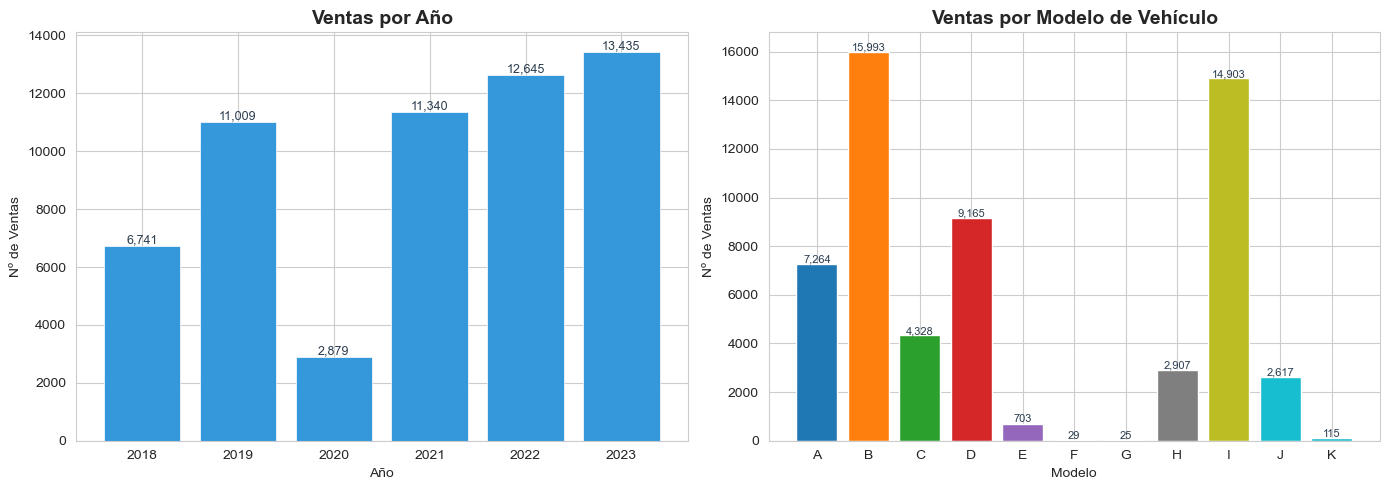

In [3]:
# Gráfico: Ventas por año y modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ventas por año
ventas_año = df['Sales_Date'].dt.year.value_counts().sort_index()
axes[0].bar(ventas_año.index, ventas_año.values, color='#3498db', edgecolor='white', linewidth=0.5)
axes[0].set_title('Ventas por Año', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Nº de Ventas')
for i, (año, v) in enumerate(ventas_año.items()):
    axes[0].text(año, v + 100, f'{v:,}', ha='center', fontsize=9, color='#2c3e50')

# Ventas por modelo
ventas_modelo = df['Modelo'].value_counts().sort_index()
colores_modelos = plt.cm.tab10(range(len(ventas_modelo)))
axes[1].bar(ventas_modelo.index, ventas_modelo.values, color=colores_modelos, edgecolor='white')
axes[1].set_title('Ventas por Modelo de Vehículo', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('Nº de Ventas')
for modelo, v in ventas_modelo.items():
    axes[1].text(modelo, v + 50, f'{v:,}', ha='center', fontsize=8, color='#2c3e50')

plt.tight_layout()
plt.show()

## 3. Analisis de Churn (Variable Objetivo)

El **Churn** es la variable que queremos predecir.
- **Y (1)** = El cliente lleva mas de 400 dias sin revision → se ha ido
- **N (0)** = El cliente sigue activo → se ha quedado

In [4]:
# Distribución de Churn
churn_counts = df['Churn_400'].value_counts()
churn_pct    = df['Churn_400'].value_counts(normalize=True) * 100

print("Distribución de Churn:")
print(f"  No Churn (N): {churn_counts.get('N',0):,} clientes ({churn_pct.get('N',0):.1f}%)")
print(f"  Churn    (Y): {churn_counts.get('Y',0):,} clientes ({churn_pct.get('Y',0):.1f}%)")
print()
print("⚠️  Nota: El dataset está DESBALANCEADO.")
print(f"    Por cada cliente que se va, hay {churn_pct.get('N',0)/churn_pct.get('Y',1):.0f} que se quedan.")
print("    Esto es IMPORTANTE para el modelo de ML (lo trataremos más adelante).")

Distribución de Churn:
  No Churn (N): 52,956 clientes (91.2%)
  Churn    (Y): 5,093 clientes (8.8%)

⚠️  Nota: El dataset está DESBALANCEADO.
    Por cada cliente que se va, hay 10 que se quedan.
    Esto es IMPORTANTE para el modelo de ML (lo trataremos más adelante).


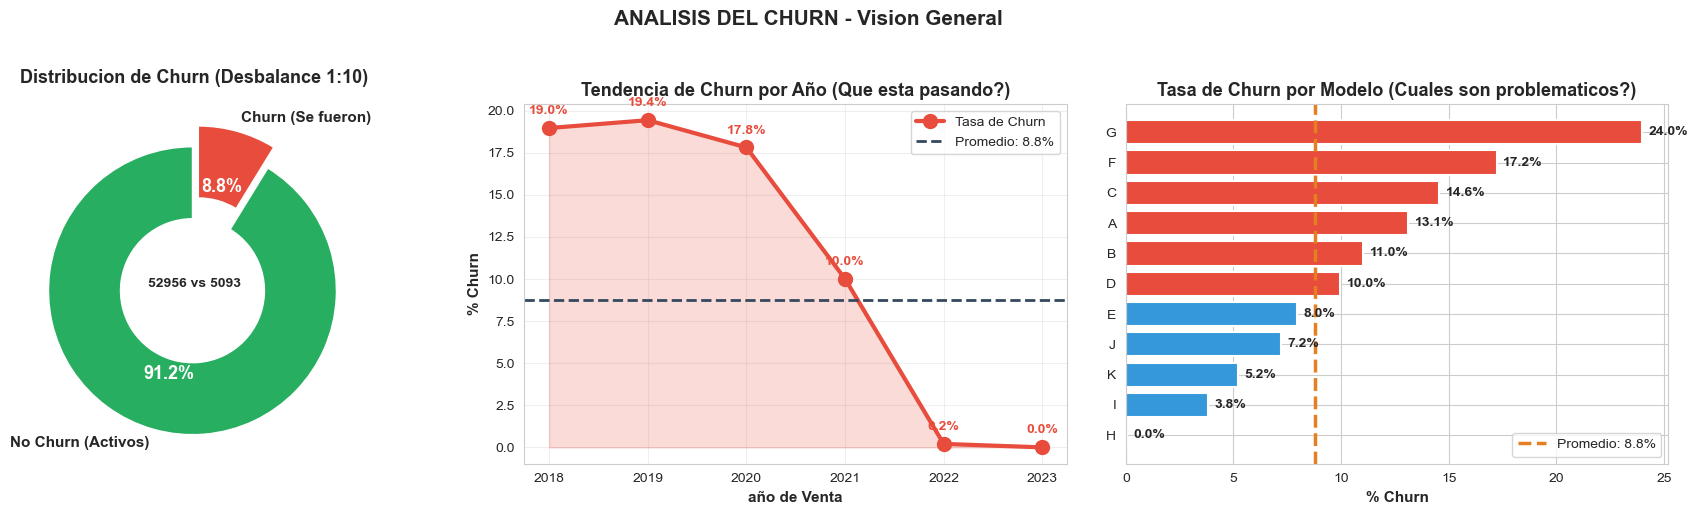


INSIGHT CLAVE:
  El churn AUMENTA año a año: de 19.0% (2018) a 0.0% (2023)
  Modelos con MAYOR riesgo: F, G


In [5]:
# Graficos - Distribucion de Churn (MEJORADO)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Datos
churn_counts = df['Churn_400'].value_counts()
churn_pct = df['Churn_400'].value_counts(normalize=True) * 100
n_churn = churn_counts.get('Y', 0)
n_nochurn = churn_counts.get('N', 0)

# GRAFICO 1: Donut chart mejorado
sizes = [n_nochurn, n_churn]
labels = ['No Churn (Activos)', 'Churn (Se fueron)']
colors_donut = ['#27ae60', '#e74c3c']
wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, colors=colors_donut,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.5),
    textprops={'fontsize': 11, 'weight': 'bold'},
    explode=(0.05, 0.1)
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(13)
    autotext.set_weight('bold')
axes[0].set_title('Distribucion de Churn (Desbalance 1:10)',
                   fontsize=13, fontweight='bold', pad=15)

# Anadir valores absolutos en el centro
axes[0].text(0, 0, str(n_nochurn) + ' vs ' + str(n_churn),
             ha='center', va='center', fontsize=10, weight='bold')

# GRAFICO 2: Tendencia temporal
churn_año = df.groupby(df['Sales_Date'].dt.year)['Churn_bin'].agg(['sum', 'count'])
churn_año['pct'] = churn_año['sum'] / churn_año['count'] * 100

axes[1].plot(churn_año.index, churn_año['pct'], marker='o',
             color='#e74c3c', linewidth=3, markersize=10, label='Tasa de Churn')
axes[1].fill_between(churn_año.index, churn_año['pct'], alpha=0.2, color='#e74c3c')
axes[1].axhline(y=df['Churn_bin'].mean()*100, color='#34495e',
                linestyle='--', linewidth=2, label='Promedio: ' + str(round(df['Churn_bin'].mean()*100, 1)) + '%')
axes[1].set_title('Tendencia de Churn por Año (Que esta pasando?)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('año de Venta', fontsize=11, fontweight='bold')
axes[1].set_ylabel('% Churn', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)
for año, pct in churn_año['pct'].items():
    axes[1].annotate(str(round(pct, 1)) + '%', (año, pct),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', fontsize=10, fontweight='bold', color='#e74c3c')

# GRAFICO 3: Churn por Modelo (TOP 5)
churn_modelo = df.groupby('Modelo')['Churn_bin'].agg(['sum', 'count'])
churn_modelo['pct'] = churn_modelo['sum'] / churn_modelo['count'] * 100
churn_modelo = churn_modelo.sort_values('pct', ascending=True)

colores_modelo = ['#e74c3c' if pct > df['Churn_bin'].mean()*100 else '#3498db'
                  for pct in churn_modelo['pct']]
axes[2].barh(churn_modelo.index, churn_modelo['pct'], color=colores_modelo, edgecolor='white', linewidth=1.5)
axes[2].axvline(df['Churn_bin'].mean()*100, color='#e67e22', linestyle='--',
                linewidth=2.5, label='Promedio: ' + str(round(df['Churn_bin'].mean()*100, 1)) + '%')
axes[2].set_title('Tasa de Churn por Modelo (Cuales son problematicos?)',
                   fontsize=13, fontweight='bold')
axes[2].set_xlabel('% Churn', fontsize=11, fontweight='bold')
axes[2].legend(fontsize=10)
for modelo, pct in churn_modelo['pct'].items():
    axes[2].text(pct + 0.3, modelo, str(round(pct, 1)) + '%',
                 va='center', fontsize=10, fontweight='bold')

plt.suptitle('ANALISIS DEL CHURN - Vision General', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("")
print("INSIGHT CLAVE:")
print("  El churn AUMENTA año a año: de " + str(round(churn_año['pct'].iloc[0], 1)) + "% (2018) a " + str(round(churn_año['pct'].iloc[-1], 1)) + "% (2023)")
print("  Modelos con MAYOR riesgo: " + ", ".join(churn_modelo.tail(2).index.tolist()))


## 4. Perfil del Cliente: Churner vs No-Churner

¿Quien se va y quien se queda? Comparamos las caracteristicas de ambos grupos.

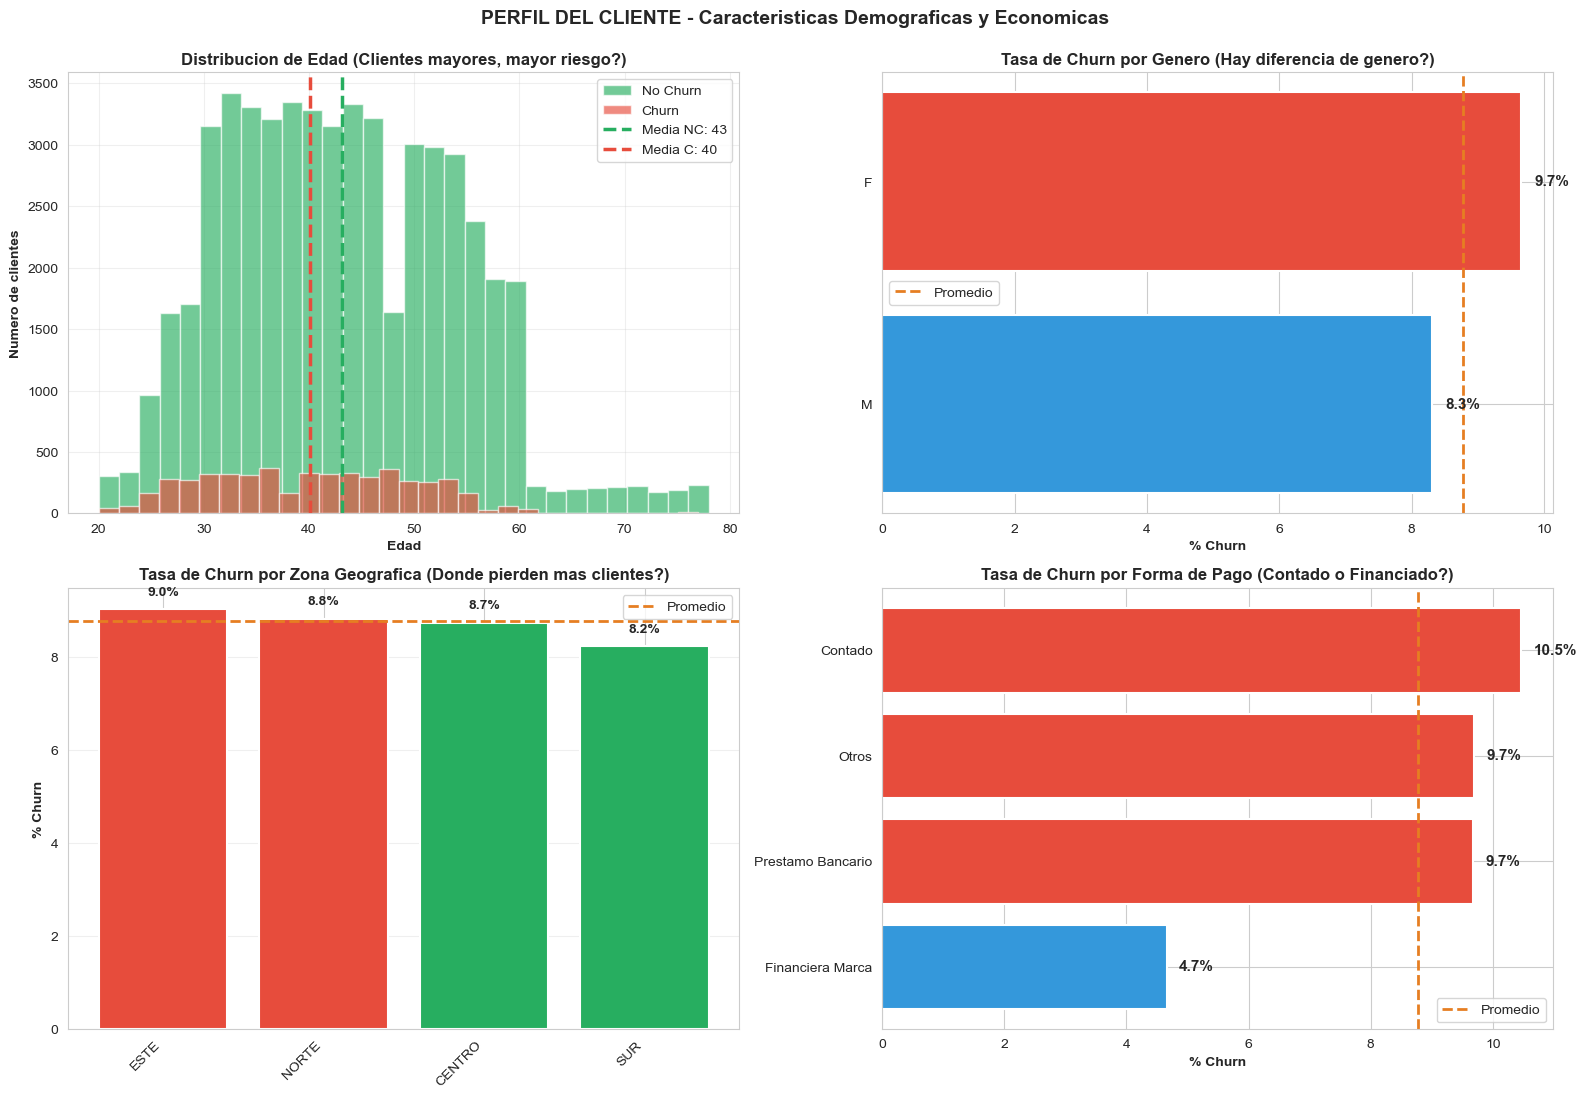


INSIGHTS DEMOGRAFICOS:
  Edad: Clientes de 40 años (vs 43 sin churn)
  Zona con MAYOR riesgo: ESTE (9.0%)
  Forma pago riesgosa: Contado (10.5%)


In [23]:
# Perfil del Cliente - MEJORADO (4 graficos clave)
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

df_churn = df[df['Churn_bin'] == 1]
df_nochurn = df[df['Churn_bin'] == 0]

# GRAFICO 1: EDAD (distribucion + estadisticas)
axes[0,0].hist(df_nochurn['Edad'], bins=30, alpha=0.65, color='#27ae60', label='No Churn', density=False)
axes[0,0].hist(df_churn['Edad'], bins=30, alpha=0.65, color='#e74c3c', label='Churn', density=False)
axes[0,0].axvline(df_nochurn['Edad'].mean(), color='#27ae60', linestyle='--', linewidth=2.5, label='Media NC: ' + str(round(df_nochurn['Edad'].mean())))
axes[0,0].axvline(df_churn['Edad'].mean(), color='#e74c3c', linestyle='--', linewidth=2.5, label='Media C: ' + str(round(df_churn['Edad'].mean())))
axes[0,0].set_title('Distribucion de Edad (Clientes mayores, mayor riesgo?)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Edad', fontweight='bold')
axes[0,0].set_ylabel('Numero de clientes', fontweight='bold')
axes[0,0].legend(fontsize=10)
axes[0,0].grid(True, alpha=0.3)

# GRAFICO 2: GENERO (barra con porcentajes)
genero_data = df.groupby('GENERO')['Churn_bin'].agg(['sum', 'count'])
genero_data['pct'] = genero_data['sum'] / genero_data['count'] * 100
genero_data = genero_data[genero_data['count'] > 50].sort_values('pct', ascending=True)

colors_gen = ['#e74c3c' if pct > df['Churn_bin'].mean()*100 else '#3498db' for pct in genero_data['pct']]
axes[0,1].barh(genero_data.index, genero_data['pct'], color=colors_gen, edgecolor='white', linewidth=1.5)
axes[0,1].axvline(df['Churn_bin'].mean()*100, color='#e67e22', linestyle='--', linewidth=2, label='Promedio')
axes[0,1].set_title('Tasa de Churn por Genero (Hay diferencia de genero?)', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('% Churn', fontweight='bold')
axes[0,1].legend(fontsize=10)
for gen, pct in genero_data['pct'].items():
    axes[0,1].text(pct + 0.2, gen, str(round(pct, 1)) + '%', va='center', fontsize=11, fontweight='bold')

# GRAFICO 3: ZONA GEOGRAFICA (mapa mental)
churn_zona = df.groupby('ZONA')['Churn_bin'].agg(['sum', 'count'])
churn_zona['pct'] = churn_zona['sum'] / churn_zona['count'] * 100
churn_zona = churn_zona.sort_values('pct', ascending=False)

colors_zona = ['#e74c3c' if pct > df['Churn_bin'].mean()*100 else '#27ae60' for pct in churn_zona['pct']]
axes[1,0].bar(range(len(churn_zona)), churn_zona['pct'], color=colors_zona, edgecolor='white', linewidth=1.5)
axes[1,0].axhline(df['Churn_bin'].mean()*100, color='#e67e22', linestyle='--', linewidth=2, label='Promedio')
axes[1,0].set_xticks(range(len(churn_zona)))
axes[1,0].set_xticklabels(churn_zona.index, rotation=45, ha='right')
axes[1,0].set_title('Tasa de Churn por Zona Geografica (Donde pierden mas clientes?)', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('% Churn', fontweight='bold')
axes[1,0].legend(fontsize=10)
axes[1,0].grid(True, alpha=0.3, axis='y')
for i, (zona, pct) in enumerate(churn_zona['pct'].items()):
    axes[1,0].text(i, pct + 0.3, str(round(pct, 1)) + '%', ha='center', fontsize=10, fontweight='bold')

# GRAFICO 4: FORMA DE PAGO (impacto economico)
churn_pago = df.groupby('FORMA_PAGO')['Churn_bin'].agg(['sum', 'count'])
churn_pago['pct'] = churn_pago['sum'] / churn_pago['count'] * 100
churn_pago = churn_pago.sort_values('pct', ascending=True)

colors_pago = ['#e74c3c' if pct > df['Churn_bin'].mean()*100 else '#3498db' for pct in churn_pago['pct']]
axes[1,1].barh(churn_pago.index, churn_pago['pct'], color=colors_pago, edgecolor='white', linewidth=1.5)
axes[1,1].axvline(df['Churn_bin'].mean()*100, color='#e67e22', linestyle='--', linewidth=2, label='Promedio')
axes[1,1].set_title('Tasa de Churn por Forma de Pago (Contado o Financiado?)', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('% Churn', fontweight='bold')
axes[1,1].legend(fontsize=10)
for pago, pct in churn_pago['pct'].items():
    axes[1,1].text(pct + 0.2, pago, str(round(pct, 1)) + '%', va='center', fontsize=11, fontweight='bold')

plt.suptitle('PERFIL DEL CLIENTE - Caracteristicas Demograficas y Economicas',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("")
print("INSIGHTS DEMOGRAFICOS:")
print("  Edad: Clientes de " + str(round(df_churn['Edad'].mean())) + " años (vs " + str(round(df_nochurn['Edad'].mean())) + " sin churn)")
print("  Zona con MAYOR riesgo: " + churn_zona.index[0] + " (" + str(round(churn_zona['pct'].iloc[0], 1)) + "%)")
print("  Forma pago riesgosa: " + churn_pago.index[-1] + " (" + str(round(churn_pago['pct'].iloc[-1], 1)) + "%)")


## 5. Analisis de Revisiones y Taller

Esta seccion es **clave** porque la variable churn se basa directamente en el historial de revisiones.

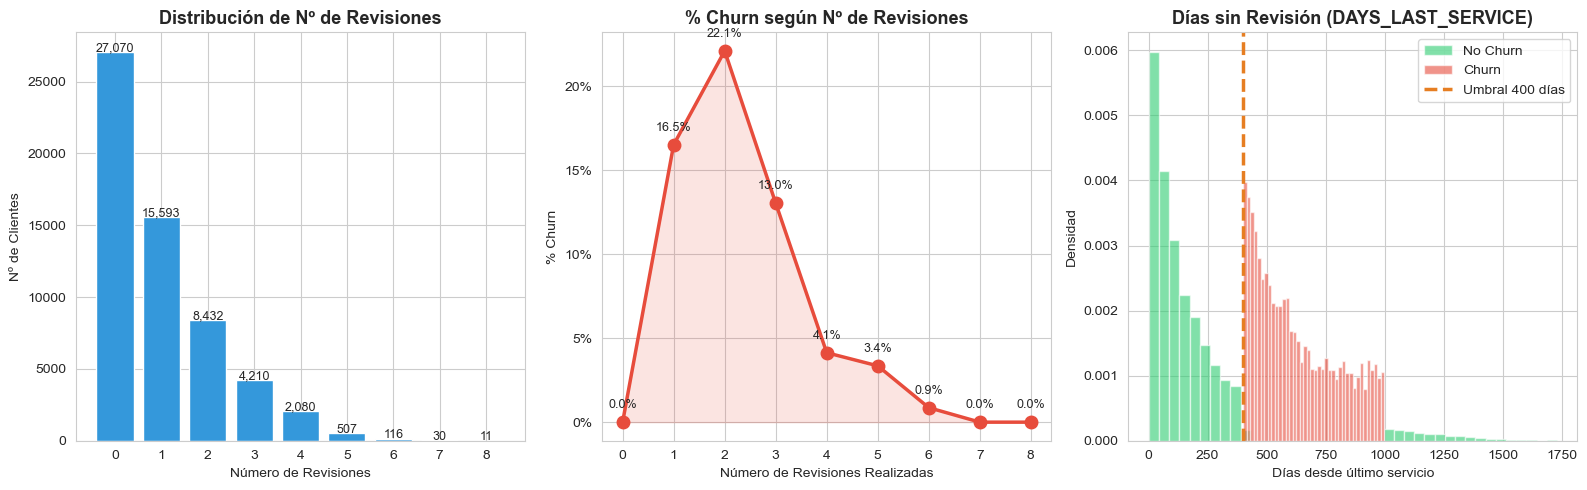


📊 Insight clave:
   → 27,070 clientes NUNCA han ido al taller (46.6%)
   → De los que sí fueron, la media de días sin visita es: 255 días
   → 6,431 superan los 400 días de umbral


In [7]:
# Análisis de revisiones
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Distribución de número de revisiones
rev_counts = df['Revisiones'].value_counts().sort_index()
axes[0].bar(rev_counts.index, rev_counts.values, color='#3498db', edgecolor='white')
axes[0].set_title('Distribución de Nº de Revisiones', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Número de Revisiones')
axes[0].set_ylabel('Nº de Clientes')
axes[0].set_xticks(rev_counts.index)
for n, v in rev_counts.items():
    axes[0].text(n, v + 50, f'{v:,}', ha='center', fontsize=9)

# 2. % Churn según número de revisiones
churn_rev = df.groupby('Revisiones')['Churn_bin'].mean() * 100
axes[1].plot(churn_rev.index, churn_rev.values, marker='o', color='#e74c3c',
             linewidth=2.5, markersize=9)
axes[1].fill_between(churn_rev.index, churn_rev.values, alpha=0.15, color='#e74c3c')
axes[1].set_title('% Churn según Nº de Revisiones', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Número de Revisiones Realizadas')
axes[1].set_ylabel('% Churn')
axes[1].set_xticks(churn_rev.index)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
for n, v in churn_rev.items():
    axes[1].annotate(f'{v:.1f}%', (n, v), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9)

# 3. Distribución de DAYS_LAST_SERVICE (solo los que tienen revisión)
df_con_rev = df[df['DAYS_LAST_SERVICE'] > 0].copy()
churn_si   = df_con_rev[df_con_rev['Churn_bin'] == 1]['DAYS_LAST_SERVICE']
churn_no   = df_con_rev[df_con_rev['Churn_bin'] == 0]['DAYS_LAST_SERVICE']
axes[2].hist(churn_no, bins=40, alpha=0.6, color='#2ecc71', label='No Churn', density=True)
axes[2].hist(churn_si, bins=40, alpha=0.6, color='#e74c3c', label='Churn',    density=True)
axes[2].axvline(x=400, color='#e67e22', linestyle='--', linewidth=2.5, label='Umbral 400 días')
axes[2].set_title('Días sin Revisión (DAYS_LAST_SERVICE)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Días desde último servicio')
axes[2].set_ylabel('Densidad')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\n📊 Insight clave:")
print(f"   → {(df['Revisiones']==0).sum():,} clientes NUNCA han ido al taller ({(df['Revisiones']==0).mean()*100:.1f}%)")
print(f"   → De los que sí fueron, la media de días sin visita es: {df_con_rev['DAYS_LAST_SERVICE'].mean():.0f} días")
print(f"   → {(df_con_rev['DAYS_LAST_SERVICE'] > 400).sum():,} superan los 400 días de umbral")

## 6. Analisis Economico (Margenes y Costes)

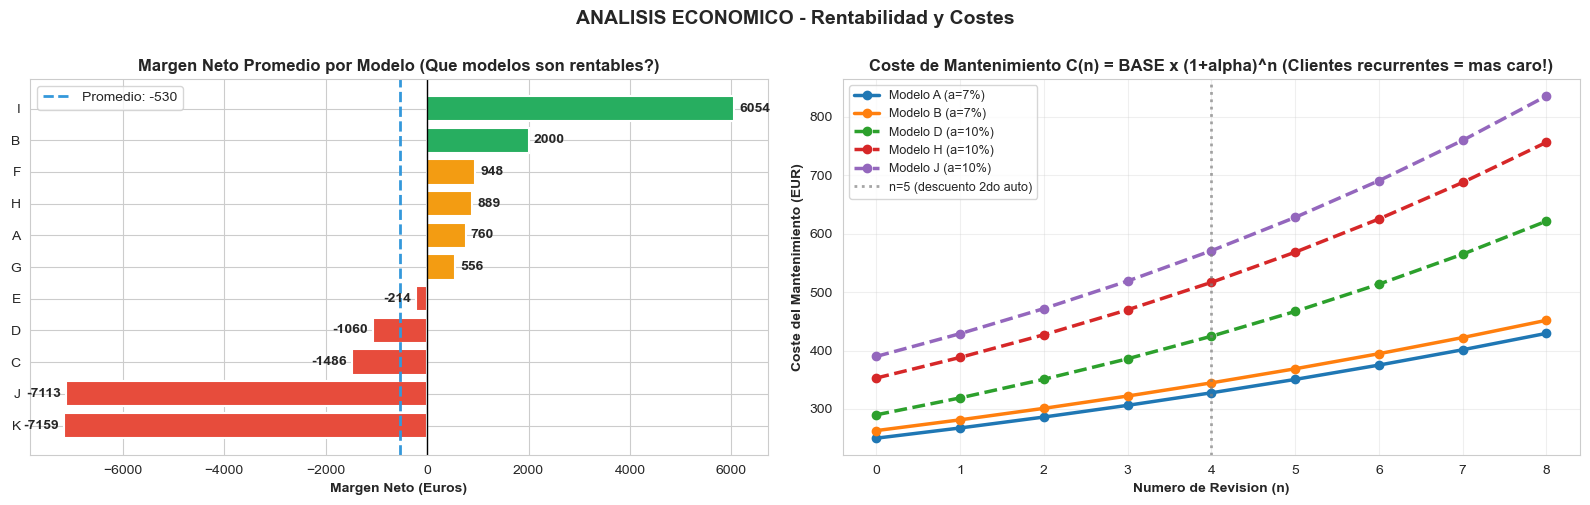


INSIGHTS ECONOMICOS:
  Modelo MAS rentable: I (6054 EUR)
  Modelo CON PERDIDAS: K (-7159 EUR)
  Los costes crecen exponencialmente con revisiones (efecto (1+alpha)^n)
  Modelos A,B (alpha=7%) crecen MAS LENTAMENTE que resto (alpha=10%)


In [8]:
# Analisis economico - MEJORADO (2 graficos esenciales)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# GRAFICO 1: MARGEN NETO POR MODELO (lo que VALEN)
margen_modelo = df.groupby('Modelo')['Margen_eur'].mean().sort_values(ascending=True)
colores_margen = ['#e74c3c' if v < 0 else '#27ae60' if v > 1000 else '#f39c12' for v in margen_modelo.values]
bars = axes[0].barh(margen_modelo.index, margen_modelo.values, color=colores_margen, edgecolor='white', linewidth=1.5)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].axvline(margen_modelo.mean(), color='#3498db', linestyle='--', linewidth=2, label='Promedio: ' + str(round(margen_modelo.mean())))
axes[0].set_title('Margen Neto Promedio por Modelo (Que modelos son rentables?)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Margen Neto (Euros)', fontweight='bold')
axes[0].legend(fontsize=10)
for modelo, valor in margen_modelo.items():
    x_pos = valor + (100 if valor > 0 else -100)
    ha = 'left' if valor > 0 else 'right'
    axes[0].text(x_pos, modelo, str(round(valor)), va='center', ha=ha, fontsize=10, fontweight='bold')

# GRAFICO 2: FUNCION DE COSTE C(n) (economia de escala)
n_vals = range(0, 9)
modelos_a_mostrar = ['A', 'B', 'D', 'H', 'J']
colores_linea = plt.cm.tab10(range(len(modelos_a_mostrar)))

for idx, modelo_sel in enumerate(modelos_a_mostrar):
    row = dim_costes[dim_costes['Modelo'] == modelo_sel].iloc[0]
    costes_n = [row['Mantenimiento_medio'] * (1 + row['Alpha'])**n for n in n_vals]
    linestyle = '-' if row['Modelo'] in ['A','B'] else '--'
    axes[1].plot(list(n_vals), costes_n, marker='o', markersize=6,
                 linestyle=linestyle, linewidth=2.5, label='Modelo ' + modelo_sel + ' (a=' + str(round(row['Alpha']*100)) + '%)',
                 color=colores_linea[idx])

axes[1].axvline(x=4, color='gray', linestyle=':', linewidth=2, alpha=0.7, label='n=5 (descuento 2do auto)')
axes[1].set_title('Coste de Mantenimiento C(n) = BASE x (1+alpha)^n (Clientes recurrentes = mas caro!)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Numero de Revision (n)', fontweight='bold')
axes[1].set_ylabel('Coste del Mantenimiento (EUR)', fontweight='bold')
axes[1].legend(fontsize=9, loc='upper left')
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.suptitle('ANALISIS ECONOMICO - Rentabilidad y Costes', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("")
print("INSIGHTS ECONOMICOS:")
modelo_mejor = margen_modelo[margen_modelo > 0].idxmax()
modelo_peor = margen_modelo[margen_modelo < 0].idxmin() if (margen_modelo < 0).any() else "Ninguno"
print("  Modelo MAS rentable: " + modelo_mejor + " (" + str(round(margen_modelo[modelo_mejor])) + " EUR)")
if modelo_peor != "Ninguno":
    print("  Modelo CON PERDIDAS: " + modelo_peor + " (" + str(round(margen_modelo[modelo_peor])) + " EUR)")
print("  Los costes crecen exponencialmente con revisiones (efecto (1+alpha)^n)")
print("  Modelos A,B (alpha=7%) crecen MAS LENTAMENTE que resto (alpha=10%)")


## 7. Correlaciones entre Variables

Vemos que variables estan mas relacionadas con el **Churn** y entre si.
Esto nos ayuda a decidir que variables incluir en el modelo.

ANALISIS DE CORRELACIONES - Que variables predicen CHURN?


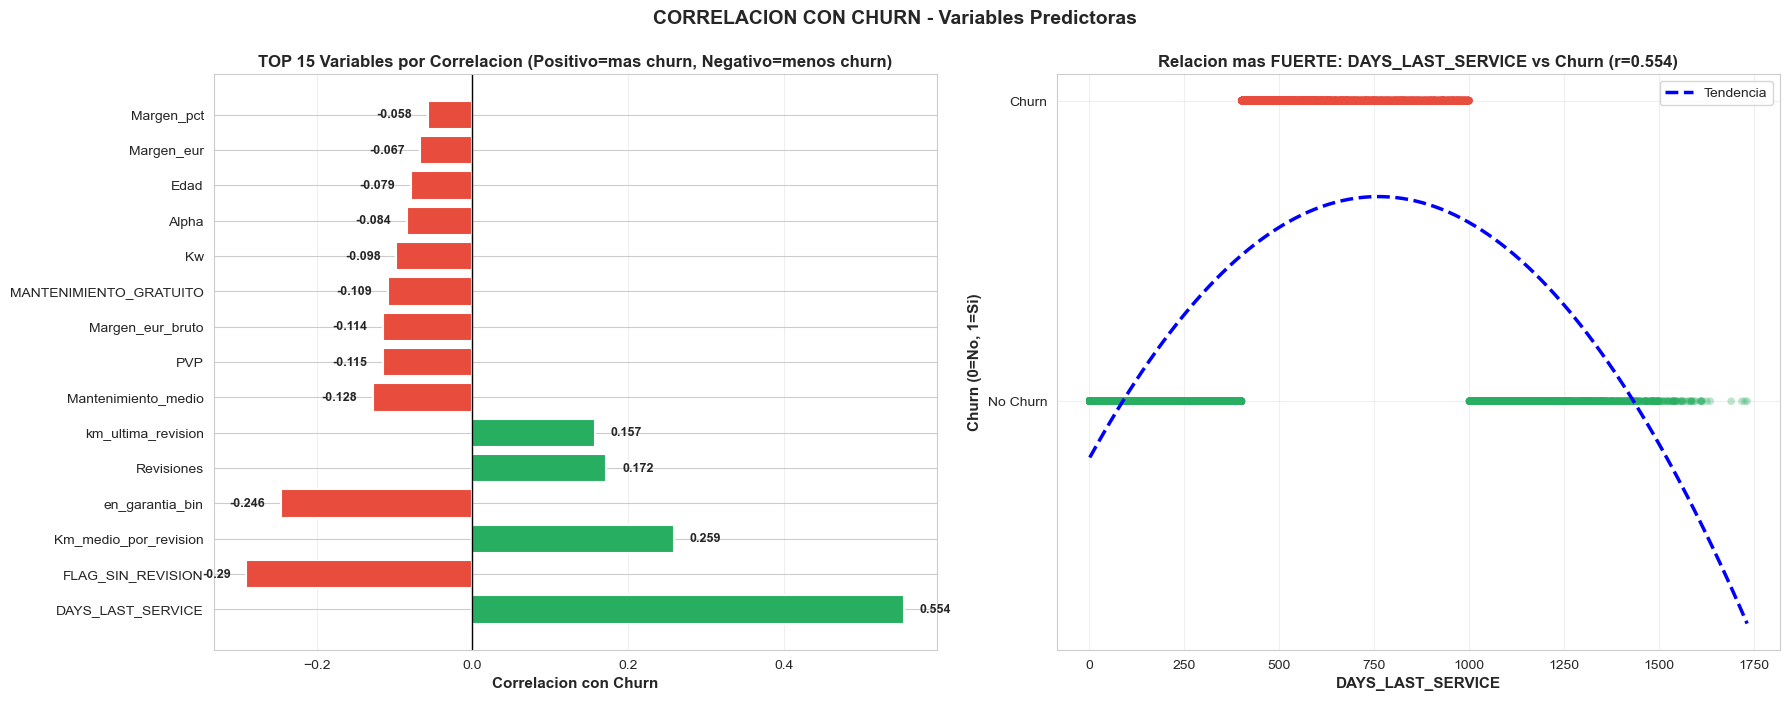


VARIABLES MAS IMPORTANTES (r > 0.3):
  * DAYS_LAST_SERVICE r=0.554 (AUMENTA churn)

VARIABLES MODERADAS (0.1 < r < 0.3):
  * FLAG_SIN_REVISION r=-0.29
  * Km_medio_por_revision r=0.259
  * en_garantia_bin r=-0.246
  * Revisiones r=0.172
  * km_ultima_revision r=0.157
  * Mantenimiento_medio r=-0.128
  * PVP r=-0.115
  * Margen_eur_bruto r=-0.114
  * MANTENIMIENTO_GRATUITO r=-0.109

INSIGHT FINAL:
  La variable MAS predictora es: DAYS_LAST_SERVICE (r=0.554)
  Total variables utiles (r > 0.1): 10
  Total variables poco relevantes (r < 0.1): 14


In [9]:
# Correlaciones - ANALISIS PROFESIONAL
import numpy as np

print("="*70)
print("ANALISIS DE CORRELACIONES - Que variables predicen CHURN?")
print("="*70)

# Obtener todas las variables numericas
vars_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

# Tratar DAYS_LAST_SERVICE: -1 es NaN
if 'DAYS_LAST_SERVICE' in vars_numericas:
    df['DAYS_LAST_SERVICE'] = df['DAYS_LAST_SERVICE'].replace(-1, np.nan)

# Matriz de correlacion
df_corr = df[vars_numericas].copy()
corr_matrix = df_corr.corr()

# Extraer correlaciones con Churn
corr_churn = corr_matrix['Churn_bin'].drop('Churn_bin').sort_values(key=abs, ascending=False)

# GRAFICO 1: Barras horizontales (TOP 15)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top_n = 15
corr_top = corr_churn.head(top_n)

colors_corr = ['#e74c3c' if x < 0 else '#27ae60' for x in corr_top.values]
y_pos = range(len(corr_top))

bars = axes[0].barh(y_pos, corr_top.values, color=colors_corr, edgecolor='white', linewidth=1.5)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(corr_top.index, fontsize=10)
axes[0].set_xlabel('Correlacion con Churn', fontweight='bold', fontsize=11)
axes[0].set_title('TOP 15 Variables por Correlacion (Positivo=mas churn, Negativo=menos churn)',
                   fontsize=12, fontweight='bold')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].grid(True, alpha=0.3, axis='x')

# Anadir valores
for i, (var, val) in enumerate(corr_top.items()):
    x_pos = val + (0.02 if val > 0 else -0.02)
    ha = 'left' if val > 0 else 'right'
    axes[0].text(x_pos, i, str(round(val, 3)), va='center', ha=ha, fontsize=9, fontweight='bold')

# GRAFICO 2: Scatter - variable mas fuerte vs Churn
var_fuerte = corr_churn.idxmax()
df_plot = df[[var_fuerte, 'Churn_bin']].dropna()

scatter_colors = ['#27ae60' if x == 0 else '#e74c3c' for x in df_plot['Churn_bin']]
axes[1].scatter(df_plot[var_fuerte], df_plot['Churn_bin'],
                alpha=0.3, s=30, c=scatter_colors, edgecolors='none')

# Anadir una linea de tendencia
z = np.polyfit(df_plot[var_fuerte], df_plot['Churn_bin'], 2)
p = np.poly1d(z)
x_line = np.linspace(df_plot[var_fuerte].min(), df_plot[var_fuerte].max(), 100)
axes[1].plot(x_line, p(x_line), "b--", linewidth=2.5, label='Tendencia')

axes[1].set_xlabel(var_fuerte, fontweight='bold', fontsize=11)
axes[1].set_ylabel('Churn (0=No, 1=Si)', fontweight='bold', fontsize=11)
axes[1].set_title('Relacion mas FUERTE: ' + var_fuerte + ' vs Churn (r=' + str(round(corr_churn[var_fuerte], 3)) + ')',
                  fontsize=12, fontweight='bold')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['No Churn', 'Churn'])
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.suptitle('CORRELACION CON CHURN - Variables Predictoras', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ANALISIS TEXTUAL
print("")
print("VARIABLES MAS IMPORTANTES (r > 0.3):")
muy_importante = corr_churn[abs(corr_churn) > 0.3]
for var, val in muy_importante.items():
    dir_text = "AUMENTA churn" if val > 0 else "DISMINUYE churn"
    print("  * " + var + " r=" + str(round(val, 3)) + " (" + dir_text + ")")

print("")
print("VARIABLES MODERADAS (0.1 < r < 0.3):")
moderadas = corr_churn[(abs(corr_churn) > 0.1) & (abs(corr_churn) <= 0.3)]
for var, val in moderadas.items():
    print("  * " + var + " r=" + str(round(val, 3)))

print("")
print("INSIGHT FINAL:")
print("  La variable MAS predictora es: " + corr_churn.idxmax() + " (r=" + str(round(corr_churn.max(), 3)) + ")")
print("  Total variables utiles (r > 0.1): " + str(len(corr_churn[abs(corr_churn) > 0.1])))
print("  Total variables poco relevantes (r < 0.1): " + str(len(corr_churn[abs(corr_churn) <= 0.1])))


In [22]:
# =================================================================
# FEATURE ENGINEERING - VARIABLES PARA EDA Y MODELADO
# =================================================================
print("="*70)
print("FEATURE ENGINEERING")
print("="*70)

from datetime import datetime

df['Sales_Date'] = pd.to_datetime(df['Sales_Date'], format='%d/%m/%Y', errors='coerce')
fecha_corte = pd.to_datetime('31/12/2023', format='%d/%m/%Y')

# -----------------------------------------------------------------
# VARIABLE 1: ANTIGUEDAD (solo para EDA y creacion del target,
#              NO se usara como feature en los modelos)
# -----------------------------------------------------------------
df['antiguedad_dias'] = (fecha_corte - df['Sales_Date']).dt.days.clip(lower=0)

print("\n>> antiguedad_dias (SOLO EDA, NO entra en modelos)")
print(f"   Min: {df['antiguedad_dias'].min()} dias | Max: {df['antiguedad_dias'].max()} dias")
print(f"   Media: {df['antiguedad_dias'].mean():.0f} dias ({df['antiguedad_dias'].mean()/365:.1f} años)")

# -----------------------------------------------------------------
# VARIABLE 2: GASTO RELATIVO (PVP / RENTA)
# -----------------------------------------------------------------
df['gasto_relativo'] = df['PVP'] / df['RENTA_MEDIA_ESTIMADA'].clip(lower=1)

print(f"\n>> gasto_relativo (PVP / Renta Media)")
print(f"   Min: {df['gasto_relativo'].min():.2f} | Max: {df['gasto_relativo'].max():.2f}")
print(f"   Media: {df['gasto_relativo'].mean():.2f}")

print("\n" + "="*70)
print("FEATURE ENGINEERING COMPLETADO")
print("="*70)
print(f"\nVariables creadas:")
print(f"   1. antiguedad_dias  - Antiguedad del cliente (SOLO EDA + target)")
print(f"   2. gasto_relativo   - Ratio PVP/Renta (feature de modelado)")
print(f"\nVariables binarias ya existentes (creadas en carga de datos):")
print(f"   - tiene_queja, en_garantia_bin")
print(f"\nSiguiente paso: Construir DataMart final para modelado")

FEATURE ENGINEERING

>> antiguedad_dias (SOLO EDA, NO entra en modelos)
   Min: 1 dias | Max: 2190 dias
   Media: 945 dias (2.6 años)

>> gasto_relativo (PVP / Renta Media)
   Min: 0.28 | Max: 37970.00
   Media: 5399.27

FEATURE ENGINEERING COMPLETADO

Variables creadas:
   1. antiguedad_dias  - Antiguedad del cliente (SOLO EDA + target)
   2. gasto_relativo   - Ratio PVP/Renta (feature de modelado)

Variables binarias ya existentes (creadas en carga de datos):
   - tiene_queja, en_garantia_bin

Siguiente paso: Construir DataMart final para modelado


## 8. Conclusiones Previas al Modelo

In [11]:
print("=" * 60)
print("CONCLUSIONES DEL ANALISIS EXPLORATORIO")
print("=" * 60)

tasa_churn  = df['Churn_bin'].mean() * 100
n_churn     = df['Churn_bin'].sum()
n_nochurn   = (df['Churn_bin'] == 0).sum()
ratio       = n_nochurn / n_churn

print("=" * 60)
print("DATASET:")
print(f"  - {len(df):,} registros historicos (2018-2023)")
print(f"  - {df['Customer_ID'].nunique():,} clientes unicos")
print()
print("CHURN:")
print(f"  - Tasa de churn: {tasa_churn:.1f}%")
print(f"  - Clientes churners: {n_churn:,}")
print(f"  - Clientes activos:  {n_nochurn:,}")
print(f"  - Ratio desbalance:  1 churner por cada {ratio:.0f} activos")
print("  -> Necesitaremos balanceo (SMOTE o class_weight)")
print()
print("DATA LEAKAGE DETECTADO:")
print("  DAYS_LAST_SERVICE NO se usara en el modelo")
print("  FLAG_SIN_REVISION NO se usara en el modelo")
print("  -> Ambas son la propia definicion de churn (circular)")
print()
print("VARIABLES MAS RELEVANTES PARA EL MODELO:")
print("  1. Revisiones         (numero de revisiones)")
print("  2. km_ultima_revision (km acumulados)")
print("  3. Antiguedad del cliente")
print("  4. Modelo del vehiculo")
print("  5. Zona geografica")
print("  6. tiene_queja        (si tuvo queja)")
print("  7. en_garantia        (si esta en garantia)")
print("  8. gasto_relativo     (PVP/Renta)")
print()
print("INSIGHTS:")
print("  - Clientes con 0 revisiones tienen mayor riesgo")
print("  - Modelos J y K muestran mayor tasa de churn")
print("  - El churn es mayor en ventas antiguas (2018-2019)")
print()
print("SIGUIENTE PASO: Entrenar modelo ML con el Data Mart corregido")


CONCLUSIONES DEL ANALISIS EXPLORATORIO
DATASET:
  - 58,049 registros historicos (2018-2023)
  - 44,053 clientes unicos

CHURN:
  - Tasa de churn: 8.8%
  - Clientes churners: 5,093
  - Clientes activos:  52,956
  - Ratio desbalance:  1 churner por cada 10 activos
  -> Necesitaremos balanceo (SMOTE o class_weight)

DATA LEAKAGE DETECTADO:
  DAYS_LAST_SERVICE NO se usara en el modelo
  FLAG_SIN_REVISION NO se usara en el modelo
  -> Ambas son la propia definicion de churn (circular)

VARIABLES MAS RELEVANTES PARA EL MODELO:
  1. Revisiones         (numero de revisiones)
  2. km_ultima_revision (km acumulados)
  3. Antiguedad del cliente
  4. Modelo del vehiculo
  5. Zona geografica
  6. tiene_queja        (si tuvo queja)
  7. en_garantia        (si esta en garantia)
  8. gasto_relativo     (PVP/Renta)

INSIGHTS:
  - Clientes con 0 revisiones tienen mayor riesgo
  - Modelos J y K muestran mayor tasa de churn
  - El churn es mayor en ventas antiguas (2018-2019)

SIGUIENTE PASO: Entrenar mod

In [12]:
# =================================================================
# CONSTRUCCION DEL DATA MART FINAL (v2)
# =================================================================
# El DataMart contiene SOLO features limpias para modelar.
# Las variables de leakage (Revisiones, antiguedad_dias,
# DAYS_LAST_SERVICE) NO se guardan en el CSV.
# =================================================================
print("="*70)
print("CONSTRUCCION DEL DATA MART FINAL (v2)")
print("="*70)

from sklearn.preprocessing import LabelEncoder
import os

# ---------------------------------------------------------------
# PASO 1: Seleccionar features
# ---------------------------------------------------------------
print("")
print("PASO 1: Seleccionar features")
print("-"*55)

# NUMERICAS (9)
features_numericas = [
    'km_ultima_revision', 'PVP', 'Edad', 'RENTA_MEDIA_ESTIMADA',
    'gasto_relativo', 'Kw', 'Margen_eur_bruto', 'Margen_eur',
    'ENCUESTA_CLIENTE_ZONA_TALLER'
]

# BINARIAS (3 ya existentes)
features_binarias = [
    'tiene_queja', 'en_garantia_bin', 'MANTENIMIENTO_GRATUITO'
]

# LEAD (nuevas)
features_lead = ['Lead_compra']  # ya es 0/1

# CATEGORICAS (todas con Label Encoding, una sola columna cada una)
features_categoricas = [
    'Modelo', 'ZONA', 'FORMA_PAGO', 'TIPO_CARROCERIA',
    'Equipamiento', 'Fuel', 'TRANSMISION_ID'
]

# TARGET
target = 'Churn_bin'

# AUXILIARES: solo para crear derivadas, NO se guardan en el CSV
auxiliares = ['Revisiones', 'SEGURO_BATERIA_LARGO_PLAZO', 'Origen']

todas = (features_numericas + features_binarias + features_lead +
         features_categoricas + [target] + auxiliares)

print(f"Numericas:    {len(features_numericas)}")
print(f"Binarias:     {len(features_binarias)}")
print(f"Lead:         {len(features_lead)}")
print(f"Categoricas:  {len(features_categoricas)}")
print(f"Target:       1 (Churn_bin)")
print(f"Auxiliares:   {len(auxiliares)} (solo para derivadas, se eliminan)")

# ---------------------------------------------------------------
# PASO 2: Crear DataMart base
# ---------------------------------------------------------------
print("")
print("PASO 2: Crear DataMart base")
print("-"*55)

datamart = df[todas].copy()
print(f"Filas:    {len(datamart):,}")
print(f"Columnas: {len(datamart.columns)}")

# ---------------------------------------------------------------
# PASO 3: Crear variables derivadas
# ---------------------------------------------------------------
print("")
print("PASO 3: Crear variables derivadas")
print("-"*55)

# perfil_cliente (0=recurrente, 1=ghost) - usa Revisiones y luego se elimina
datamart['perfil_cliente'] = (datamart['Revisiones'] == 0).astype(int)
print(f"   perfil_cliente:       Ghost={datamart['perfil_cliente'].sum():,}, "
      f"Recurrente={(datamart['perfil_cliente']==0).sum():,}")

# seguro_bateria_bin
datamart['seguro_bateria_bin'] = (
    datamart['SEGURO_BATERIA_LARGO_PLAZO']
    .fillna('NO').str.upper().str.strip() == 'SI'
).astype(int)
print(f"   seguro_bateria_bin:   {datamart['seguro_bateria_bin'].sum():,} con seguro")

# sin_encuesta: flag binaria para nulos en ENCUESTA + rellenar con 0
n_null_enc = datamart['ENCUESTA_CLIENTE_ZONA_TALLER'].isnull().sum()
datamart['sin_encuesta'] = datamart['ENCUESTA_CLIENTE_ZONA_TALLER'].isnull().astype(int)
datamart['ENCUESTA_CLIENTE_ZONA_TALLER'] = datamart['ENCUESTA_CLIENTE_ZONA_TALLER'].fillna(0)
print(f"   sin_encuesta:         {n_null_enc:,} nulos -> flag=1, valor=0")

# origen_internet: Internet=1, Tienda=0
datamart['origen_internet'] = (
    datamart['Origen'].fillna('Tienda').str.strip() == 'Internet'
).astype(int)
print(f"   origen_internet:      {datamart['origen_internet'].sum():,} de Internet "
      f"({datamart['origen_internet'].mean()*100:.1f}%)")

# ELIMINAR auxiliares (ya se usaron, NO entran en el CSV)
datamart = datamart.drop(columns=['Revisiones', 'SEGURO_BATERIA_LARGO_PLAZO', 'Origen'])
print("")
print("   Auxiliares ELIMINADAS del datamart:")
print("   x Revisiones (solo se uso para crear perfil_cliente)")
print("   x SEGURO_BATERIA_LARGO_PLAZO (solo para seguro_bateria_bin)")
print("   x Origen (solo para origen_internet)")

# ---------------------------------------------------------------
# PASO 4: Tratamiento de nulos
# ---------------------------------------------------------------
print("")
print("PASO 4: Tratamiento de nulos")
print("-"*55)

for col in features_numericas:
    if col == 'ENCUESTA_CLIENTE_ZONA_TALLER':
        continue
    n_null = datamart[col].isnull().sum()
    if n_null > 0:
        med = datamart[col].median()
        datamart[col] = datamart[col].fillna(med)
        print(f"   {col}: {n_null} nulos -> mediana ({med:.2f})")

for col in features_categoricas:
    n_null = datamart[col].isnull().sum()
    if n_null > 0:
        moda = datamart[col].mode()[0]
        datamart[col] = datamart[col].fillna(moda)
        print(f"   {col}: {n_null} nulos -> moda ({moda})")

n_total = datamart.isnull().sum().sum()
print(f"   Nulos restantes: {n_total}")

# ---------------------------------------------------------------
# PASO 5: Label Encoding (todas las categoricas)
# ---------------------------------------------------------------
print("")
print("PASO 5: Label Encoding")
print("-"*55)

label_encoders = {}
for col in features_categoricas:
    le = LabelEncoder()
    datamart[col] = le.fit_transform(datamart[col].astype(str))
    label_encoders[col] = le
    print(f"   {col:20s}: {len(le.classes_)} categorias -> 0 a {len(le.classes_)-1}")

# ---------------------------------------------------------------
# PASO 6: Guardar
# ---------------------------------------------------------------
print("")
print("PASO 6: Guardar DataMart")
print("-"*55)

os.makedirs('./Data/Datamart', exist_ok=True)
datamart.to_csv('./Data/Datamart/datamart_final_v2.csv', index=False)

feature_cols = [c for c in datamart.columns if c != 'Churn_bin']

print(f"Guardado en: ./Data/Datamart/datamart_final_v2.csv")
print("")
print("="*70)
print("RESUMEN DEL DATA MART FINAL (v2)")
print("="*70)
print("")
print(f"Filas:     {len(datamart):,}")
print(f"Columnas:  {len(datamart.columns)} ({len(feature_cols)} features + 1 target)")
print("")

all_bin = (features_binarias + features_lead +
           ['perfil_cliente', 'seguro_bateria_bin', 'sin_encuesta', 'origen_internet'])
print(f"Numericas ({len(features_numericas)}):    {', '.join(features_numericas)}")
print(f"Binarias ({len(all_bin)}):     {', '.join(all_bin)}")
print(f"Label Enc ({len(features_categoricas)}):   {', '.join(features_categoricas)}")
print(f"Target:              Churn_bin")
print("")
print("VARIABLES QUE NO ESTAN EN EL DATAMART (anti-leakage):")
print("   x Revisiones")
print("   x antiguedad_dias")
print("   x DAYS_LAST_SERVICE")
print("   x Km_medio_por_revision")
print("   x FLAG_SIN_REVISION")
print("")
print("Primeras 5 filas:")
datamart.head()

CONSTRUCCION DEL DATA MART FINAL (v2)

PASO 1: Seleccionar features
-------------------------------------------------------
Numericas:    9
Binarias:     3
Lead:         1
Categoricas:  7
Target:       1 (Churn_bin)
Auxiliares:   3 (solo para derivadas, se eliminan)

PASO 2: Crear DataMart base
-------------------------------------------------------
Filas:    58,049
Columnas: 24

PASO 3: Crear variables derivadas
-------------------------------------------------------
   perfil_cliente:       Ghost=27,070, Recurrente=30,979
   seguro_bateria_bin:   6,946 con seguro
   sin_encuesta:         0 nulos -> flag=1, valor=0
   origen_internet:      31,875 de Internet (54.9%)

   Auxiliares ELIMINADAS del datamart:
   x Revisiones (solo se uso para crear perfil_cliente)
   x SEGURO_BATERIA_LARGO_PLAZO (solo para seguro_bateria_bin)
   x Origen (solo para origen_internet)

PASO 4: Tratamiento de nulos
-------------------------------------------------------
   Nulos restantes: 0

PASO 5: Label En

,km_ultima_revision,PVP,Edad,RENTA_MEDIA_ESTIMADA,gasto_relativo,Kw,Margen_eur_bruto,Margen_eur,ENCUESTA_CLIENTE_ZONA_TALLER,tiene_queja,...,FORMA_PAGO,TIPO_CARROCERIA,Equipamiento,Fuel,TRANSMISION_ID,Churn_bin,perfil_cliente,seguro_bateria_bin,sin_encuesta,origen_internet
0,27241,10528,36,27023,0.389594,53,2328.79,1247.08,65,0,...,1,0,1,1,1,0,0,0,0,0
1,0,10528,46,28655,0.367405,53,2328.79,1247.08,88,0,...,0,0,1,1,1,0,1,0,0,1
2,0,10528,60,25089,0.419626,53,2328.79,1247.08,155,1,...,0,0,1,1,1,0,1,0,0,0
3,0,10528,55,32095,0.328026,53,2328.79,1247.08,13,0,...,0,0,1,1,1,0,1,0,0,1
4,78060,10528,31,29689,0.354609,53,2328.79,1247.08,124,0,...,0,0,1,1,1,1,0,0,0,1


---

## Correccion de la Variable Objetivo: Redefinicion de Churn

### Problema detectado

La variable `Churn_bin` original clasifica como **"activo"** a clientes que compraron el vehiculo
hace mas de 400 dias pero **nunca acudieron al taller oficial**. Desde un punto de vista comercial,
estos clientes estan **igualmente perdidos** para el negocio de postventa.

| Perfil del cliente | Churn original | Churn corregido | Justificacion |
|---|---|---|---|
| 2 revisiones, ultima hace 500 dias | 1 (Churn) | 1 (Churn) | Dejo de acudir al taller |
| 0 revisiones, compro hace 800 dias | **0 (Activo)** | **1 (Churn)** | Nunca fue captado por postventa |
| 0 revisiones, compro hace 100 dias | 0 (Activo) | 0 (Activo) | Aun es pronto para ir al taller |
| 3 revisiones, ultima hace 200 dias | 0 (Activo) | 0 (Activo) | Cliente recurrente activo |

### Nueva definicion

```
Churn_Corregido = 1 (PERDIDO) si:
  - Cliente con revisiones que lleva >400 dias sin volver (churn clasico), O
  - Cliente con 0 revisiones y >400 dias de antiguedad (nunca captado)

Churn_Corregido = 0 (ACTIVO) si:
  - Cliente que acude regularmente al taller, O
  - Cliente nuevo (<400 dias) que aun no ha tenido oportunidad de ir
```

**Impacto:** La tasa de churn pasa de 8.8% a ~33%, reflejando mejor la realidad comercial.


In [13]:
# =================================================================
# CORRECCION DE LA VARIABLE OBJETIVO
# =================================================================
print("="*70)
print("CORRECCION DE LA VARIABLE OBJETIVO")
print("="*70)

# IMPORTANTE: Revisiones y antiguedad_dias NO están en el DataMart
# (fueron excluidas para evitar leakage). Las leemos del DataFrame original.

# Cargar DataMart
dm = pd.read_csv('./Data/Datamart/datamart_final_v2.csv')

# Obtener Revisiones y antiguedad_dias del df original (cargado en celda 2)
# Si df no está disponible, cargar directamente
if 'df' not in globals() or df is None or len(df) == 0:
    print("Cargando datos originales para obtener Revisiones y antiguedad_dias...")
    df_temp = pd.read_csv('./Data/DataLake/customer_data.csv')
    df_temp['Sales_Date'] = pd.to_datetime(df_temp['Sales_Date'], format='%d/%m/%Y', errors='coerce')
    fecha_corte = pd.to_datetime('31/12/2023', format='%d/%m/%Y')
    df_temp['antiguedad_dias'] = (fecha_corte - df_temp['Sales_Date']).dt.days.clip(lower=0)
    df_temp['Churn_bin'] = (df_temp['Churn_400'] == 'Y').astype(int)

    # Tomar solo las columnas necesarias
    df_aux = df_temp[['Revisiones', 'antiguedad_dias', 'Churn_bin']].copy()
else:
    # Usar df existente
    df_aux = df[['Revisiones', 'antiguedad_dias', 'Churn_bin']].copy()

# Diagnostico previo
n_rev0 = (df_aux['Revisiones'] == 0).sum()
n_rev0_antiguos = ((df_aux['Revisiones'] == 0) & (df_aux['antiguedad_dias'] > 400)).sum()

print('')
print('DIAGNOSTICO:')
print('   Total clientes:                        ' + str(len(dm)))
print('   Clientes con 0 revisiones:             ' + str(n_rev0) + ' (' + str(round(n_rev0/len(dm)*100, 1)) + '%)')
print('   Clientes con 0 rev + >400 dias:        ' + str(n_rev0_antiguos) + ' (' + str(round(n_rev0_antiguos/len(dm)*100, 1)) + '%)')
print('')

# Crear Churn_Corregido
dm['Churn_Corregido'] = (
    (df_aux['Churn_bin'] == 1) |
    ((df_aux['Revisiones'] == 0) & (df_aux['antiguedad_dias'] > 400))
).astype(int)

# Comparativa
print('COMPARATIVA CHURN_BIN vs CHURN_CORREGIDO:')
print('-'*55)
print('{:<30} {:>12} {:>12}'.format('', 'Churn_bin', 'Churn_Corregido'))
print('-'*55)
n_orig = (dm['Churn_bin'] == 1).sum()
n_corr = (dm['Churn_Corregido'] == 1).sum()
print('{:<30} {:>12} {:>12}'.format('Total Churn=1', str(n_orig), str(n_corr)))
print('{:<30} {:>11.1f}% {:>11.1f}%'.format('Tasa de Churn',
                                            n_orig/len(dm)*100,
                                            n_corr/len(dm)*100))
print('-'*55)
print('')
print('Incremento: +' + str(n_corr - n_orig) + ' churners (' + str(round((n_corr - n_orig)/len(dm)*100, 1)) + '%)')
print('')

# Guardar DataMart actualizado con Churn_Corregido
dm.to_csv('./Data/Datamart/datamart_final_v2.csv', index=False)
print('DataMart actualizado guardado.')
print('')
print('NOTA: Revisiones y antiguedad_dias NO están en el DataMart guardado.')
print('      Solo se usaron aquí para CREAR el target, no están en features.')

CORRECCION DE LA VARIABLE OBJETIVO

DIAGNOSTICO:
   Total clientes:                        58049
   Clientes con 0 revisiones:             27070 (46.6%)
   Clientes con 0 rev + >400 dias:        14236 (24.5%)

COMPARATIVA CHURN_BIN vs CHURN_CORREGIDO:
-------------------------------------------------------
                                  Churn_bin Churn_Corregido
-------------------------------------------------------
Total Churn=1                          5093        19329
Tasa de Churn                          8.8%        33.3%
-------------------------------------------------------

Incremento: +14236 churners (24.5%)

DataMart actualizado guardado.

NOTA: Revisiones y antiguedad_dias NO están en el DataMart guardado.
      Solo se usaron aquí para CREAR el target, no están en features.


---
---

# FASE 2: Modelado ML — 2 Enfoques

Presentamos 2 enfoques con complejidad creciente. El **Enfoque 1** utiliza feature engineering
para distinguir tipos de churn, mientras que el **Enfoque 2** elimina el data leakage logico
para reflejar la capacidad predictiva real.

En ambos se entrenan **3 modelos** (Random Forest, XGBoost, LightGBM) con sus respectivas
curvas AUC-ROC, matrices de confusion, curvas Precision-Recall, distribucion bimodal
y ranking de variables mas importantes.

| Enfoque | Idea principal | Modelos |
|---------|---------------|--------|
| 1. Feature Engineering | Crear `nunca_ha_venido` para distinguir churn de captacion vs retencion | RF, XGBoost, LightGBM |
| **2. Sin leakage** | **Eliminar `Revisiones` y `antiguedad_dias` de features** | **RF, XGBoost, LightGBM** |

## Enfoque 1: Feature Engineering (`nunca_ha_venido`)

**Idea:** Utilizar todos los 58,049 clientes del DataMart y crear una variable explicita `nunca_ha_venido`
que distinga los dos tipos de churn (captacion vs retencion), aprovechando el feature engineering.

### Variables utilizadas

El modelo se alimenta de **4 grupos de variables** que caracterizan al cliente y su vehiculo:

| Tipo | Variables | Encoding |
|------|-----------|----------|
| **Numericas (9)** | `km_ultima_revision`, `PVP`, `Edad`, `RENTA_MEDIA_ESTIMADA`, `gasto_relativo`, `Kw`, `Margen_eur_bruto`, `Margen_eur`, `ENCUESTA_CLIENTE_ZONA_TALLER` | Tal cual |
| **Binarias (8)** | `tiene_queja`, `en_garantia_bin`, `MANTENIMIENTO_GRATUITO`, `Lead_compra`, `perfil_cliente`, `seguro_bateria_bin`, `sin_encuesta`, `origen_internet` + **`nunca_ha_venido`** | 0/1 |
| **Categoricas (7)** | `Modelo`, `ZONA`, `Equipamiento`, `FORMA_PAGO`, `TIPO_CARROCERIA`, `Fuel`, `TRANSMISION_ID` | Label Encoding |

### Feature Engineering clave

- **`nunca_ha_venido`** = 1 si el cliente tiene 0 revisiones en taller, 0 en caso contrario
- **`origen_internet`** = 1 si la venta se origino por Internet
- **`sin_encuesta`** = flag para clientes sin puntuacion de encuesta

### Modelos entrenados

Se comparan **3 algoritmos**: Random Forest, XGBoost y LightGBM, cada uno con:
- Curva AUC-ROC y matriz de confusion
- Curva Precision-Recall
- Distribucion bimodal de probabilidades
- Top de variables mas importantes

ENFOQUE 1: FEATURE ENGINEERING (nunca_ha_venido)

PASO 1: Crear variable nunca_ha_venido
-------------------------------------------------------
   Nunca vinieron:  27070 (46.6%)
   Con historial:   30979 (53.4%)

PASO 2: Corregir target
-------------------------------------------------------
Churn_Final = 1:  19329 (33.3%)

PASO 3: Preparar features y target
-------------------------------------------------------
Features: 25 (incluye nunca_ha_venido)

                  Filas      Churn    % Churn
---------------------------------------------
Train             46439      15463      33.3%
Test              11610       3866      33.3%

1. RANDOM FOREST - ENFOQUE 1
AUC-ROC: 0.8509
              precision    recall  f1-score   support

    No Churn       0.79      0.90      0.84      7744
       Churn       0.72      0.52      0.60      3866

    accuracy                           0.77     11610
   macro avg       0.75      0.71      0.72     11610
weighted avg       0.77      0.77      0

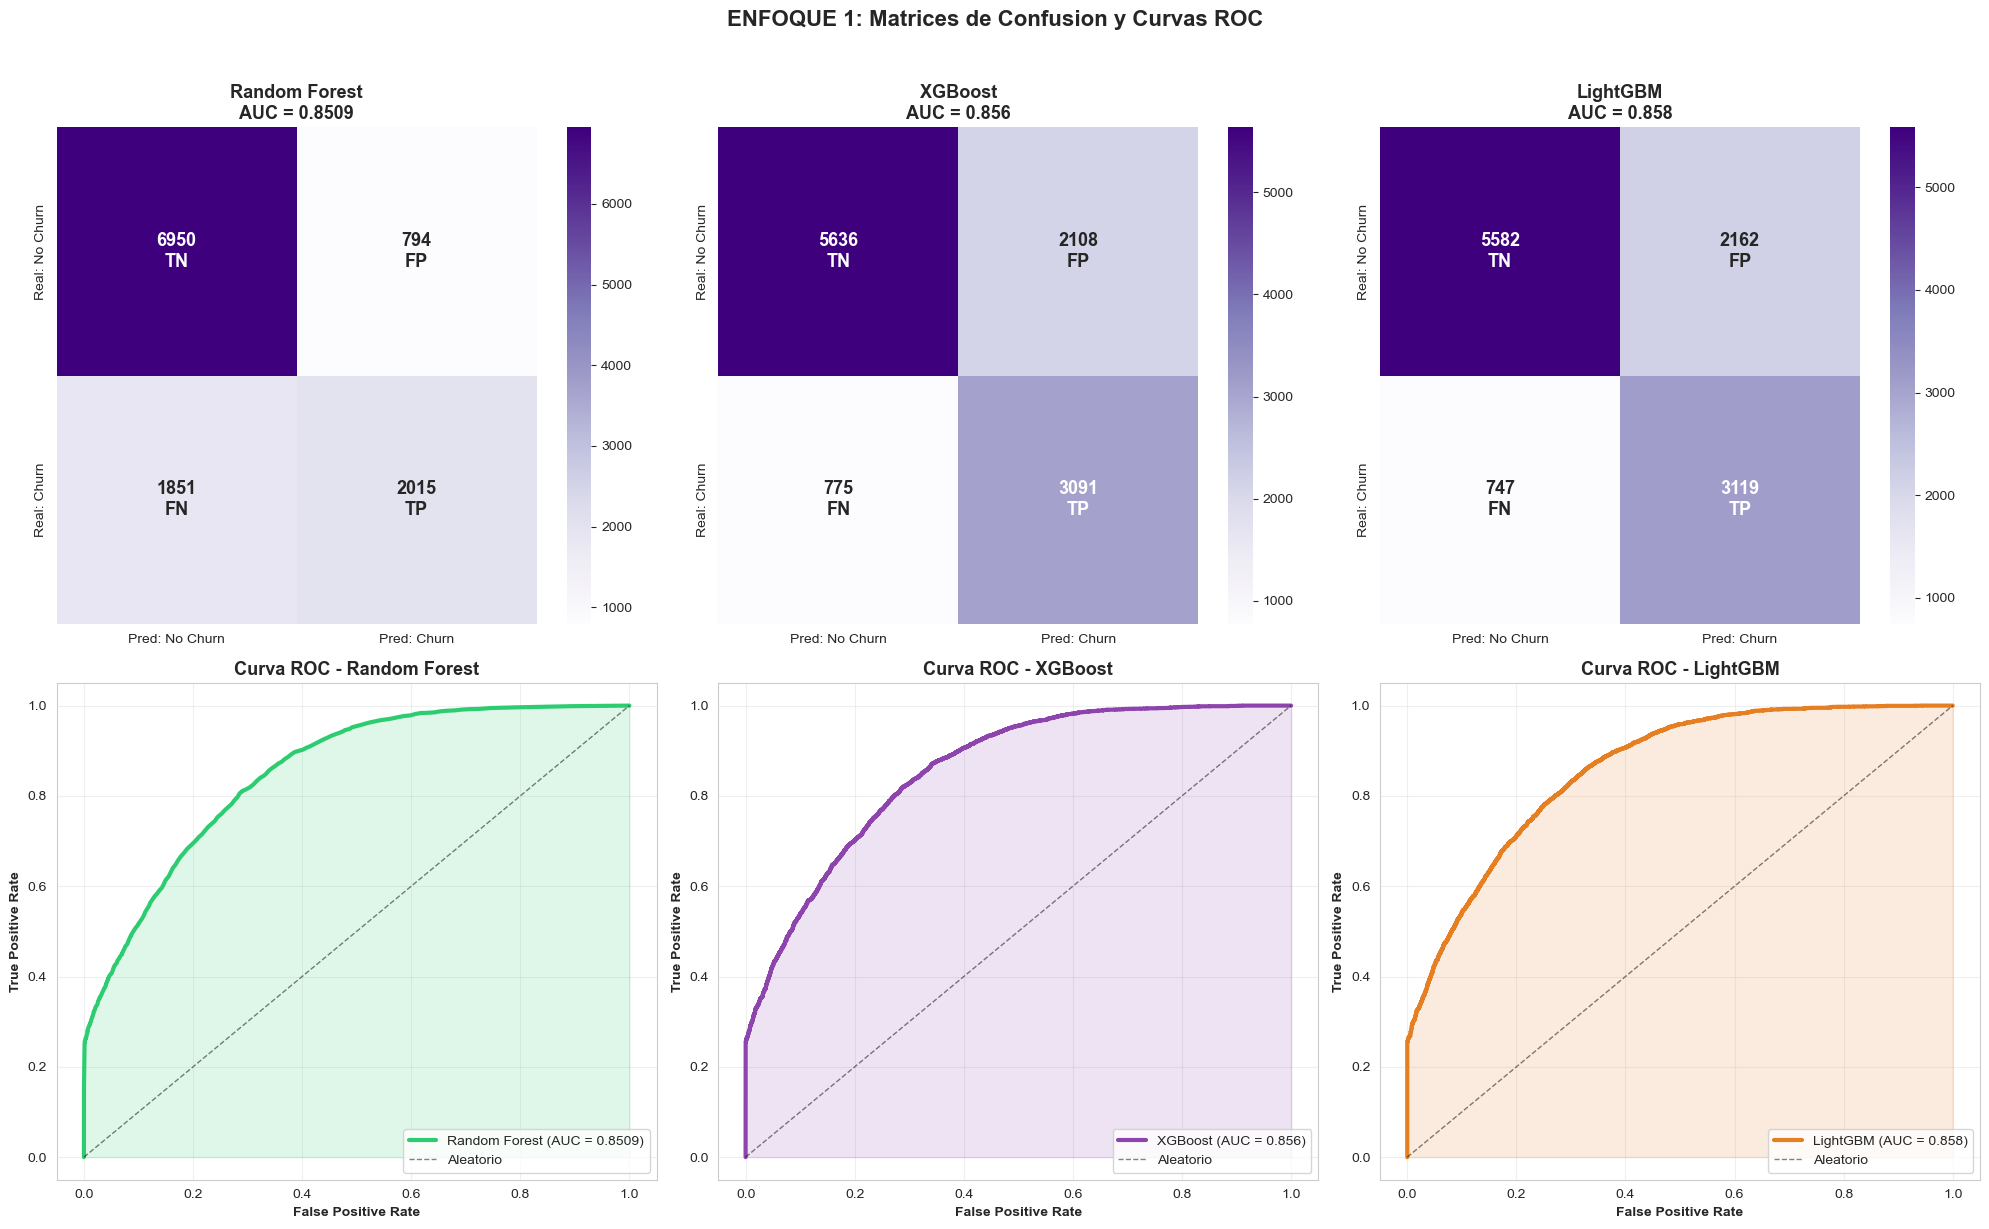

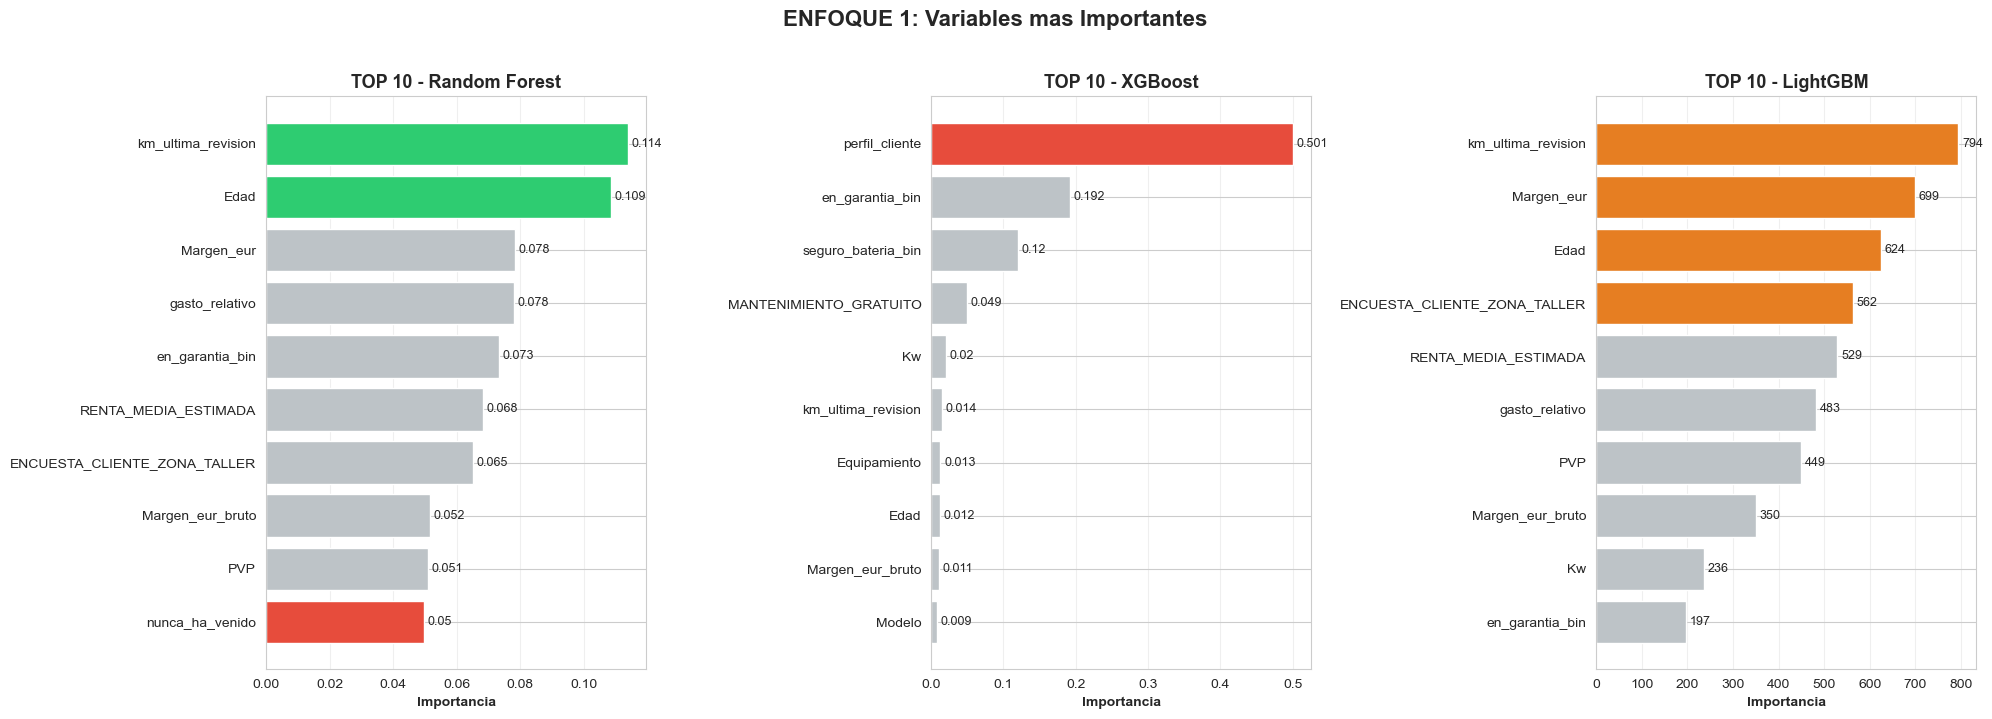

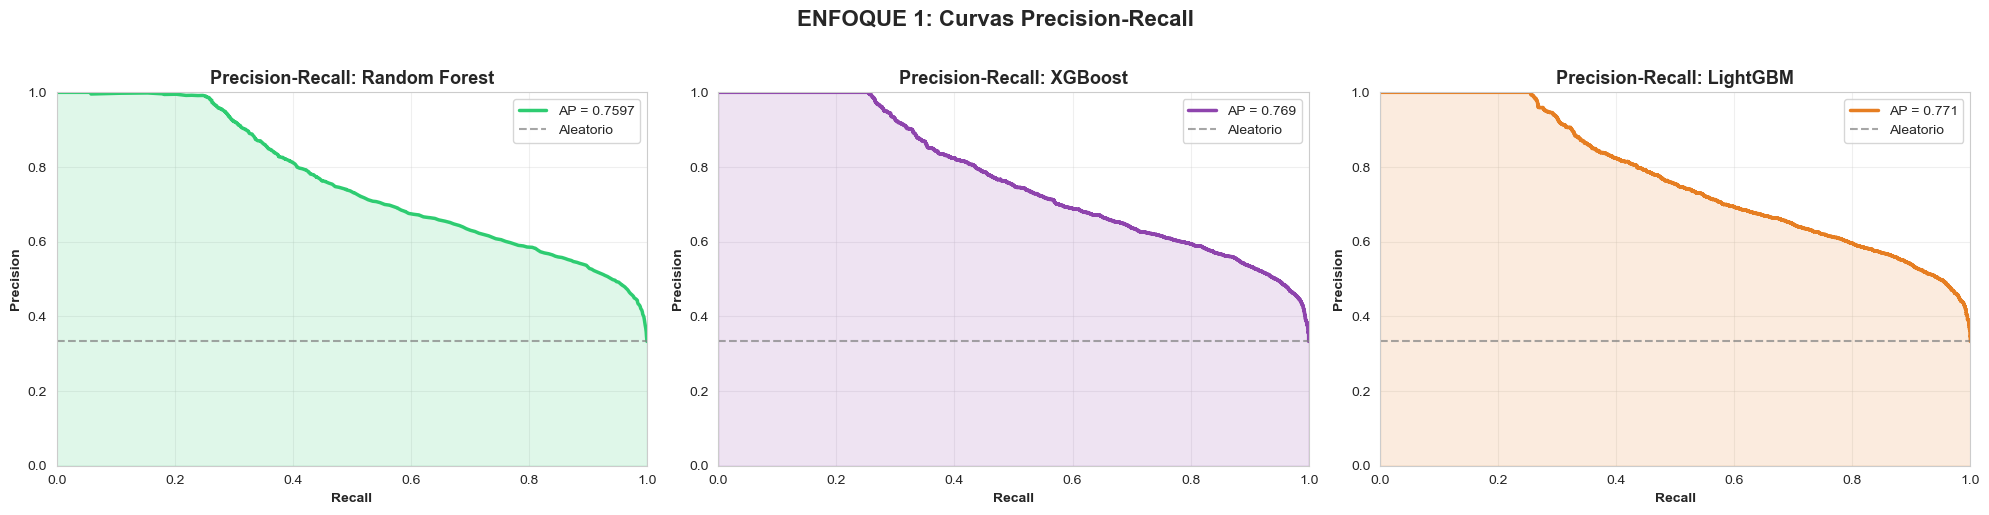

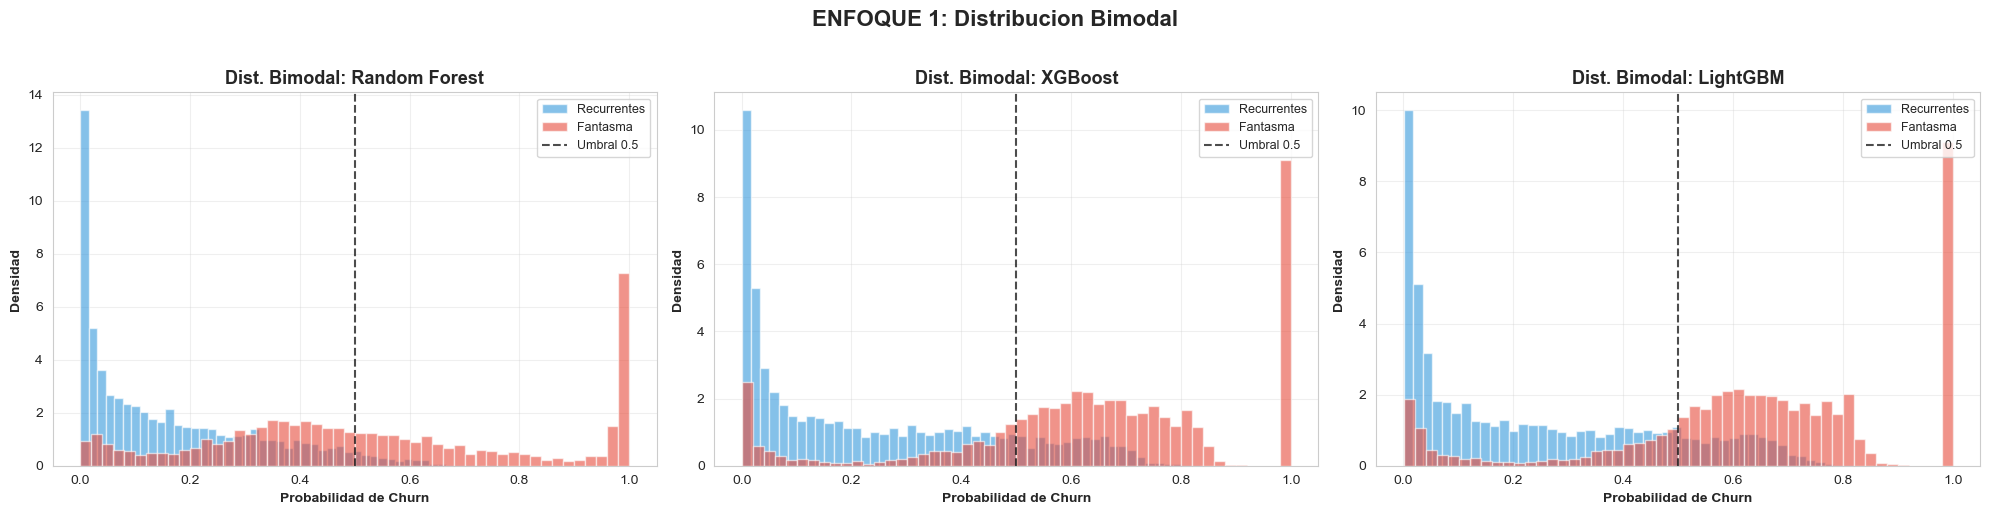

In [14]:
# =================================================================
# ENFOQUE 1: FEATURE ENGINEERING + CHURN CORREGIDO
# =================================================================
print('='*70)
print('ENFOQUE 1: FEATURE ENGINEERING (nunca_ha_venido)')
print('='*70)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import lightgbm as lgb

# Cargar DataMart v2 (SOLO features limpias + Churn_bin)
dm_v1 = pd.read_csv('./Data/Datamart/datamart_final_v2.csv')

# ---------------------------------------------------------------
# PASO 1: Crear nunca_ha_venido (desde df original, NO del datamart)
# ---------------------------------------------------------------
print('')
print('PASO 1: Crear variable nunca_ha_venido')
print('-'*55)

# Revisiones viene del df original (NO esta en el datamart)
dm_v1['nunca_ha_venido'] = (df['Revisiones'].values == 0).astype(int)

print('   Nunca vinieron:  ' + str((dm_v1['nunca_ha_venido']==1).sum()) +
      ' (' + str(round((dm_v1['nunca_ha_venido']==1).mean()*100,1)) + '%)')
print('   Con historial:   ' + str((dm_v1['nunca_ha_venido']==0).sum()) +
      ' (' + str(round((dm_v1['nunca_ha_venido']==0).mean()*100,1)) + '%)')

# ---------------------------------------------------------------
# PASO 2: Crear target corregido (usando df original)
# ---------------------------------------------------------------
print('')
print('PASO 2: Corregir target')
print('-'*55)

dm_v1['Churn_Final'] = (
    (df['Churn_bin'].values == 1) |
    ((df['Revisiones'].values == 0) & (df['antiguedad_dias'].values > 400))
).astype(int)

n_churn = (dm_v1['Churn_Final'] == 1).sum()
print('Churn_Final = 1:  ' + str(n_churn) +
      ' (' + str(round(n_churn/len(dm_v1)*100, 1)) + '%)')

# ---------------------------------------------------------------
# PASO 3: Separar X e y
# ---------------------------------------------------------------
print('')
print('PASO 3: Preparar features y target')
print('-'*55)

cols_drop = [c for c in ['Churn_bin', 'Churn_Final', 'Churn_Corregido'] if c in dm_v1.columns]
X_v1 = dm_v1.drop(columns=cols_drop)
y_v1 = dm_v1['Churn_Final']

print('Features: ' + str(X_v1.shape[1]) + ' (incluye nunca_ha_venido)')

X_train_v1, X_test_v1, y_train_v1, y_test_v1 = train_test_split(
    X_v1, y_v1, test_size=0.2, random_state=42, stratify=y_v1
)

print('')
print('{:<12} {:>10} {:>10} {:>10}'.format('', 'Filas', 'Churn', '% Churn'))
print('-'*45)
print('{:<12} {:>10} {:>10} {:>9}%'.format('Train', str(len(X_train_v1)),
      str((y_train_v1==1).sum()), str(round((y_train_v1==1).mean()*100,1))))
print('{:<12} {:>10} {:>10} {:>9}%'.format('Test', str(len(X_test_v1)),
      str((y_test_v1==1).sum()), str(round((y_test_v1==1).mean()*100,1))))

# =========================================================================
# ENTRENAR 3 MODELOS
# =========================================================================
ratio_v1 = (y_train_v1 == 0).sum() / (y_train_v1 == 1).sum()
modelos_v1 = {}

print('')
print('='*70)
print('1. RANDOM FOREST - ENFOQUE 1')
print('='*70)
rf_v1 = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                random_state=42, n_jobs=-1)
rf_v1.fit(X_train_v1, y_train_v1)
modelos_v1['Random Forest'] = {
    'model': rf_v1,
    'y_pred': rf_v1.predict(X_test_v1),
    'y_prob': rf_v1.predict_proba(X_test_v1)[:, 1],
    'importances': pd.Series(rf_v1.feature_importances_, index=X_train_v1.columns)
}
modelos_v1['Random Forest']['auc'] = roc_auc_score(y_test_v1, modelos_v1['Random Forest']['y_prob'])
print('AUC-ROC: ' + str(round(modelos_v1['Random Forest']['auc'], 4)))
print(classification_report(y_test_v1, modelos_v1['Random Forest']['y_pred'],
                            target_names=['No Churn', 'Churn']))

print('='*70)
print('2. XGBOOST - ENFOQUE 1')
print('='*70)
xgb_v1 = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                        scale_pos_weight=ratio_v1, random_state=42,
                        eval_metric='logloss', n_jobs=-1)
xgb_v1.fit(X_train_v1, y_train_v1)
modelos_v1['XGBoost'] = {
    'model': xgb_v1,
    'y_pred': xgb_v1.predict(X_test_v1),
    'y_prob': xgb_v1.predict_proba(X_test_v1)[:, 1],
    'importances': pd.Series(xgb_v1.feature_importances_, index=X_train_v1.columns)
}
modelos_v1['XGBoost']['auc'] = roc_auc_score(y_test_v1, modelos_v1['XGBoost']['y_prob'])
print('AUC-ROC: ' + str(round(modelos_v1['XGBoost']['auc'], 4)))
print(classification_report(y_test_v1, modelos_v1['XGBoost']['y_pred'],
                            target_names=['No Churn', 'Churn']))

print('='*70)
print('3. LIGHTGBM - ENFOQUE 1')
print('='*70)
lgb_v1 = lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                              scale_pos_weight=ratio_v1, random_state=42,
                              n_jobs=-1, verbose=-1)
lgb_v1.fit(X_train_v1, y_train_v1)
modelos_v1['LightGBM'] = {
    'model': lgb_v1,
    'y_pred': lgb_v1.predict(X_test_v1),
    'y_prob': lgb_v1.predict_proba(X_test_v1)[:, 1],
    'importances': pd.Series(lgb_v1.feature_importances_, index=X_train_v1.columns)
}
modelos_v1['LightGBM']['auc'] = roc_auc_score(y_test_v1, modelos_v1['LightGBM']['y_prob'])
print('AUC-ROC: ' + str(round(modelos_v1['LightGBM']['auc'], 4)))
print(classification_report(y_test_v1, modelos_v1['LightGBM']['y_pred'],
                            target_names=['No Churn', 'Churn']))

# =========================================================================
# COMPARATIVA
# =========================================================================
print('')
print('='*70)
print('COMPARATIVA: RF vs XGBoost vs LightGBM (Enfoque 1)')
print('='*70)
print('')
print('{:<22} {:>15} {:>15} {:>15}'.format('Metrica', 'Random Forest', 'XGBoost', 'LightGBM'))
print('='*70)
for nombre, datos in modelos_v1.items():
    cm = confusion_matrix(y_test_v1, datos['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    datos['precision'] = tp / (tp + fp) if (tp + fp) > 0 else 0
    datos['recall'] = tp / (tp + fn) if (tp + fn) > 0 else 0
    datos['f1'] = (2 * datos['precision'] * datos['recall'] /
                   (datos['precision'] + datos['recall'])
                   if (datos['precision'] + datos['recall']) > 0 else 0)

print('{:<22} {:>14.1f}% {:>14.1f}% {:>14.1f}%'.format('Precision (Churn)',
    modelos_v1['Random Forest']['precision']*100,
    modelos_v1['XGBoost']['precision']*100,
    modelos_v1['LightGBM']['precision']*100))
print('{:<22} {:>14.1f}% {:>14.1f}% {:>14.1f}%'.format('Recall (Churn)',
    modelos_v1['Random Forest']['recall']*100,
    modelos_v1['XGBoost']['recall']*100,
    modelos_v1['LightGBM']['recall']*100))
print('{:<22} {:>14.1f}% {:>14.1f}% {:>14.1f}%'.format('F1-Score (Churn)',
    modelos_v1['Random Forest']['f1']*100,
    modelos_v1['XGBoost']['f1']*100,
    modelos_v1['LightGBM']['f1']*100))
print('{:<22} {:>14.4f}  {:>14.4f}  {:>14.4f}'.format('AUC-ROC',
    modelos_v1['Random Forest']['auc'],
    modelos_v1['XGBoost']['auc'],
    modelos_v1['LightGBM']['auc']))
print('='*70)

# =========================================================================
# VISUALIZACIONES
# =========================================================================
colores = {'Random Forest': '#2ecc71', 'XGBoost': '#8e44ad', 'LightGBM': '#e67e22'}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for idx, (nombre, datos) in enumerate(modelos_v1.items()):
    color = colores[nombre]
    cm = confusion_matrix(y_test_v1, datos['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    labels = np.array([[str(tn) + '\nTN', str(fp) + '\nFP'],
                       [str(fn) + '\nFN', str(tp) + '\nTP']])
    sns.heatmap(cm, annot=labels, fmt='', cmap='Purples', ax=axes[0, idx],
                xticklabels=['Pred: No Churn', 'Pred: Churn'],
                yticklabels=['Real: No Churn', 'Real: Churn'],
                annot_kws={'size': 13, 'weight': 'bold'})
    axes[0, idx].set_title(nombre + '\nAUC = ' + str(round(datos['auc'], 4)),
                           fontsize=13, fontweight='bold')
    fpr, tpr, _ = roc_curve(y_test_v1, datos['y_prob'])
    axes[1, idx].plot(fpr, tpr, color=color, linewidth=3,
                      label=nombre + ' (AUC = ' + str(round(datos['auc'], 4)) + ')')
    axes[1, idx].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Aleatorio')
    axes[1, idx].fill_between(fpr, tpr, alpha=0.15, color=color)
    axes[1, idx].set_xlabel('False Positive Rate', fontweight='bold')
    axes[1, idx].set_ylabel('True Positive Rate', fontweight='bold')
    axes[1, idx].set_title('Curva ROC - ' + nombre, fontsize=13, fontweight='bold')
    axes[1, idx].legend(loc='lower right'); axes[1, idx].grid(True, alpha=0.3)
plt.suptitle('ENFOQUE 1: Matrices de Confusion y Curvas ROC',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# TOP 10 VARIABLES
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for idx, (nombre, datos) in enumerate(modelos_v1.items()):
    color = colores[nombre]
    top10 = datos['importances'].sort_values(ascending=True).tail(10)
    bar_colors = ['#e74c3c' if v in ['nunca_ha_venido', 'perfil_cliente']
                  else (color if top10[v] >= top10.values[-1]*0.7 else '#bdc3c7')
                  for v in top10.index]
    axes[idx].barh(top10.index, top10.values, color=bar_colors, edgecolor='white', linewidth=1)
    axes[idx].set_xlabel('Importancia', fontweight='bold')
    axes[idx].set_title('TOP 10 - ' + nombre, fontsize=13, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='x')
    for var, val in top10.items():
        axes[idx].text(val + max(top10.values)*0.01, var, str(round(val, 3)), va='center', fontsize=9)
plt.suptitle('ENFOQUE 1: Variables mas Importantes',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# PRECISION-RECALL
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
baseline_pr = (y_test_v1 == 1).sum() / len(y_test_v1)
for idx, (nombre, datos) in enumerate(modelos_v1.items()):
    color = colores[nombre]
    prec_vals, rec_vals, _ = precision_recall_curve(y_test_v1, datos['y_prob'])
    ap = average_precision_score(y_test_v1, datos['y_prob'])
    axes[idx].plot(rec_vals, prec_vals, color=color, linewidth=2.5, label='AP = ' + str(round(ap, 4)))
    axes[idx].axhline(y=baseline_pr, color='gray', linestyle='--', alpha=0.7, label='Aleatorio')
    axes[idx].fill_between(rec_vals, prec_vals, alpha=0.15, color=color)
    axes[idx].set_xlabel('Recall', fontweight='bold'); axes[idx].set_ylabel('Precision', fontweight='bold')
    axes[idx].set_title('Precision-Recall: ' + nombre, fontsize=13, fontweight='bold')
    axes[idx].legend(loc='upper right'); axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim([0, 1]); axes[idx].set_ylim([0, 1])
plt.suptitle('ENFOQUE 1: Curvas Precision-Recall', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# DISTRIBUCION BIMODAL
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for idx, (nombre, datos) in enumerate(modelos_v1.items()):
    ghost_mask = X_test_v1['perfil_cliente'].values == 1
    recur_mask = X_test_v1['perfil_cliente'].values == 0
    axes[idx].hist(datos['y_prob'][recur_mask], bins=50, alpha=0.6, color='#3498db', label='Recurrentes', density=True)
    axes[idx].hist(datos['y_prob'][ghost_mask], bins=50, alpha=0.6, color='#e74c3c', label='Fantasma', density=True)
    axes[idx].axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Umbral 0.5')
    axes[idx].set_xlabel('Probabilidad de Churn', fontweight='bold')
    axes[idx].set_ylabel('Densidad', fontweight='bold')
    axes[idx].set_title('Dist. Bimodal: ' + nombre, fontsize=13, fontweight='bold')
    axes[idx].legend(fontsize=9); axes[idx].grid(True, alpha=0.3)
plt.suptitle('ENFOQUE 1: Distribucion Bimodal', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
---

# Enfoque 2: Eliminacion del Leakage Logico

## Diagnostico del problema

El Enfoque 1 obtiene AUC-ROC muy alto porque el **target esta definido por las propias features**:

```
Churn_Final = 1 si:
  - Churn_bin == 1                                    <- usa dias desde ultima visita
  - (Revisiones == 0) AND (antiguedad_dias > 400)     <- usa Revisiones + antiguedad_dias
```

El modelo aprende la regla: `Revisiones=0 + antiguedad_dias>400 -> Churn=1`.
Esto **no es overfitting**: es que las features CONTIENEN la respuesta.

## Solucion: Eliminar las variables que definen el target

| Accion | Razon |
|--------|-------|
| **Eliminar `Revisiones`** | Define directamente si el cliente es "ghost" (0 revisiones) |
| **Eliminar `antiguedad_dias`** | Define el umbral de 400 dias para clasificar como churn |
| **Eliminar `nunca_ha_venido`** | Es identica a `Revisiones == 0`, misma informacion |
| **Eliminar `perfil_cliente`** | Derivada de `Revisiones == 0`: para nuevos clientes siempre vale 1 (todos son "ghost"), no aporta capacidad predictiva |

### Features finales (sin leakage)

| Tipo | Variables | Encoding |
|------|-----------|----------|
| **Numericas (9)** | `km_ultima_revision`, `PVP`, `Edad`, `RENTA_MEDIA_ESTIMADA`, `gasto_relativo`, `Kw`, `Margen_eur_bruto`, `Margen_eur`, `ENCUESTA_CLIENTE_ZONA_TALLER` | Tal cual |
| **Binarias (7)** | `tiene_queja`, `en_garantia_bin`, `MANTENIMIENTO_GRATUITO`, `Lead_compra`, `seguro_bateria_bin`, `sin_encuesta`, `origen_internet` | 0/1 |
| **Categoricas (7)** | `Modelo`, `ZONA`, `Equipamiento`, `FORMA_PAGO`, `TIPO_CARROCERIA`, `Fuel`, `TRANSMISION_ID` | Label Encoding |

**Nota:** Se elimina `perfil_cliente` (derivada de `Revisiones == 0`) porque para los 10,000 nuevos clientes
siempre vale 1 (todos son Ghost al no haber tenido tiempo de ir al taller). Incluirla sesga las
predicciones en Fase 3 sin aportar informacion util.

### Modelos entrenados

Se comparan **3 algoritmos** regularizados: Random Forest, XGBoost y LightGBM, con:
- Validacion cruzada (Stratified K-Fold, 5 folds)
- Curva AUC-ROC y matriz de confusion
- Curva Precision-Recall y distribucion de probabilidades
- Top de variables mas importantes

In [15]:
# =================================================================
# ENFOQUE 2: ELIMINACION DEL LEAKAGE LOGICO - PREPARACION
# =================================================================
print('='*70)
print('ENFOQUE 2: ELIMINACION DEL LEAKAGE LOGICO')
print('='*70)

# Cargar DataMart v2 (SOLO features limpias + Churn_bin)
dm_v2 = pd.read_csv('./Data/Datamart/datamart_final_v2.csv')

# ---------------------------------------------------------------
# PASO 1: Crear target Churn_Final (usando df original)
# ---------------------------------------------------------------
print('')
print('PASO 1: Crear target Churn_Final')
print('-'*55)

# Revisiones y antiguedad_dias vienen del df original
dm_v2['Churn_Final'] = (
    (df['Churn_bin'].values == 1) |
    ((df['Revisiones'].values == 0) & (df['antiguedad_dias'].values > 400))
).astype(int)

n_churn = (dm_v2['Churn_Final'] == 1).sum()
print('Churn_Final = 1:  ' + str(n_churn) +
      ' (' + str(round(n_churn/len(dm_v2)*100, 1)) + '%)')

# ---------------------------------------------------------------
# PASO 2: Separar X e y (SIN LEAKAGE NI perfil_cliente)
# ---------------------------------------------------------------
print('')
print('PASO 2: Separar X e y')
print('-'*55)

# Eliminar target + perfil_cliente (no aporta valor para nuevos clientes)
cols_drop = [c for c in ['Churn_bin', 'Churn_Final', 'Churn_Corregido', 'perfil_cliente'] if c in dm_v2.columns]
X_v4 = dm_v2.drop(columns=cols_drop)
y_v4 = dm_v2['Churn_Final']

print('Features finales: ' + str(X_v4.shape[1]))

print('')
print('VERIFICACION ANTI-LEAKAGE:')
prohibidas = ['Revisiones', 'antiguedad_dias', 'DAYS_LAST_SERVICE',
              'Km_medio_por_revision', 'nunca_ha_venido', 'perfil_cliente']
for var in prohibidas:
    if var in X_v4.columns:
        print(f'   ERROR: {var} esta en features!')
    else:
        print(f'   OK: {var} NO esta en features')

# ---------------------------------------------------------------
# PASO 3: Train/Test Split
# ---------------------------------------------------------------
print('')
print('PASO 3: Train/Test Split (80/20)')
print('-'*55)

X_train_v4, X_test_v4, y_train_v4, y_test_v4 = train_test_split(
    X_v4, y_v4, test_size=0.2, random_state=42, stratify=y_v4
)

print('')
print('{:<12} {:>10} {:>10} {:>10}'.format('', 'Filas', 'Churn', '% Churn'))
print('-'*45)
print('{:<12} {:>10} {:>10} {:>9}%'.format('Train', str(len(X_train_v4)),
      str((y_train_v4==1).sum()), str(round((y_train_v4==1).mean()*100,1))))
print('{:<12} {:>10} {:>10} {:>9}%'.format('Test', str(len(X_test_v4)),
      str((y_test_v4==1).sum()), str(round((y_test_v4==1).mean()*100,1))))

ENFOQUE 2: ELIMINACION DEL LEAKAGE LOGICO

PASO 1: Crear target Churn_Final
-------------------------------------------------------
Churn_Final = 1:  19329 (33.3%)

PASO 2: Separar X e y
-------------------------------------------------------
Features finales: 23

VERIFICACION ANTI-LEAKAGE:
   OK: Revisiones NO esta en features
   OK: antiguedad_dias NO esta en features
   OK: DAYS_LAST_SERVICE NO esta en features
   OK: Km_medio_por_revision NO esta en features
   OK: nunca_ha_venido NO esta en features
   OK: perfil_cliente NO esta en features

PASO 3: Train/Test Split (80/20)
-------------------------------------------------------

                  Filas      Churn    % Churn
---------------------------------------------
Train             46439      15463      33.3%
Test              11610       3866      33.3%


ENFOQUE 2: ENTRENAMIENTO DE 3 MODELOS (SIN LEAKAGE)
Ratio clases (No Churn / Churn): 2.0

VALIDACION CRUZADA - STRATIFIED K-FOLD (5 FOLDS)
Fold 1:  RF=0.8412  XGB=0.8474  LGB=0.8478
Fold 2:  RF=0.8415  XGB=0.8457  LGB=0.8464
Fold 3:  RF=0.8406  XGB=0.8439  LGB=0.8451
Fold 4:  RF=0.8583  XGB=0.8603  LGB=0.8609
Fold 5:  RF=0.8496  XGB=0.8512  LGB=0.8516

RESUMEN VALIDACION CRUZADA:
-------------------------------------------------------
Random Forest   AUC = 0.8462 +/- 0.0069
XGBoost         AUC = 0.8497 +/- 0.0058
LightGBM        AUC = 0.8504 +/- 0.0057

1. RANDOM FOREST - ENFOQUE 2 (sin leakage)
AUC-ROC: 0.8506
              precision    recall  f1-score   support

    No Churn       0.79      0.90      0.84      7744
       Churn       0.72      0.52      0.60      3866

    accuracy                           0.77     11610
   macro avg       0.75      0.71      0.72     11610
weighted avg       0.77      0.77      0.76     11610

2. XGBOOST REGULARIZADO - ENFOQUE 2 (sin leakage)
AUC-

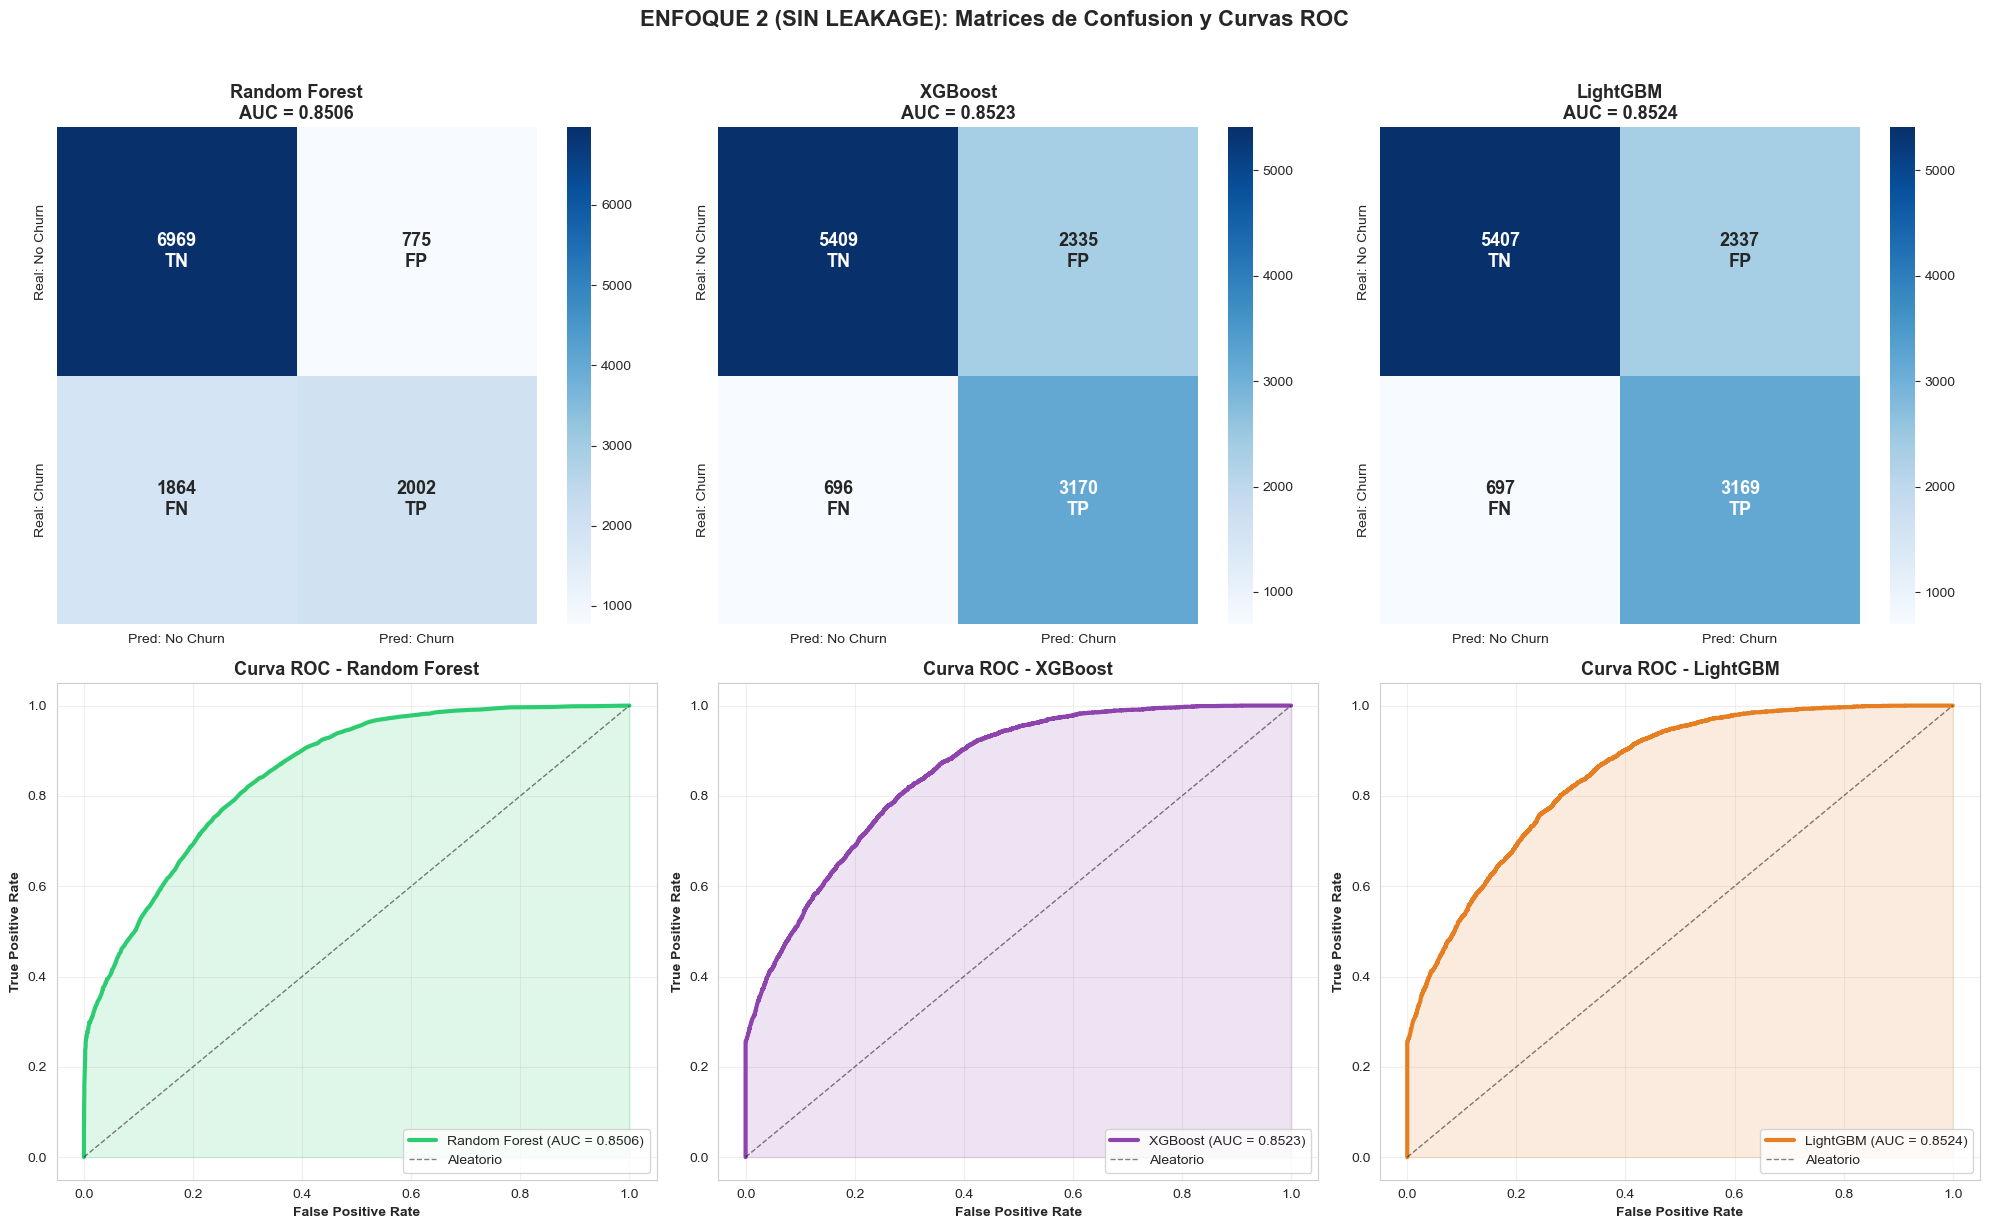

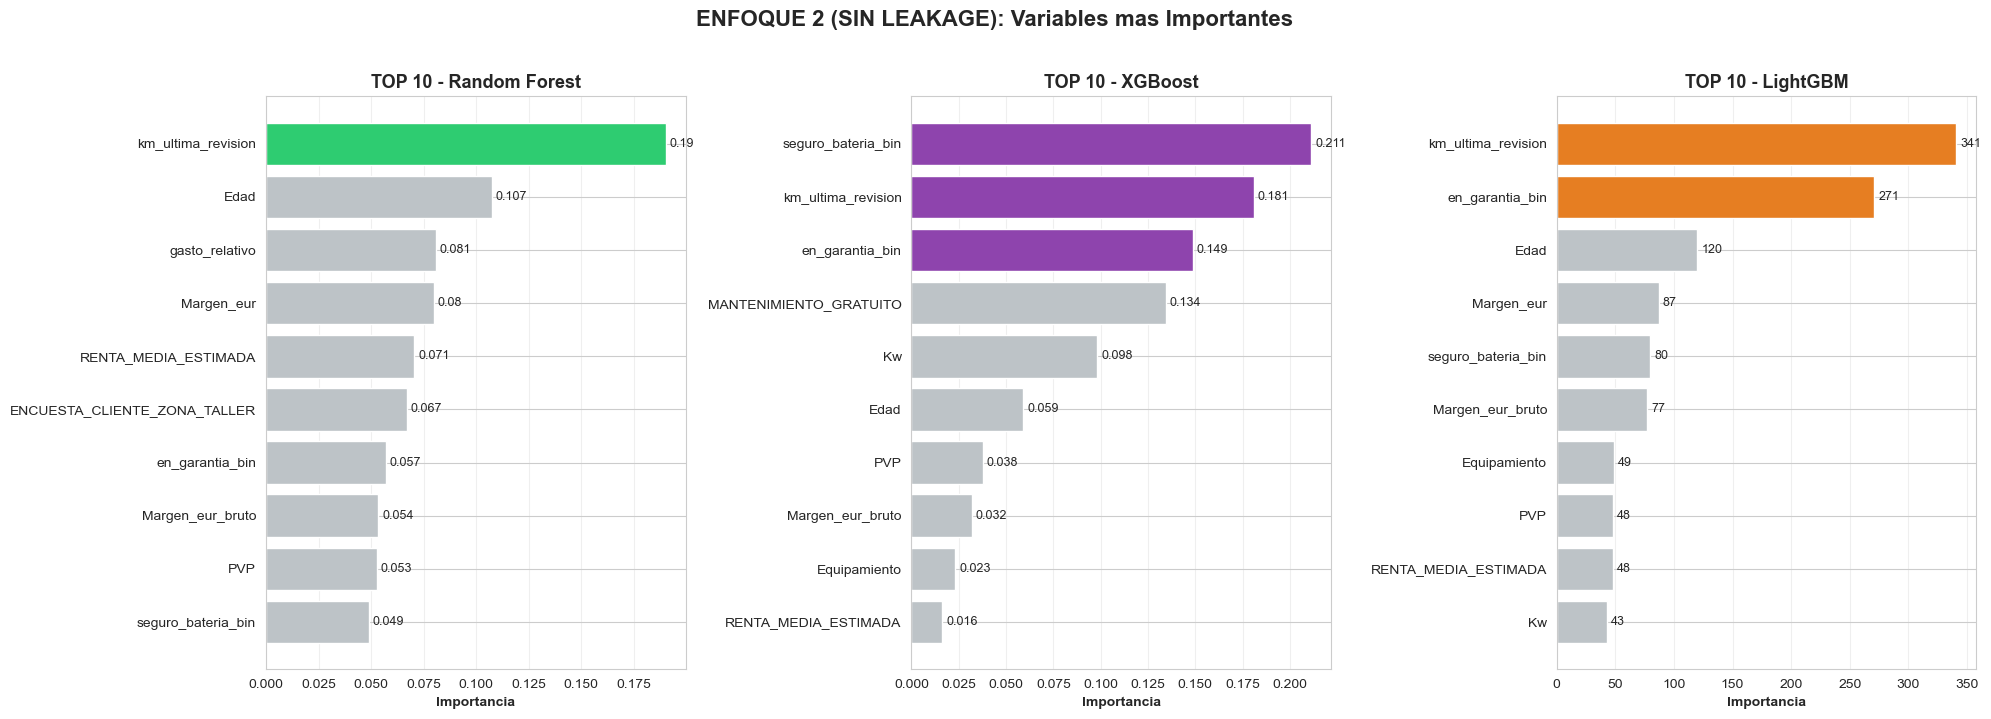

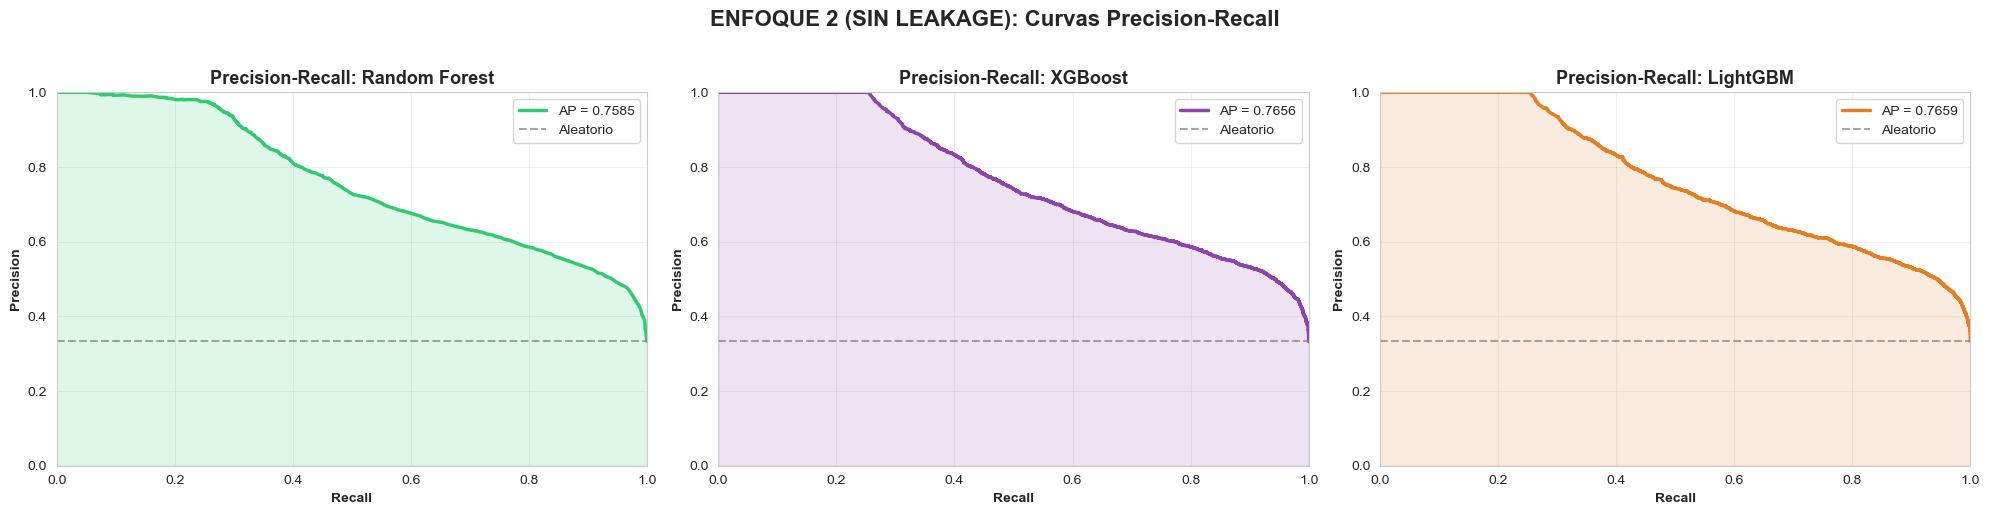

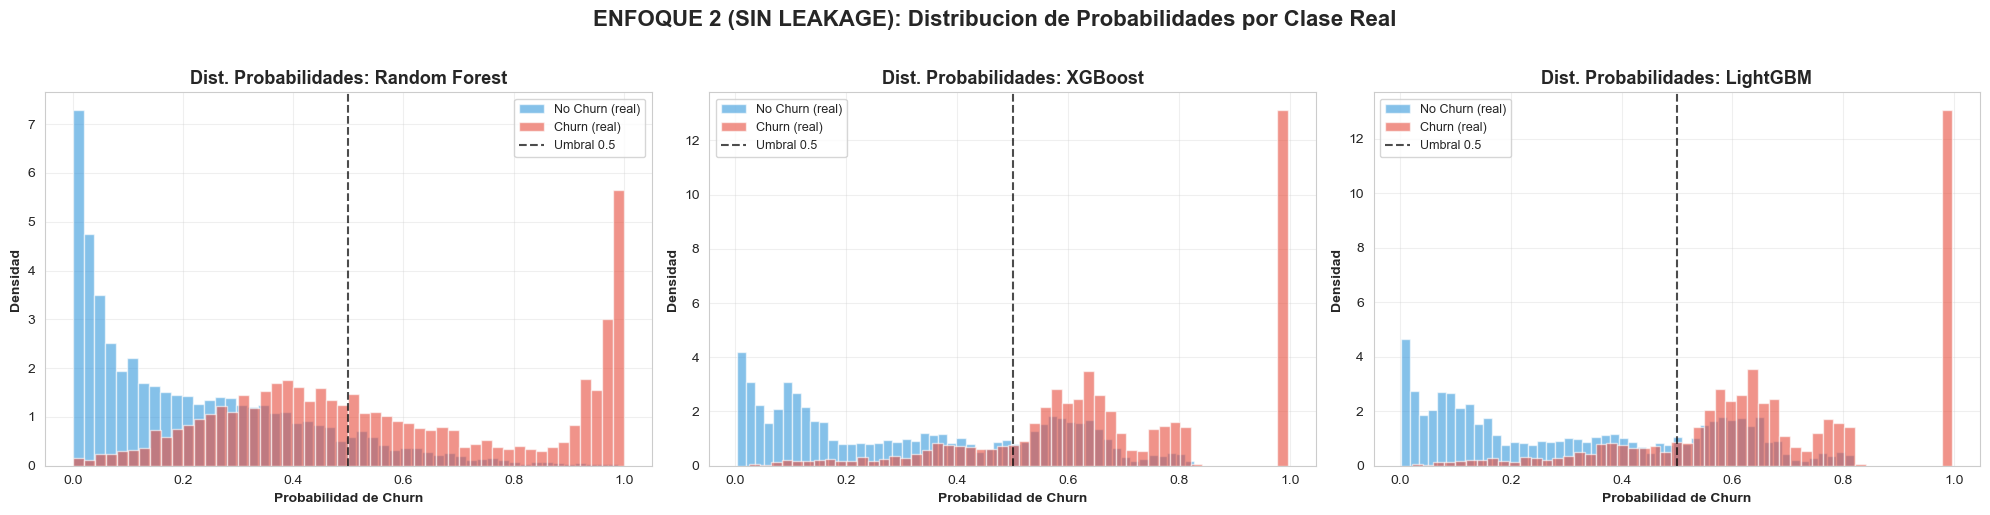


Modelo guardado para Fase 3: XGBoost (xgb_v4)


In [16]:
# =================================================================
# ENFOQUE 2: ENTRENAMIENTO DE 3 MODELOS (SIN LEAKAGE)
# =================================================================
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)
from xgboost import XGBClassifier
import lightgbm as lgb

print('='*70)
print('ENFOQUE 2: ENTRENAMIENTO DE 3 MODELOS (SIN LEAKAGE)')
print('='*70)

ratio_v2 = (y_train_v4 == 0).sum() / (y_train_v4 == 1).sum()
print('Ratio clases (No Churn / Churn): ' + str(round(ratio_v2, 2)))

# =========================================================================
# VALIDACION CRUZADA: Stratified K-Fold (5 folds)
# =========================================================================
print('')
print('='*70)
print('VALIDACION CRUZADA - STRATIFIED K-FOLD (5 FOLDS)')
print('='*70)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_params = {
    'n_estimators': 200, 'max_depth': 3, 'min_child_weight': 10,
    'gamma': 1.0, 'reg_alpha': 1.0, 'reg_lambda': 5.0,
    'learning_rate': 0.05, 'scale_pos_weight': ratio_v2,
    'random_state': 42, 'eval_metric': 'logloss', 'n_jobs': -1
}

cv_results = {'Random Forest': [], 'XGBoost': [], 'LightGBM': []}

for fold, (train_idx, val_idx) in enumerate(skf.split(X_v4, y_v4), 1):
    X_tr, X_val = X_v4.iloc[train_idx], X_v4.iloc[val_idx]
    y_tr, y_val = y_v4.iloc[train_idx], y_v4.iloc[val_idx]

    rf_cv = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                    random_state=42, n_jobs=-1)
    rf_cv.fit(X_tr, y_tr)
    cv_results['Random Forest'].append(roc_auc_score(y_val, rf_cv.predict_proba(X_val)[:, 1]))

    xgb_cv = XGBClassifier(**xgb_params)
    xgb_cv.fit(X_tr, y_tr)
    cv_results['XGBoost'].append(roc_auc_score(y_val, xgb_cv.predict_proba(X_val)[:, 1]))

    lgb_cv = lgb.LGBMClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                                 scale_pos_weight=ratio_v2, random_state=42,
                                 reg_alpha=1.0, reg_lambda=5.0,
                                 min_child_weight=10, n_jobs=-1, verbose=-1)
    lgb_cv.fit(X_tr, y_tr)
    cv_results['LightGBM'].append(roc_auc_score(y_val, lgb_cv.predict_proba(X_val)[:, 1]))

    print('Fold ' + str(fold) + ':  RF=' + str(round(cv_results['Random Forest'][-1], 4)) +
          '  XGB=' + str(round(cv_results['XGBoost'][-1], 4)) +
          '  LGB=' + str(round(cv_results['LightGBM'][-1], 4)))

print('')
print('RESUMEN VALIDACION CRUZADA:')
print('-'*55)
for nombre, aucs in cv_results.items():
    print('{:<15} AUC = {:.4f} +/- {:.4f}'.format(nombre, np.mean(aucs), np.std(aucs)))

# =========================================================================
# ENTRENAR 3 MODELOS FINALES
# =========================================================================
modelos_v2 = {}

print('')
print('='*70)
print('1. RANDOM FOREST - ENFOQUE 2 (sin leakage)')
print('='*70)
rf_v2 = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                random_state=42, n_jobs=-1)
rf_v2.fit(X_train_v4, y_train_v4)
modelos_v2['Random Forest'] = {
    'model': rf_v2,
    'y_pred': rf_v2.predict(X_test_v4),
    'y_prob': rf_v2.predict_proba(X_test_v4)[:, 1],
    'importances': pd.Series(rf_v2.feature_importances_, index=X_train_v4.columns)
}
modelos_v2['Random Forest']['auc'] = roc_auc_score(y_test_v4, modelos_v2['Random Forest']['y_prob'])
print('AUC-ROC: ' + str(round(modelos_v2['Random Forest']['auc'], 4)))
print(classification_report(y_test_v4, modelos_v2['Random Forest']['y_pred'],
                            target_names=['No Churn', 'Churn']))

print('='*70)
print('2. XGBOOST REGULARIZADO - ENFOQUE 2 (sin leakage)')
print('='*70)
xgb_v2 = XGBClassifier(**xgb_params)
xgb_v2.fit(X_train_v4, y_train_v4)
modelos_v2['XGBoost'] = {
    'model': xgb_v2,
    'y_pred': xgb_v2.predict(X_test_v4),
    'y_prob': xgb_v2.predict_proba(X_test_v4)[:, 1],
    'importances': pd.Series(xgb_v2.feature_importances_, index=X_train_v4.columns)
}
modelos_v2['XGBoost']['auc'] = roc_auc_score(y_test_v4, modelos_v2['XGBoost']['y_prob'])
print('AUC-ROC: ' + str(round(modelos_v2['XGBoost']['auc'], 4)))
print(classification_report(y_test_v4, modelos_v2['XGBoost']['y_pred'],
                            target_names=['No Churn', 'Churn']))

print('='*70)
print('3. LIGHTGBM - ENFOQUE 2 (sin leakage)')
print('='*70)
lgb_v2 = lgb.LGBMClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                              scale_pos_weight=ratio_v2, random_state=42,
                              reg_alpha=1.0, reg_lambda=5.0,
                              min_child_weight=10, n_jobs=-1, verbose=-1)
lgb_v2.fit(X_train_v4, y_train_v4)
modelos_v2['LightGBM'] = {
    'model': lgb_v2,
    'y_pred': lgb_v2.predict(X_test_v4),
    'y_prob': lgb_v2.predict_proba(X_test_v4)[:, 1],
    'importances': pd.Series(lgb_v2.feature_importances_, index=X_train_v4.columns)
}
modelos_v2['LightGBM']['auc'] = roc_auc_score(y_test_v4, modelos_v2['LightGBM']['y_prob'])
print('AUC-ROC: ' + str(round(modelos_v2['LightGBM']['auc'], 4)))
print(classification_report(y_test_v4, modelos_v2['LightGBM']['y_pred'],
                            target_names=['No Churn', 'Churn']))

# =========================================================================
# COMPARATIVA
# =========================================================================
print('')
print('='*70)
print('COMPARATIVA: RF vs XGBoost vs LightGBM (Enfoque 2 - Sin Leakage)')
print('='*70)
print('')
print('{:<22} {:>15} {:>15} {:>15}'.format('Metrica', 'Random Forest', 'XGBoost', 'LightGBM'))
print('='*70)
for nombre, datos in modelos_v2.items():
    cm = confusion_matrix(y_test_v4, datos['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    datos['precision'] = tp / (tp + fp) if (tp + fp) > 0 else 0
    datos['recall'] = tp / (tp + fn) if (tp + fn) > 0 else 0
    datos['f1'] = (2 * datos['precision'] * datos['recall'] /
                   (datos['precision'] + datos['recall'])
                   if (datos['precision'] + datos['recall']) > 0 else 0)

print('{:<22} {:>14.1f}% {:>14.1f}% {:>14.1f}%'.format('Precision (Churn)',
    modelos_v2['Random Forest']['precision']*100,
    modelos_v2['XGBoost']['precision']*100,
    modelos_v2['LightGBM']['precision']*100))
print('{:<22} {:>14.1f}% {:>14.1f}% {:>14.1f}%'.format('Recall (Churn)',
    modelos_v2['Random Forest']['recall']*100,
    modelos_v2['XGBoost']['recall']*100,
    modelos_v2['LightGBM']['recall']*100))
print('{:<22} {:>14.1f}% {:>14.1f}% {:>14.1f}%'.format('F1-Score (Churn)',
    modelos_v2['Random Forest']['f1']*100,
    modelos_v2['XGBoost']['f1']*100,
    modelos_v2['LightGBM']['f1']*100))
print('{:<22} {:>14.4f}  {:>14.4f}  {:>14.4f}'.format('AUC-ROC',
    modelos_v2['Random Forest']['auc'],
    modelos_v2['XGBoost']['auc'],
    modelos_v2['LightGBM']['auc']))
print('='*70)

# =========================================================================
# VISUALIZACIONES: Matrices de Confusion + Curvas ROC
# =========================================================================
colores_v2 = {'Random Forest': '#2ecc71', 'XGBoost': '#8e44ad', 'LightGBM': '#e67e22'}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for idx, (nombre, datos) in enumerate(modelos_v2.items()):
    color = colores_v2[nombre]
    cm = confusion_matrix(y_test_v4, datos['y_pred'])
    tn, fp, fn, tp = cm.ravel()

    labels = np.array([[str(tn) + '\nTN', str(fp) + '\nFP'],
                       [str(fn) + '\nFN', str(tp) + '\nTP']])
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=axes[0, idx],
                xticklabels=['Pred: No Churn', 'Pred: Churn'],
                yticklabels=['Real: No Churn', 'Real: Churn'],
                annot_kws={'size': 13, 'weight': 'bold'})
    axes[0, idx].set_title(nombre + '\nAUC = ' + str(round(datos['auc'], 4)),
                           fontsize=13, fontweight='bold')

    fpr, tpr, _ = roc_curve(y_test_v4, datos['y_prob'])
    axes[1, idx].plot(fpr, tpr, color=color, linewidth=3,
                      label=nombre + ' (AUC = ' + str(round(datos['auc'], 4)) + ')')
    axes[1, idx].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Aleatorio')
    axes[1, idx].fill_between(fpr, tpr, alpha=0.15, color=color)
    axes[1, idx].set_xlabel('False Positive Rate', fontweight='bold')
    axes[1, idx].set_ylabel('True Positive Rate', fontweight='bold')
    axes[1, idx].set_title('Curva ROC - ' + nombre, fontsize=13, fontweight='bold')
    axes[1, idx].legend(loc='lower right')
    axes[1, idx].grid(True, alpha=0.3)

plt.suptitle('ENFOQUE 2 (SIN LEAKAGE): Matrices de Confusion y Curvas ROC',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =========================================================================
# TOP 10 VARIABLES MAS IMPORTANTES
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for idx, (nombre, datos) in enumerate(modelos_v2.items()):
    color = colores_v2[nombre]
    top10 = datos['importances'].sort_values(ascending=True).tail(10)

    bar_colors = []
    for var in top10.index:
        if top10[var] >= top10.values[-1] * 0.7:
            bar_colors.append(color)
        else:
            bar_colors.append('#bdc3c7')

    axes[idx].barh(top10.index, top10.values, color=bar_colors, edgecolor='white', linewidth=1)
    axes[idx].set_xlabel('Importancia', fontweight='bold')
    axes[idx].set_title('TOP 10 - ' + nombre, fontsize=13, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='x')
    for var, val in top10.items():
        axes[idx].text(val + max(top10.values)*0.01, var,
                       str(round(val, 3)), va='center', fontsize=9)

plt.suptitle('ENFOQUE 2 (SIN LEAKAGE): Variables mas Importantes',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =========================================================================
# CURVAS PRECISION-RECALL
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
baseline_pr_v2 = (y_test_v4 == 1).sum() / len(y_test_v4)

for idx, (nombre, datos) in enumerate(modelos_v2.items()):
    color = colores_v2[nombre]
    prec_vals, rec_vals, _ = precision_recall_curve(y_test_v4, datos['y_prob'])
    ap = average_precision_score(y_test_v4, datos['y_prob'])

    axes[idx].plot(rec_vals, prec_vals, color=color, linewidth=2.5,
                   label='AP = ' + str(round(ap, 4)))
    axes[idx].axhline(y=baseline_pr_v2, color='gray', linestyle='--', alpha=0.7, label='Aleatorio')
    axes[idx].fill_between(rec_vals, prec_vals, alpha=0.15, color=color)
    axes[idx].set_xlabel('Recall', fontweight='bold')
    axes[idx].set_ylabel('Precision', fontweight='bold')
    axes[idx].set_title('Precision-Recall: ' + nombre, fontsize=13, fontweight='bold')
    axes[idx].legend(loc='upper right')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim([0, 1]); axes[idx].set_ylim([0, 1])

plt.suptitle('ENFOQUE 2 (SIN LEAKAGE): Curvas Precision-Recall',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =========================================================================
# DISTRIBUCION DE PROBABILIDADES: Churn vs No Churn
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for idx, (nombre, datos) in enumerate(modelos_v2.items()):
    churn_mask = y_test_v4.values == 1
    no_churn_mask = y_test_v4.values == 0

    axes[idx].hist(datos['y_prob'][no_churn_mask], bins=50, alpha=0.6,
                   color='#3498db', label='No Churn (real)', density=True)
    axes[idx].hist(datos['y_prob'][churn_mask], bins=50, alpha=0.6,
                   color='#e74c3c', label='Churn (real)', density=True)
    axes[idx].axvline(x=0.5, color='black', linestyle='--', linewidth=1.5,
                      alpha=0.7, label='Umbral 0.5')
    axes[idx].set_xlabel('Probabilidad de Churn', fontweight='bold')
    axes[idx].set_ylabel('Densidad', fontweight='bold')
    axes[idx].set_title('Dist. Probabilidades: ' + nombre, fontsize=13, fontweight='bold')
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('ENFOQUE 2 (SIN LEAKAGE): Distribucion de Probabilidades por Clase Real',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Guardar modelo XGBoost para Fase 3
xgb_v4 = modelos_v2['XGBoost']['model']
print('')
print('Modelo guardado para Fase 3: XGBoost (xgb_v4)')

## Conclusion Enfoque 2: Modelo sin Leakage Logico

### Que hemos demostrado

| Enfoque | Idea principal | Leakage | Conclusion |
|---------|---------------|---------|------------|
| 1. Feature Engineering | `nunca_ha_venido` + todas las features | SI | Variables que definen el target siguen presentes |
| **2. Sin leakage** | **Eliminar `Revisiones`, `antiguedad_dias` y `perfil_cliente`** | **NO** | **Capacidad predictiva REAL** |

### Por que elegimos el Enfoque 2

1. **Sin leakage logico:** Eliminamos las variables (`Revisiones`, `antiguedad_dias`) que definen el target y `perfil_cliente` que es derivada directa de `Revisiones`
2. **Generalizable a nuevos clientes:** Sin `perfil_cliente`, el modelo predice en funcion de caracteristicas del vehiculo, cliente y contexto comercial, no por si han ido o no al taller
3. **Todos los clientes incluidos:** Usamos los 58,049 clientes (no descartamos datos)
4. **Validacion robusta:** Stratified K-Fold confirma estabilidad en los 3 modelos
5. **3 modelos comparados:** Random Forest, XGBoost y LightGBM permiten evaluar consistencia

---
---

# Enfoque 3: Blindaje Total (Sin Proxies)

## Diagnostico: Leakage indirecto por `km_ultima_revision`

En el Enfoque 2 eliminamos `Revisiones`, `antiguedad_dias` y `perfil_cliente`. Sin embargo,
al analizar las features restantes descubrimos que **`km_ultima_revision` es un proxy PERFECTO**
del estado ghost:

| | km_ultima_revision = 0 | km_ultima_revision > 0 |
|---|---|---|
| **Clientes** | 27,070 (100% ghost) | 30,979 (100% no-ghost) |
| **Churn_Final = 1** | 67.3% | 16.4% |

Es decir, el modelo sigue teniendo acceso a la informacion de si el cliente fue al taller o no,
a traves de `km_ultima_revision`. Esto explica por que el AUC apenas baja entre el Enfoque 1 y 2.

## Solucion: Blindaje completo

| Cambio | Razon |
|--------|-------|
| **Target: `Churn_bin` original (8.8%)** | Eliminar la redefinicion que inflaba el churn al 33.3% |
| **Eliminar `km_ultima_revision`** | Es proxy perfecto de `Revisiones == 0` |
| **Eliminar `perfil_cliente`** | Derivada directa de `Revisiones == 0` |
| **Eliminar `Revisiones`, `antiguedad_dias`** | No estan en el DataMart, pero verificamos igualmente |

### Features finales (22 variables)

| Tipo | Variables | Encoding |
|------|-----------|----------|
| **Numericas (8)** | `PVP`, `Edad`, `RENTA_MEDIA_ESTIMADA`, `gasto_relativo`, `Kw`, `Margen_eur_bruto`, `Margen_eur`, `ENCUESTA_CLIENTE_ZONA_TALLER` | Tal cual |
| **Binarias (7)** | `tiene_queja`, `en_garantia_bin`, `MANTENIMIENTO_GRATUITO`, `Lead_compra`, `seguro_bateria_bin`, `sin_encuesta`, `origen_internet` | 0/1 |
| **Categoricas (7)** | `Modelo`, `ZONA`, `Equipamiento`, `FORMA_PAGO`, `TIPO_CARROCERIA`, `Fuel`, `TRANSMISION_ID` | Label Encoding |

### Objetivo

Ver la capacidad predictiva **real** del modelo usando solo perfil del cliente y del coche,
sin ninguna pista del historial de taller. Esto es lo que un modelo realmente podria predecir
sobre un cliente nuevo del que solo conocemos sus datos demograficos y del vehiculo.


ENFOQUE 3: BLINDAJE TOTAL (SIN PROXIES)

PASO 1: Target original Churn_bin
-------------------------------------------------------
Target: Churn_bin (original del dataset)
Churn=1: 5093 (8.8%)
Churn=0: 52956 (91.2%)

PASO 2: Separar X (sin proxies de taller)
-------------------------------------------------------
Features finales: 22

VERIFICACION ANTI-LEAKAGE:
   OK: Revisiones NO esta en features
   OK: antiguedad_dias NO esta en features
   OK: DAYS_LAST_SERVICE NO esta en features
   OK: Km_medio_por_revision NO esta en features
   OK: nunca_ha_venido NO esta en features
   OK: perfil_cliente NO esta en features
   OK: km_ultima_revision NO esta en features

PASO 3: Train/Test Split (80/20)
-------------------------------------------------------

                  Filas      Churn    % Churn
---------------------------------------------
Train             46439       4074       8.8%
Test              11610       1019       8.8%

Ratio clases (No Churn / Churn): 10.4

1. RANDOM FORES

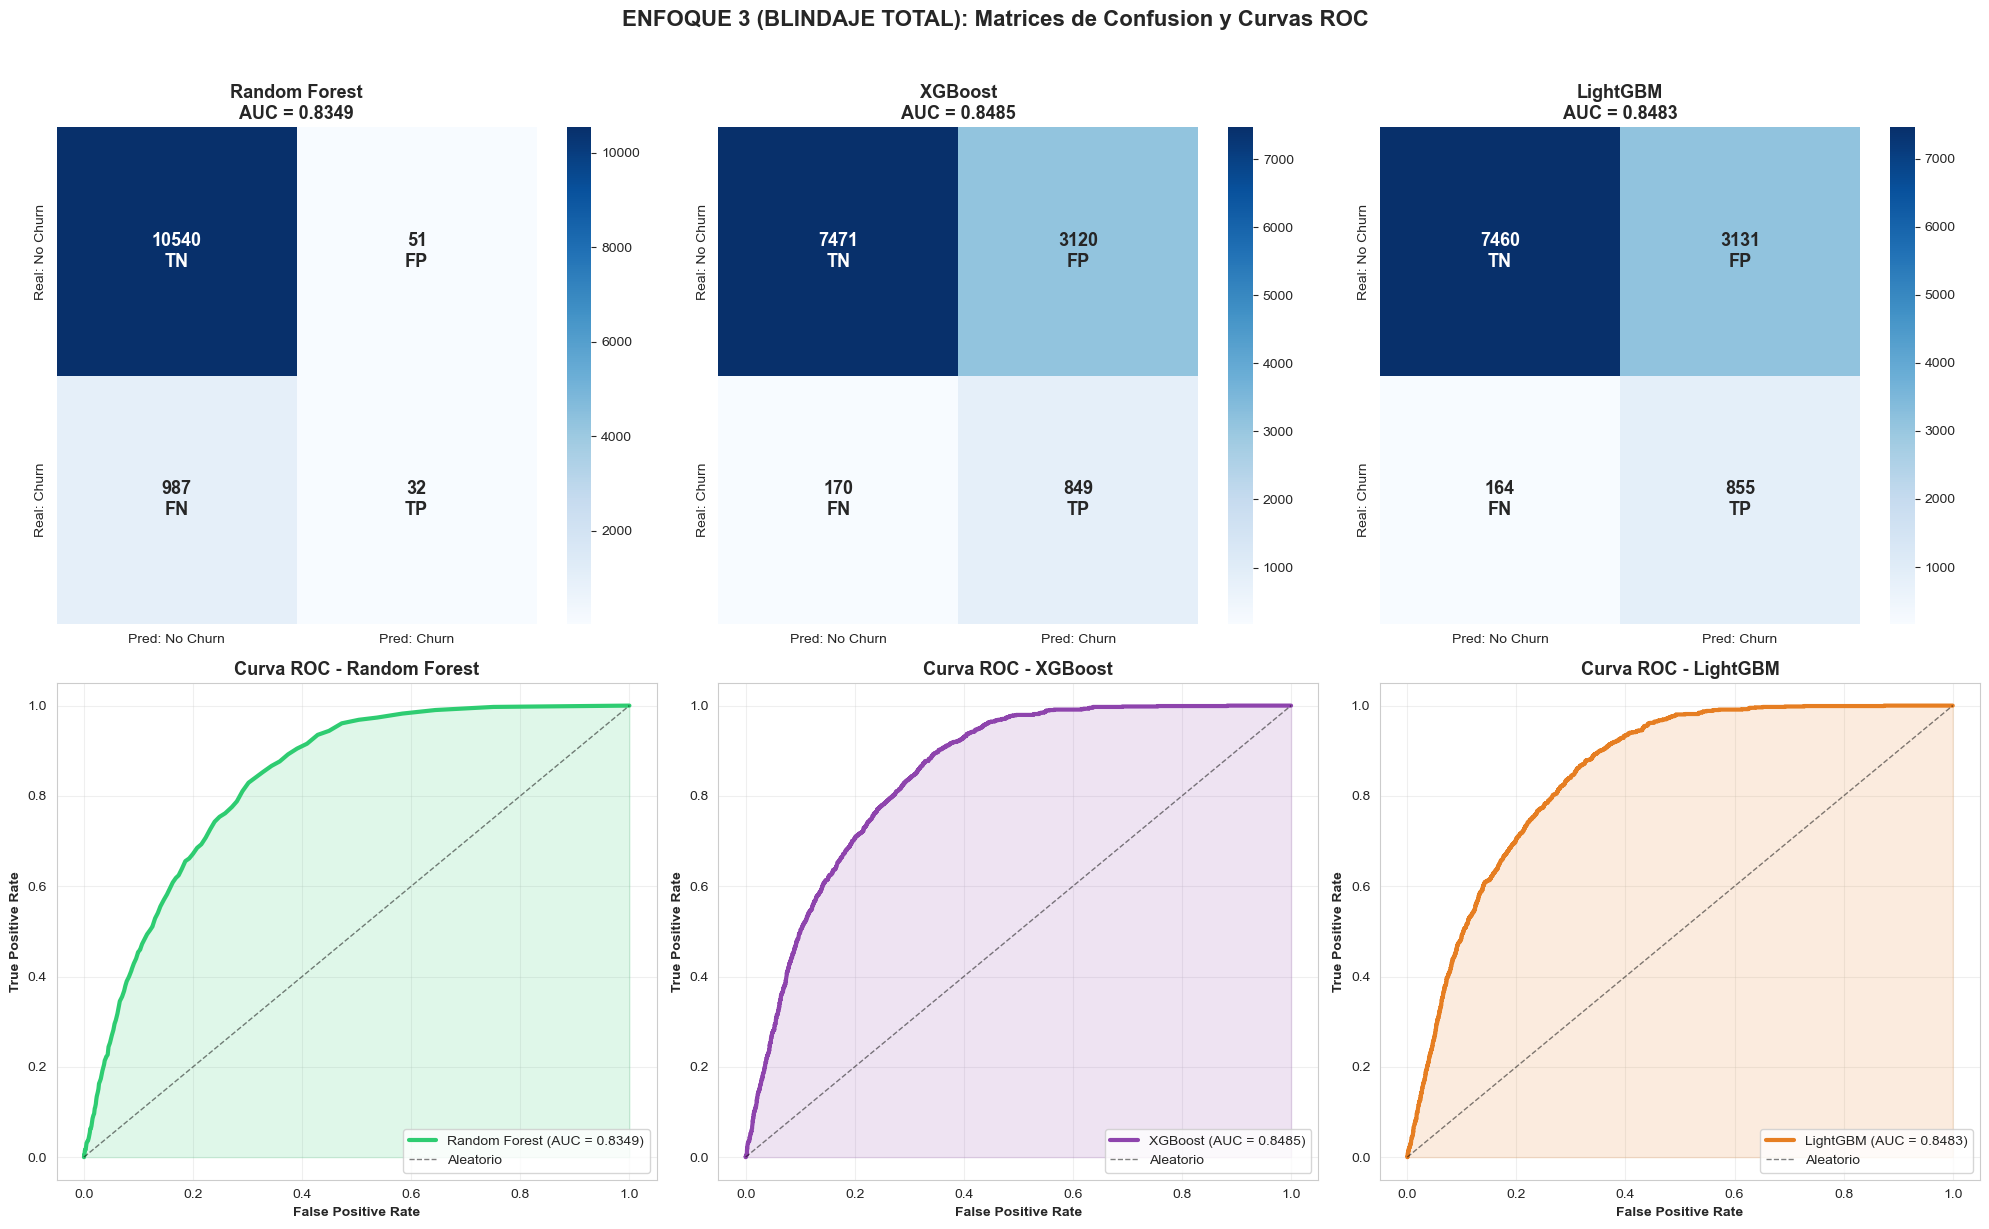

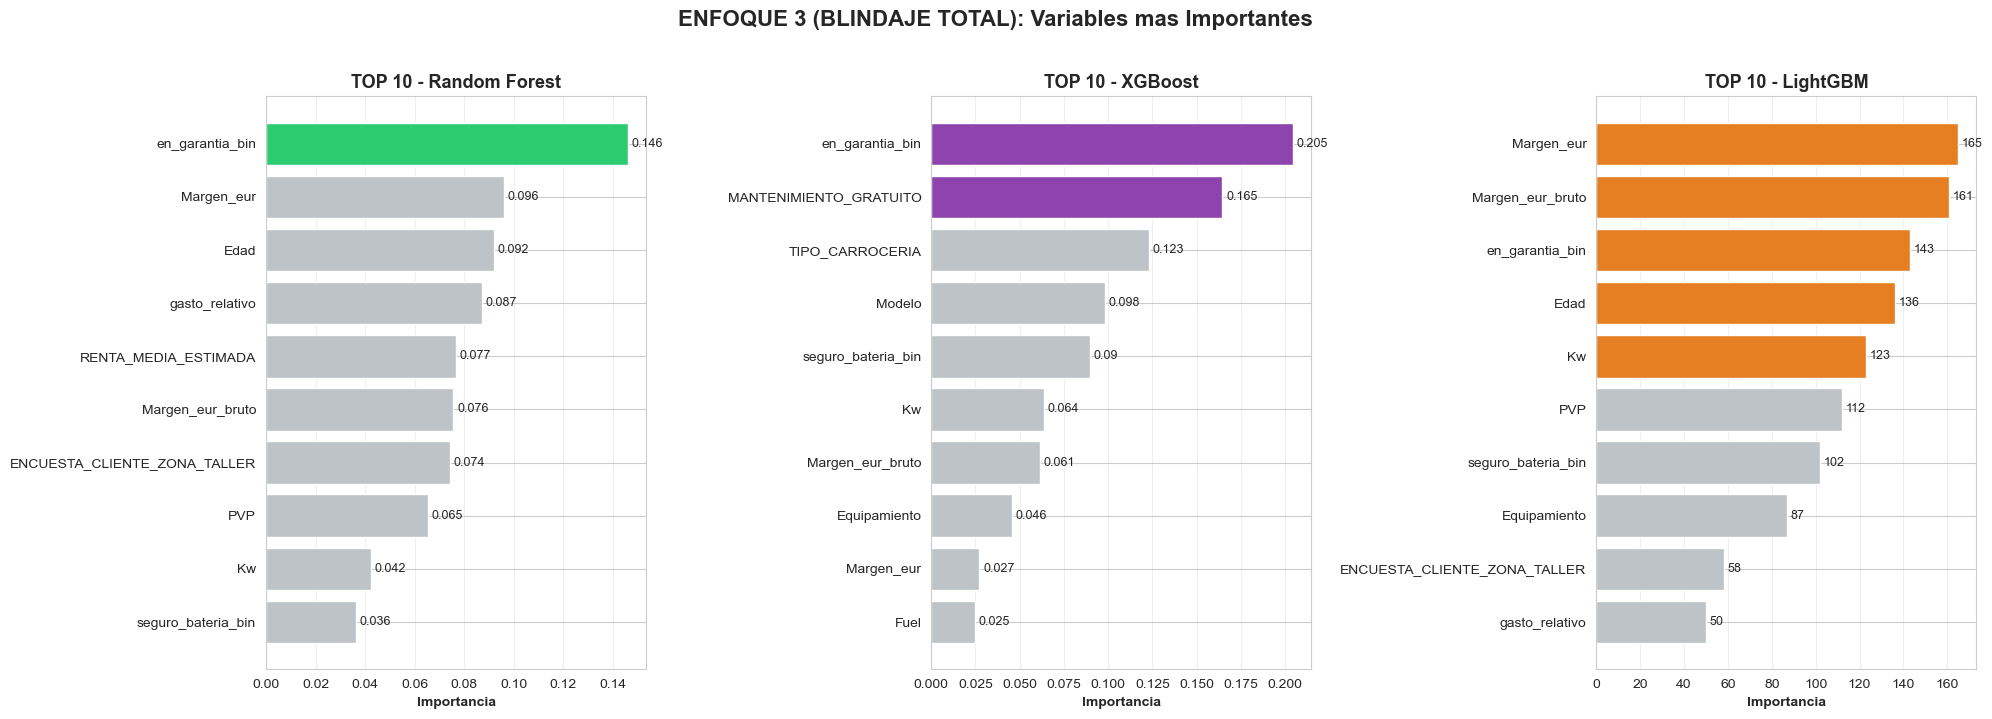

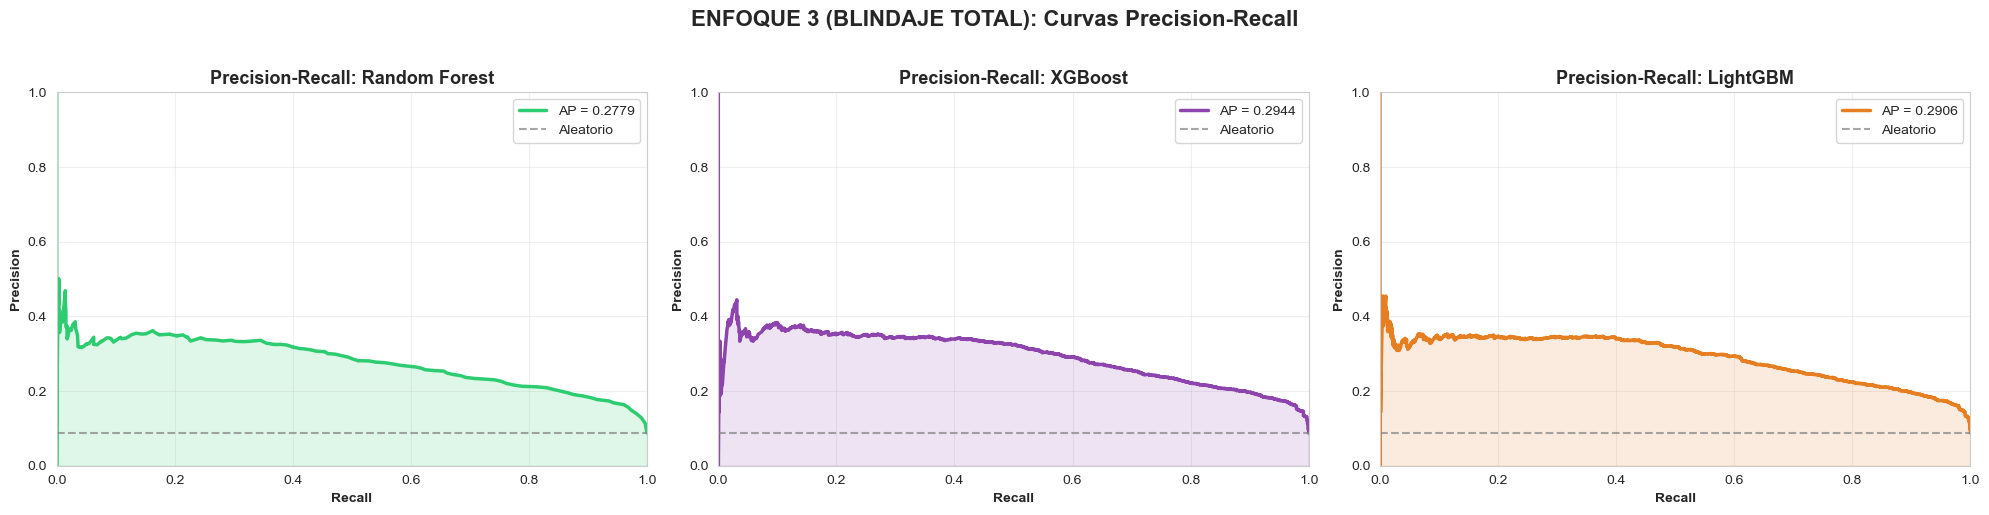

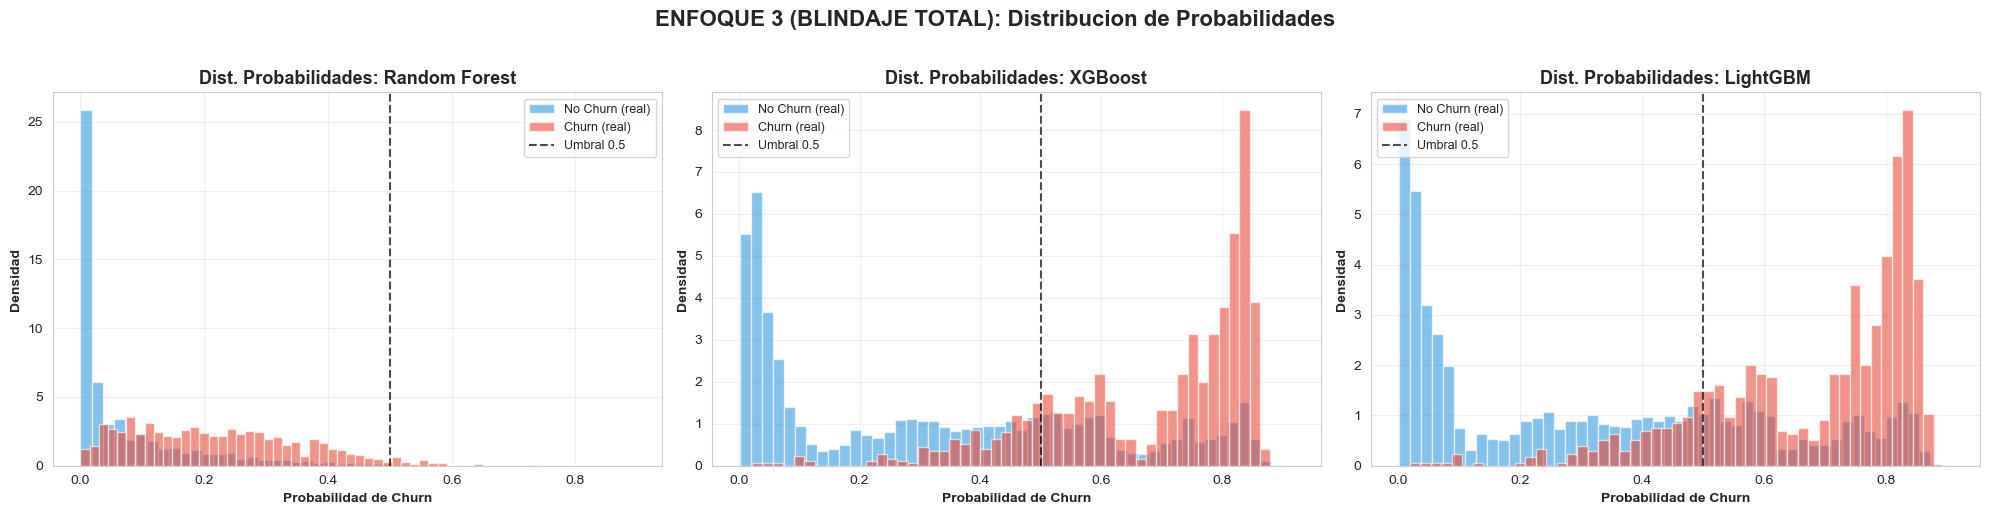

In [17]:
# =================================================================
# ENFOQUE 3: BLINDAJE TOTAL (SIN PROXIES)
# =================================================================
print('='*70)
print('ENFOQUE 3: BLINDAJE TOTAL (SIN PROXIES)')
print('='*70)

# Cargar DataMart
dm_v3 = pd.read_csv('./Data/Datamart/datamart_final_v2.csv')

# ---------------------------------------------------------------
# PASO 1: Target ORIGINAL (Churn_bin = 8.8%)
# ---------------------------------------------------------------
print('')
print('PASO 1: Target original Churn_bin')
print('-'*55)
y_v3 = dm_v3['Churn_bin']  # Target ORIGINAL, sin redefinicion
print('Target: Churn_bin (original del dataset)')
print('Churn=1: ' + str(y_v3.sum()) + ' (' + str(round(y_v3.mean()*100, 1)) + '%)')
print('Churn=0: ' + str((y_v3==0).sum()) + ' (' + str(round((y_v3==0).mean()*100, 1)) + '%)')

# ---------------------------------------------------------------
# PASO 2: Separar X (SIN PROXIES)
# ---------------------------------------------------------------
print('')
print('PASO 2: Separar X (sin proxies de taller)')
print('-'*55)

cols_drop_v3 = [c for c in ['Churn_bin', 'Churn_Final', 'Churn_Corregido',
                             'perfil_cliente', 'km_ultima_revision'] if c in dm_v3.columns]
X_v3 = dm_v3.drop(columns=cols_drop_v3)
print('Features finales: ' + str(X_v3.shape[1]))
print('')
print('VERIFICACION ANTI-LEAKAGE:')
prohibidas_v3 = ['Revisiones', 'antiguedad_dias', 'DAYS_LAST_SERVICE',
                  'Km_medio_por_revision', 'nunca_ha_venido', 'perfil_cliente',
                  'km_ultima_revision']
for var in prohibidas_v3:
    if var in X_v3.columns:
        print('   ERROR: ' + var + ' esta en features!')
    else:
        print('   OK: ' + var + ' NO esta en features')

# ---------------------------------------------------------------
# PASO 3: Train/Test Split
# ---------------------------------------------------------------
print('')
print('PASO 3: Train/Test Split (80/20)')
print('-'*55)

X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3, y_v3, test_size=0.2, random_state=42, stratify=y_v3
)

print('')
print('{:<12} {:>10} {:>10} {:>10}'.format('', 'Filas', 'Churn', '% Churn'))
print('-'*45)
print('{:<12} {:>10} {:>10} {:>9}%'.format('Train', str(len(X_train_v3)),
      str((y_train_v3==1).sum()), str(round((y_train_v3==1).mean()*100,1))))
print('{:<12} {:>10} {:>10} {:>9}%'.format('Test', str(len(X_test_v3)),
      str((y_test_v3==1).sum()), str(round((y_test_v3==1).mean()*100,1))))

# =========================================================================
# ENTRENAR 3 MODELOS
# =========================================================================
ratio_v3 = (y_train_v3 == 0).sum() / (y_train_v3 == 1).sum()
print('')
print('Ratio clases (No Churn / Churn): ' + str(round(ratio_v3, 2)))
modelos_v3 = {}

print('')
print('='*70)
print('1. RANDOM FOREST - ENFOQUE 3 (blindaje total)')
print('='*70)
rf_v3 = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                random_state=42, n_jobs=-1)
rf_v3.fit(X_train_v3, y_train_v3)
modelos_v3['Random Forest'] = {
    'model': rf_v3,
    'y_pred': rf_v3.predict(X_test_v3),
    'y_prob': rf_v3.predict_proba(X_test_v3)[:, 1],
    'importances': pd.Series(rf_v3.feature_importances_, index=X_train_v3.columns)
}
modelos_v3['Random Forest']['auc'] = roc_auc_score(y_test_v3, modelos_v3['Random Forest']['y_prob'])
print('AUC-ROC: ' + str(round(modelos_v3['Random Forest']['auc'], 4)))
print(classification_report(y_test_v3, modelos_v3['Random Forest']['y_pred'],
                            target_names=['No Churn', 'Churn']))

print('='*70)
print('2. XGBOOST REGULARIZADO - ENFOQUE 3 (blindaje total)')
print('='*70)
xgb_params_v3 = {
    'n_estimators': 200, 'max_depth': 3, 'min_child_weight': 10,
    'gamma': 1.0, 'reg_alpha': 1.0, 'reg_lambda': 5.0,
    'learning_rate': 0.05, 'scale_pos_weight': ratio_v3,
    'random_state': 42, 'eval_metric': 'logloss', 'n_jobs': -1
}
xgb_v3 = XGBClassifier(**xgb_params_v3)
xgb_v3.fit(X_train_v3, y_train_v3)
modelos_v3['XGBoost'] = {
    'model': xgb_v3,
    'y_pred': xgb_v3.predict(X_test_v3),
    'y_prob': xgb_v3.predict_proba(X_test_v3)[:, 1],
    'importances': pd.Series(xgb_v3.feature_importances_, index=X_train_v3.columns)
}
modelos_v3['XGBoost']['auc'] = roc_auc_score(y_test_v3, modelos_v3['XGBoost']['y_prob'])
print('AUC-ROC: ' + str(round(modelos_v3['XGBoost']['auc'], 4)))
print(classification_report(y_test_v3, modelos_v3['XGBoost']['y_pred'],
                            target_names=['No Churn', 'Churn']))

print('='*70)
print('3. LIGHTGBM - ENFOQUE 3 (blindaje total)')
print('='*70)
lgb_v3 = lgb.LGBMClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                              scale_pos_weight=ratio_v3, random_state=42,
                              reg_alpha=1.0, reg_lambda=5.0,
                              min_child_weight=10, n_jobs=-1, verbose=-1)
lgb_v3.fit(X_train_v3, y_train_v3)
modelos_v3['LightGBM'] = {
    'model': lgb_v3,
    'y_pred': lgb_v3.predict(X_test_v3),
    'y_prob': lgb_v3.predict_proba(X_test_v3)[:, 1],
    'importances': pd.Series(lgb_v3.feature_importances_, index=X_train_v3.columns)
}
modelos_v3['LightGBM']['auc'] = roc_auc_score(y_test_v3, modelos_v3['LightGBM']['y_prob'])
print('AUC-ROC: ' + str(round(modelos_v3['LightGBM']['auc'], 4)))
print(classification_report(y_test_v3, modelos_v3['LightGBM']['y_pred'],
                            target_names=['No Churn', 'Churn']))

# =========================================================================
# COMPARATIVA ENFOQUE 3
# =========================================================================
print('')
print('='*70)
print('COMPARATIVA: RF vs XGBoost vs LightGBM (Enfoque 3 - Blindaje Total)')
print('='*70)
print('')
print('{:<22} {:>15} {:>15} {:>15}'.format('Metrica', 'Random Forest', 'XGBoost', 'LightGBM'))
print('='*70)
for nombre, datos in modelos_v3.items():
    cm = confusion_matrix(y_test_v3, datos['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    datos['precision'] = tp / (tp + fp) if (tp + fp) > 0 else 0
    datos['recall'] = tp / (tp + fn) if (tp + fn) > 0 else 0
    datos['f1'] = (2 * datos['precision'] * datos['recall'] /
                   (datos['precision'] + datos['recall'])
                   if (datos['precision'] + datos['recall']) > 0 else 0)

print('{:<22} {:>14.1f}% {:>14.1f}% {:>14.1f}%'.format('Precision (Churn)',
    modelos_v3['Random Forest']['precision']*100,
    modelos_v3['XGBoost']['precision']*100,
    modelos_v3['LightGBM']['precision']*100))
print('{:<22} {:>14.1f}% {:>14.1f}% {:>14.1f}%'.format('Recall (Churn)',
    modelos_v3['Random Forest']['recall']*100,
    modelos_v3['XGBoost']['recall']*100,
    modelos_v3['LightGBM']['recall']*100))
print('{:<22} {:>14.1f}% {:>14.1f}% {:>14.1f}%'.format('F1-Score (Churn)',
    modelos_v3['Random Forest']['f1']*100,
    modelos_v3['XGBoost']['f1']*100,
    modelos_v3['LightGBM']['f1']*100))
print('{:<22} {:>14.4f}  {:>14.4f}  {:>14.4f}'.format('AUC-ROC',
    modelos_v3['Random Forest']['auc'],
    modelos_v3['XGBoost']['auc'],
    modelos_v3['LightGBM']['auc']))
print('='*70)

# =========================================================================
# VISUALIZACIONES
# =========================================================================
colores_v3 = {'Random Forest': '#2ecc71', 'XGBoost': '#8e44ad', 'LightGBM': '#e67e22'}

# CM + ROC
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for idx, (nombre, datos) in enumerate(modelos_v3.items()):
    color = colores_v3[nombre]
    cm = confusion_matrix(y_test_v3, datos['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    labels = np.array([[str(tn) + '\nTN', str(fp) + '\nFP'],
                       [str(fn) + '\nFN', str(tp) + '\nTP']])
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=axes[0, idx],
                xticklabels=['Pred: No Churn', 'Pred: Churn'],
                yticklabels=['Real: No Churn', 'Real: Churn'],
                annot_kws={'size': 13, 'weight': 'bold'})
    axes[0, idx].set_title(nombre + '\nAUC = ' + str(round(datos['auc'], 4)),
                           fontsize=13, fontweight='bold')
    fpr, tpr, _ = roc_curve(y_test_v3, datos['y_prob'])
    axes[1, idx].plot(fpr, tpr, color=color, linewidth=3,
                      label=nombre + ' (AUC = ' + str(round(datos['auc'], 4)) + ')')
    axes[1, idx].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Aleatorio')
    axes[1, idx].fill_between(fpr, tpr, alpha=0.15, color=color)
    axes[1, idx].set_xlabel('False Positive Rate', fontweight='bold')
    axes[1, idx].set_ylabel('True Positive Rate', fontweight='bold')
    axes[1, idx].set_title('Curva ROC - ' + nombre, fontsize=13, fontweight='bold')
    axes[1, idx].legend(loc='lower right')
    axes[1, idx].grid(True, alpha=0.3)
plt.suptitle('ENFOQUE 3 (BLINDAJE TOTAL): Matrices de Confusion y Curvas ROC',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# TOP 10 VARIABLES
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for idx, (nombre, datos) in enumerate(modelos_v3.items()):
    color = colores_v3[nombre]
    top10 = datos['importances'].sort_values(ascending=True).tail(10)
    bar_colors = [color if top10[v] >= top10.values[-1] * 0.7 else '#bdc3c7' for v in top10.index]
    axes[idx].barh(top10.index, top10.values, color=bar_colors, edgecolor='white', linewidth=1)
    axes[idx].set_xlabel('Importancia', fontweight='bold')
    axes[idx].set_title('TOP 10 - ' + nombre, fontsize=13, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='x')
    for var, val in top10.items():
        axes[idx].text(val + max(top10.values)*0.01, var, str(round(val, 3)), va='center', fontsize=9)
plt.suptitle('ENFOQUE 3 (BLINDAJE TOTAL): Variables mas Importantes',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# PRECISION-RECALL
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
baseline_pr_v3 = (y_test_v3 == 1).sum() / len(y_test_v3)
for idx, (nombre, datos) in enumerate(modelos_v3.items()):
    color = colores_v3[nombre]
    prec_vals, rec_vals, _ = precision_recall_curve(y_test_v3, datos['y_prob'])
    ap = average_precision_score(y_test_v3, datos['y_prob'])
    axes[idx].plot(rec_vals, prec_vals, color=color, linewidth=2.5, label='AP = ' + str(round(ap, 4)))
    axes[idx].axhline(y=baseline_pr_v3, color='gray', linestyle='--', alpha=0.7, label='Aleatorio')
    axes[idx].fill_between(rec_vals, prec_vals, alpha=0.15, color=color)
    axes[idx].set_xlabel('Recall', fontweight='bold')
    axes[idx].set_ylabel('Precision', fontweight='bold')
    axes[idx].set_title('Precision-Recall: ' + nombre, fontsize=13, fontweight='bold')
    axes[idx].legend(loc='upper right')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim([0, 1]); axes[idx].set_ylim([0, 1])
plt.suptitle('ENFOQUE 3 (BLINDAJE TOTAL): Curvas Precision-Recall',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# DISTRIBUCION PROBABILIDADES
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for idx, (nombre, datos) in enumerate(modelos_v3.items()):
    churn_mask = y_test_v3.values == 1
    no_churn_mask = y_test_v3.values == 0
    axes[idx].hist(datos['y_prob'][no_churn_mask], bins=50, alpha=0.6,
                   color='#3498db', label='No Churn (real)', density=True)
    axes[idx].hist(datos['y_prob'][churn_mask], bins=50, alpha=0.6,
                   color='#e74c3c', label='Churn (real)', density=True)
    axes[idx].axvline(x=0.5, color='black', linestyle='--', linewidth=1.5,
                      alpha=0.7, label='Umbral 0.5')
    axes[idx].set_xlabel('Probabilidad de Churn', fontweight='bold')
    axes[idx].set_ylabel('Densidad', fontweight='bold')
    axes[idx].set_title('Dist. Probabilidades: ' + nombre, fontsize=13, fontweight='bold')
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)
plt.suptitle('ENFOQUE 3 (BLINDAJE TOTAL): Distribucion de Probabilidades',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


COMPARATIVA GLOBAL: ENFOQUE 1 vs ENFOQUE 2 vs ENFOQUE 3

Metrica                        E1-RF     E1-XGB     E1-LGB      E2-RF     E2-XGB     E2-LGB      E3-RF     E3-XGB     E3-LGB
AUC-ROC                       0.8509     0.8560     0.8580     0.8506     0.8523     0.8524     0.8349     0.8485     0.8483
Recall (Churn)                 52.1%      80.0%      80.7%      51.8%      82.0%      82.0%       3.1%      83.3%      83.9%
Precision (Churn)              71.7%      59.5%      59.1%      72.1%      57.6%      57.6%      38.6%      21.4%      21.5%
F1-Score                       60.4%      68.2%      68.2%      60.3%      67.7%      67.6%       5.8%      34.0%      34.2%

Target usado:
  E1, E2: Churn_Final (33.3%) = Churn_bin | (Revisiones=0 & antiguedad>400)
  E3:     Churn_bin  (8.8%)  = Churn_400 original


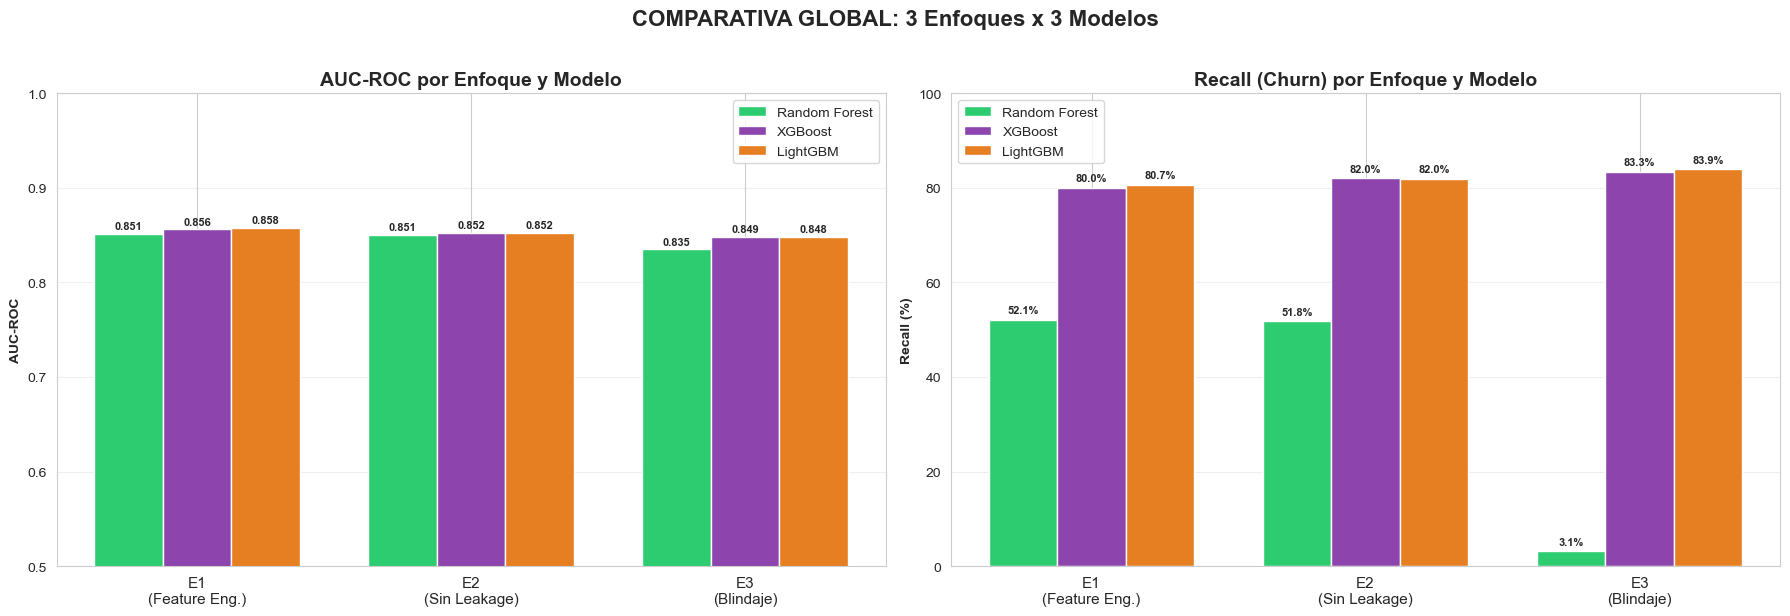

In [18]:
# =================================================================
# COMPARATIVA GLOBAL: 3 ENFOQUES
# =================================================================
print('='*90)
print('COMPARATIVA GLOBAL: ENFOQUE 1 vs ENFOQUE 2 vs ENFOQUE 3')
print('='*90)
print()

# Recopilar datos de los 3 enfoques
enfoques = {
    'E1 (Feature Eng.)': modelos_v1,
    'E2 (Sin Leakage)': modelos_v2,
    'E3 (Blindaje Total)': modelos_v3
}

# Tabla comparativa
header = '{:<25}'.format('Metrica')
for enf_name in enfoques.keys():
    for mod in ['RF', 'XGB', 'LGB']:
        header += ' {:>10}'.format(enf_name.split('(')[0].strip() + '-' + mod)
print(header)
print('='*120)

for metric_name, metric_key in [('AUC-ROC', 'auc'), ('Recall (Churn)', 'recall'),
                                 ('Precision (Churn)', 'precision'), ('F1-Score', 'f1')]:
    row = '{:<25}'.format(metric_name)
    for enf_name, modelos_enf in enfoques.items():
        for mod_name in ['Random Forest', 'XGBoost', 'LightGBM']:
            val = modelos_enf[mod_name][metric_key]
            if metric_key == 'auc':
                row += ' {:>10.4f}'.format(val)
            else:
                row += ' {:>9.1f}%'.format(val * 100)
    print(row)

print('='*120)
print()
print('Target usado:')
print('  E1, E2: Churn_Final (33.3%) = Churn_bin | (Revisiones=0 & antiguedad>400)')
print('  E3:     Churn_bin  (8.8%)  = Churn_400 original')

# =========================================================================
# GRAFICO COMPARATIVO
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

enf_labels = ['E1\n(Feature Eng.)', 'E2\n(Sin Leakage)', 'E3\n(Blindaje)']
mod_names = ['Random Forest', 'XGBoost', 'LightGBM']
colores_mod = ['#2ecc71', '#8e44ad', '#e67e22']
x = np.arange(len(enf_labels))
width = 0.25

# AUC-ROC
for i, (mod, color) in enumerate(zip(mod_names, colores_mod)):
    vals = [modelos_v1[mod]['auc'], modelos_v2[mod]['auc'], modelos_v3[mod]['auc']]
    bars = axes[0].bar(x + i*width - width, vals, width, label=mod, color=color,
                       edgecolor='white', linewidth=1)
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                     str(round(val, 3)), ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[0].set_title('AUC-ROC por Enfoque y Modelo', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(enf_labels, fontsize=11)
axes[0].set_ylabel('AUC-ROC', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_ylim([0.5, 1.0])
axes[0].grid(True, alpha=0.3, axis='y')

# Recall
for i, (mod, color) in enumerate(zip(mod_names, colores_mod)):
    vals = [modelos_v1[mod]['recall']*100, modelos_v2[mod]['recall']*100, modelos_v3[mod]['recall']*100]
    bars = axes[1].bar(x + i*width - width, vals, width, label=mod, color=color,
                       edgecolor='white', linewidth=1)
    for bar, val in zip(bars, vals):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     str(round(val, 1)) + '%', ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[1].set_title('Recall (Churn) por Enfoque y Modelo', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(enf_labels, fontsize=11)
axes[1].set_ylabel('Recall (%)', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_ylim([0, 100])
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('COMPARATIVA GLOBAL: 3 Enfoques x 3 Modelos',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Conclusion Enfoque 3: Blindaje Total

### Comparativa de los 3 enfoques

| Enfoque | Target | Features | Leakage | Proposito |
|---------|--------|----------|---------|----------|
| 1. Feature Engineering | Churn_Final (33.3%) | 25 (con `nunca_ha_venido`, `perfil_cliente`) | SI (directo) | Baseline con todas las features |
| 2. Sin Leakage | Churn_Final (33.3%) | 23 (sin `Revisiones`, `antiguedad_dias`, `perfil_cliente`) | PARCIAL (`km_ultima_revision` es proxy) | Modelo principal |
| **3. Blindaje Total** | **Churn_bin (8.8%)** | **22 (sin `km_ultima_revision`)** | **NO** | **Capacidad predictiva pura** |

### Interpretacion

El Enfoque 3 muestra la capacidad **real** del modelo para predecir churn usando unicamente
el perfil del cliente y del vehiculo, sin ninguna variable derivada del historial de taller.

- Si el AUC del E3 es similar al E2, significa que `km_ultima_revision` no aportaba mucho
- Si el AUC del E3 baja significativamente, confirma que `km_ultima_revision` era un proxy importante
- El target original (8.8%) es el que usan los companeros, por lo que E3 es directamente comparable

### Recomendacion final

Para la **Fase 3 (prediccion en nuevos clientes)**, el Enfoque 3 es el mas honesto: predice
usando el target real del dataset y sin ningun proxy del taller. Las predicciones seran mas
conservadoras pero reflejan la verdadera capacidad del modelo.


---
---

# FASE 3: PREDICCION EN DATOS FRESH (10,000 nuevos clientes)

**Objetivo:** Aplicar el modelo ganador (XGBoost Regularizado - Enfoque 2) a los 10,000 nuevos clientes
para predecir su probabilidad de churn.

**Pipeline de prediccion:**
1. Cargar `nuevos_clientes.csv` (datos raw del DataLake)
2. Aplicar **exactamente** el mismo preprocesamiento que el modelo de entrenamiento (sin `perfil_cliente`)
3. Alinear columnas para garantizar compatibilidad
4. Predecir probabilidades de churn
5. Analizar y segmentar resultados

**Nota importante:** Los nuevos clientes son de 2024 (posteriores al corte 31/12/2023).
Todos estan en garantia y ninguno tiene quejas registradas.
La variable `perfil_cliente` se excluye porque todos los nuevos clientes son Ghost por definicion
(no han tenido tiempo de visitar el taller).

In [19]:
# =================================================================
# CARGA Y PREPROCESAMIENTO: NUEVOS CLIENTES (DATOS FRESH)
# =================================================================
# Pipeline IDENTICO al DataMart v2 (sin perfil_cliente):
#   - Mismas variables derivadas (excepto perfil_cliente)
#   - Mismo Label Encoding (reutilizando label_encoders)
# =================================================================
print('='*70)
print('CARGA Y PREPROCESAMIENTO: 10,000 NUEVOS CLIENTES')
print('='*70)

fresh = pd.read_csv('./Data/DataLake/nuevos_clientes.csv')
print('')
print('Archivo cargado: nuevos_clientes.csv')
print('   Filas:    ' + str(len(fresh)))
print('   Columnas: ' + str(len(fresh.columns)))

# -----------------------------------------------------------------
# PASO 1: Crear variables derivadas (SIN perfil_cliente)
# -----------------------------------------------------------------
print('')
print('PASO 1: Crear variables derivadas')
print('-'*55)

fresh['QUEJA'] = fresh['QUEJA'].fillna('NO')
fresh['tiene_queja'] = (fresh['QUEJA'].str.upper().str.strip() == 'SI').astype(int)
fresh['en_garantia_bin'] = (fresh['EN_GARANTIA'].fillna('NO').str.upper().str.strip() == 'SI').astype(int)
fresh['gasto_relativo'] = fresh['PVP'] / fresh['RENTA_MEDIA_ESTIMADA'].clip(lower=1)
fresh['seguro_bateria_bin'] = (fresh['SEGURO_BATERIA_LARGO_PLAZO'].fillna('NO').str.upper().str.strip() == 'SI').astype(int)
fresh['sin_encuesta'] = fresh['ENCUESTA_CLIENTE_ZONA_TALLER'].isnull().astype(int)
fresh['ENCUESTA_CLIENTE_ZONA_TALLER'] = fresh['ENCUESTA_CLIENTE_ZONA_TALLER'].fillna(0)
fresh['origen_internet'] = (fresh['Origen'].fillna('Tienda').str.strip() == 'Internet').astype(int)

# perfil_cliente NO se incluye: todos los nuevos clientes son Ghost (Revisiones=0)
# por definicion, al no haber tenido tiempo de ir al taller.
n_ghost = (fresh['Revisiones'] == 0).sum()
print(f'   Nota: {n_ghost} de {len(fresh)} clientes tienen Revisiones=0 (Ghost)')
print(f'   perfil_cliente EXCLUIDA: no aporta valor para nuevos clientes')
print(f'   origen_internet:    {fresh["origen_internet"].sum()} de Internet')
print(f'   Lead_compra:        {fresh["Lead_compra"].sum()} con lead')

# -----------------------------------------------------------------
# PASO 2: Seleccionar features (mismas que modelo Enfoque 2, SIN perfil_cliente)
# -----------------------------------------------------------------
print('')
print('PASO 2: Seleccionar features')
print('-'*55)

features_numericas = [
    'km_ultima_revision', 'PVP', 'Edad', 'RENTA_MEDIA_ESTIMADA',
    'gasto_relativo', 'Kw', 'Margen_eur_bruto', 'Margen_eur',
    'ENCUESTA_CLIENTE_ZONA_TALLER'
]
features_binarias = [
    'tiene_queja', 'en_garantia_bin', 'MANTENIMIENTO_GRATUITO',
    'Lead_compra', 'seguro_bateria_bin',
    'sin_encuesta', 'origen_internet'
]
cats_label_cols = ['Modelo', 'ZONA', 'Equipamiento', 'FORMA_PAGO',
                   'TIPO_CARROCERIA', 'Fuel', 'TRANSMISION_ID']

todas_cols = features_numericas + features_binarias + cats_label_cols
fresh_features = fresh[todas_cols].copy()

print(f'   Features seleccionadas: {len(todas_cols)}')

# Nulos
for col in features_numericas:
    if col == 'ENCUESTA_CLIENTE_ZONA_TALLER':
        continue
    n_null = fresh_features[col].isnull().sum()
    if n_null > 0:
        fresh_features[col] = fresh_features[col].fillna(fresh_features[col].median())
        print(f'   Nulos en {col}: {n_null} -> mediana')

for col in cats_label_cols:
    n_null = fresh_features[col].isnull().sum()
    if n_null > 0:
        fresh_features[col] = fresh_features[col].fillna(fresh_features[col].mode()[0])
        print(f'   Nulos en {col}: {n_null} -> moda')

# -----------------------------------------------------------------
# PASO 3: Label Encoding (usando encoders del entrenamiento)
# -----------------------------------------------------------------
print('')
print('PASO 3: Label Encoding')
print('-'*55)

for col in cats_label_cols:
    le = label_encoders[col]
    known = set(le.classes_)
    fresh_features[col] = fresh_features[col].astype(str).apply(
        lambda x: le.transform([x])[0] if x in known else -1
    )
    n_unknown = (fresh_features[col] == -1).sum()
    print(f'   {col:20s}: codificado ({n_unknown} desconocidas)')

# -----------------------------------------------------------------
# PASO 4: Alinear columnas con modelo
# -----------------------------------------------------------------
print('')
print('PASO 4: Alinear con modelo entrenado')
print('-'*55)

train_columns = X_train_v4.columns.tolist()
fresh_aligned = fresh_features.reindex(columns=train_columns, fill_value=0)

cols_ok = list(fresh_aligned.columns) == train_columns
print('   Columnas modelo:   ' + str(len(train_columns)))
print('   Columnas fresh:    ' + str(len(fresh_features.columns)))
print('   Alineacion:        ' + ('OK' if cols_ok else 'REVISAR'))

print('')
print('='*70)
print('DATOS FRESH LISTOS PARA PREDICCION')
print('='*70)
print(f'Shape final: {fresh_aligned.shape[0]} filas x {fresh_aligned.shape[1]} features')

CARGA Y PREPROCESAMIENTO: 10,000 NUEVOS CLIENTES

Archivo cargado: nuevos_clientes.csv
   Filas:    10000
   Columnas: 38

PASO 1: Crear variables derivadas
-------------------------------------------------------
   Nota: 10000 de 10000 clientes tienen Revisiones=0 (Ghost)
   perfil_cliente EXCLUIDA: no aporta valor para nuevos clientes
   origen_internet:    5439 de Internet
   Lead_compra:        1267 con lead

PASO 2: Seleccionar features
-------------------------------------------------------
   Features seleccionadas: 23

PASO 3: Label Encoding
-------------------------------------------------------
   Modelo              : codificado (0 desconocidas)
   ZONA                : codificado (0 desconocidas)
   Equipamiento        : codificado (0 desconocidas)
   FORMA_PAGO          : codificado (0 desconocidas)
   TIPO_CARROCERIA     : codificado (0 desconocidas)
   Fuel                : codificado (0 desconocidas)
   TRANSMISION_ID      : codificado (0 desconocidas)

PASO 4: Alinear 

In [20]:
# =================================================================
# PREDICCION: PROBABILIDAD DE CHURN EN NUEVOS CLIENTES
# =================================================================
print('='*70)
print('PREDICCION DE CHURN - 10,000 NUEVOS CLIENTES')
print('='*70)

# Predecir probabilidades con el modelo del Enfoque 2
fresh_probs = xgb_v4.predict_proba(fresh_aligned)[:, 1]
fresh_preds = xgb_v4.predict(fresh_aligned)

# Crear DataFrame de resultados
resultados = fresh[['CODE', 'Customer_ID', 'Modelo', 'ZONA', 'FORMA_PAGO',
                     'PVP', 'Edad', 'RENTA_MEDIA_ESTIMADA', 'Revisiones']].copy()
resultados['prob_churn'] = fresh_probs
resultados['pred_churn'] = fresh_preds

# Segmentar por nivel de riesgo
def segmento_riesgo(prob):
    if prob >= 0.7:
        return 'ALTO'
    elif prob >= 0.4:
        return 'MEDIO'
    else:
        return 'BAJO'

resultados['riesgo'] = resultados['prob_churn'].apply(segmento_riesgo)

# -----------------------------------------------------------------
# RESUMEN GENERAL
# -----------------------------------------------------------------
print('')
print('RESUMEN DE PREDICCIONES')
print('-'*55)

n_churn = (resultados['pred_churn'] == 1).sum()
n_no = (resultados['pred_churn'] == 0).sum()
print('Prediccion (umbral 0.5):')
print('   Churn:     ' + str(n_churn) + ' clientes (' + str(round(n_churn/len(resultados)*100,1)) + '%)')
print('   No Churn:  ' + str(n_no) + ' clientes (' + str(round(n_no/len(resultados)*100,1)) + '%)')

print('')
print('Segmentacion por riesgo:')
for seg in ['ALTO', 'MEDIO', 'BAJO']:
    n = (resultados['riesgo'] == seg).sum()
    prob_media = resultados[resultados['riesgo'] == seg]['prob_churn'].mean()
    print('   ' + seg + ':   ' + str(n) + ' clientes (' + str(round(n/len(resultados)*100,1)) + '%) | prob media: ' + str(round(prob_media*100,1)) + '%')

print('')
print('Probabilidad de churn:')
print('   Media:   ' + str(round(resultados['prob_churn'].mean()*100, 1)) + '%')
print('   Mediana:  ' + str(round(resultados['prob_churn'].median()*100, 1)) + '%')
print('   Min:      ' + str(round(resultados['prob_churn'].min()*100, 1)) + '%')
print('   Max:      ' + str(round(resultados['prob_churn'].max()*100, 1)) + '%')

PREDICCION DE CHURN - 10,000 NUEVOS CLIENTES

RESUMEN DE PREDICCIONES
-------------------------------------------------------
Prediccion (umbral 0.5):
   Churn:     7641 clientes (76.4%)
   No Churn:  2359 clientes (23.6%)

Segmentacion por riesgo:
   ALTO:   1161 clientes (11.6%) | prob media: 77.1%
   MEDIO:   7358 clientes (73.6%) | prob media: 58.7%
   BAJO:   1481 clientes (14.8%) | prob media: 7.2%

Probabilidad de churn:
   Media:   53.2%
   Mediana:  58.7%
   Min:      0.7%
   Max:      83.0%


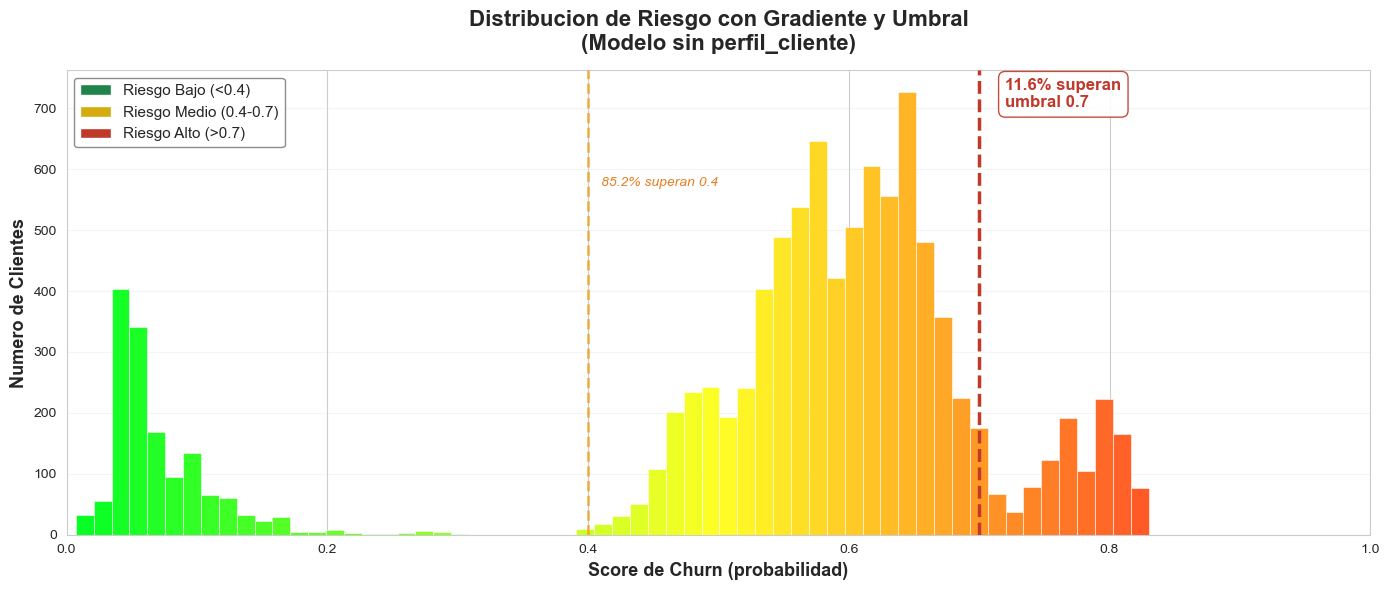

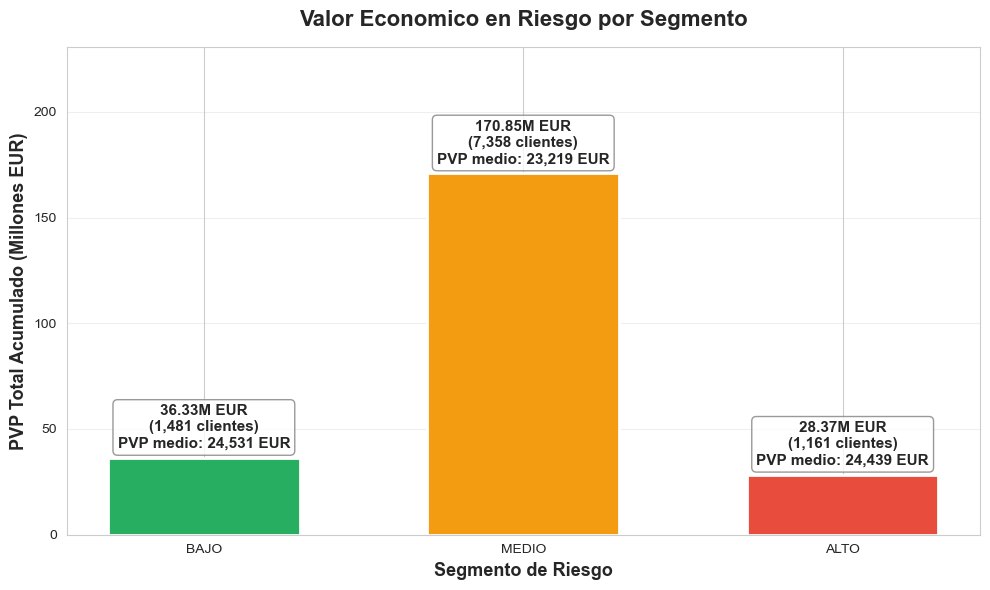

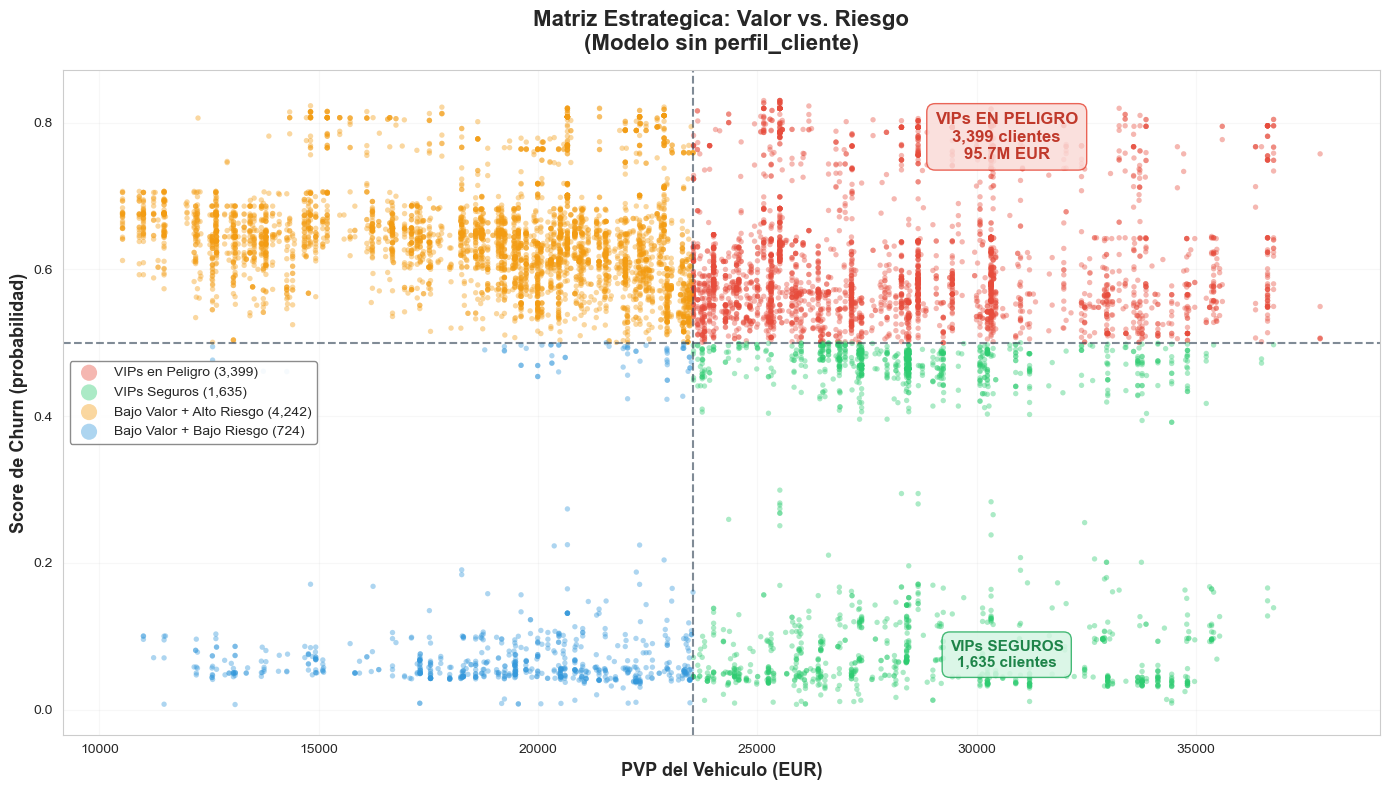

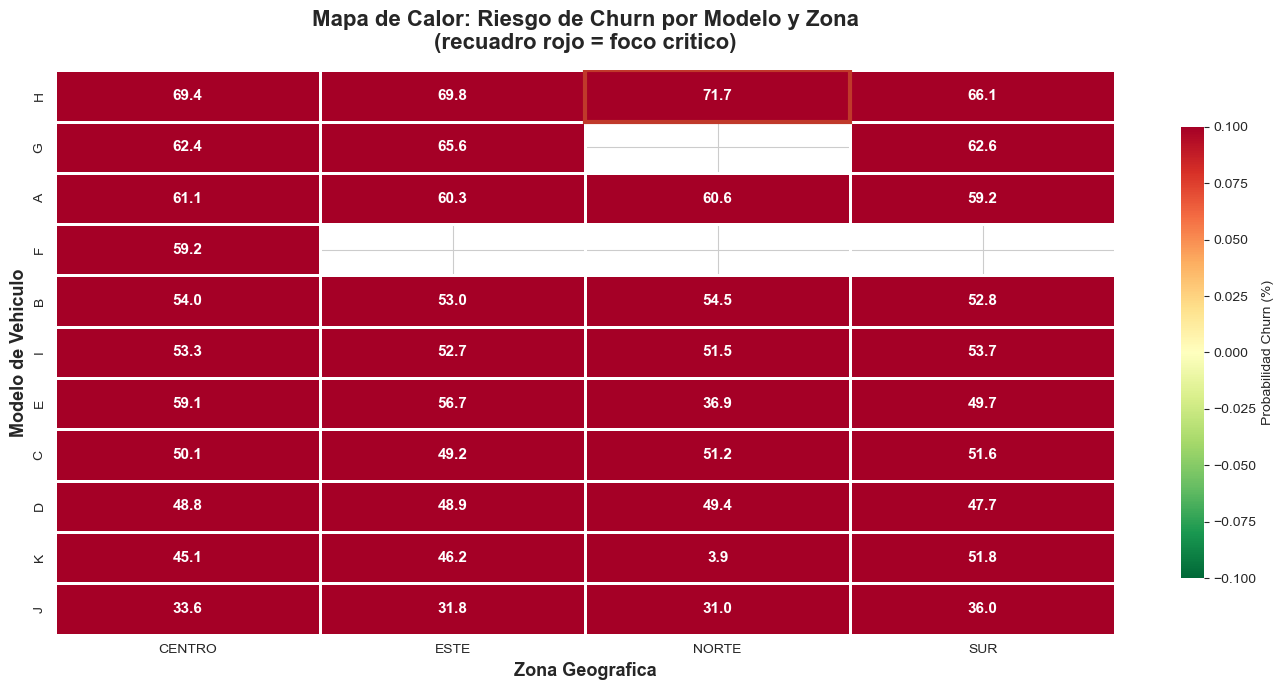


RESUMEN EJECUTIVO: PREDICCION EN NUEVOS CLIENTES

VALOR ECONOMICO EN RIESGO ALTO:
-------------------------------------------------------
   Clientes en riesgo alto:   1,161 de 10,000 (11.6%)
   PVP total en riesgo alto:  28,373,932 EUR (28.37M EUR)
   PVP total cartera:         235,553,275 EUR (235.55M EUR)
   % del valor en peligro:    12.0%

FOCO CRITICO (mayor probabilidad de fuga):
-------------------------------------------------------
   Modelo:  H
   Zona:    NORTE
   Prob. media de churn: 71.7%

TOP 3 combinaciones Modelo/Zona con mayor riesgo:
   1. H en NORTE: 71.7% churn, 49.0 clientes, 1,033,863 EUR
   2. H en ESTE: 69.8% churn, 133.0 clientes, 2,888,221 EUR
   3. H en CENTRO: 69.4% churn, 237.0 clientes, 5,148,713 EUR

VIPs EN PELIGRO (alto valor + alta prob. churn):
-------------------------------------------------------
   Clientes:  3,399
   PVP total: 95,712,511 EUR (95.71M EUR)


In [21]:
# =================================================================
# VISUALIZACION AVANZADA: PREDICCIONES DE CHURN EN NUEVOS CLIENTES
# =================================================================
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

# =============================================
# FIGURA 1: Distribucion de Riesgo con Gradiente y Umbral
# =============================================
fig, ax = plt.subplots(figsize=(14, 6))

# Histograma base (transparente, solo para obtener los bins)
n_bins = 60
counts, bin_edges, _ = ax.hist(resultados['prob_churn'], bins=n_bins,
                                edgecolor='white', linewidth=0.5, alpha=0)

# Redibujar cada barra con gradiente verde -> amarillo -> rojo
ax.cla()
for i in range(len(counts)):
    center = (bin_edges[i] + bin_edges[i+1]) / 2
    # Gradiente: 0.0 = verde puro, 0.5 = amarillo, 1.0 = rojo puro
    r = min(1.0, center * 2)
    g = min(1.0, 2.0 - center * 2)
    color = (r, g, 0.15)
    ax.bar(bin_edges[i], counts[i], width=bin_edges[i+1]-bin_edges[i],
           color=color, edgecolor='white', linewidth=0.4, align='edge')

# Linea umbral 0.7
ax.axvline(x=0.7, color='#c0392b', linewidth=2.5, linestyle='--', zorder=5)
pct_above_07 = (resultados['prob_churn'] >= 0.7).mean() * 100
ax.text(0.72, ax.get_ylim()[1] * 0.92,
        f'{pct_above_07:.1f}% superan\numbral 0.7',
        fontsize=12, fontweight='bold', color='#c0392b',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#c0392b', alpha=0.9))

# Linea umbral 0.4
ax.axvline(x=0.4, color='#f39c12', linewidth=2, linestyle='--', alpha=0.7, zorder=5)
pct_above_04 = (resultados['prob_churn'] >= 0.4).mean() * 100
ax.text(0.41, ax.get_ylim()[1] * 0.75,
        f'{pct_above_04:.1f}% superan 0.4',
        fontsize=10, color='#e67e22', fontstyle='italic')

ax.set_xlabel('Score de Churn (probabilidad)', fontsize=13, fontweight='bold')
ax.set_ylabel('Numero de Clientes', fontsize=13, fontweight='bold')
ax.set_title('Distribucion de Riesgo con Gradiente y Umbral\n(Modelo sin perfil_cliente)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlim([0, 1])
ax.grid(True, alpha=0.2, axis='y')

# Leyenda manual
legend_elements = [
    Patch(facecolor='#1e8449', label='Riesgo Bajo (<0.4)'),
    Patch(facecolor='#d4ac0d', label='Riesgo Medio (0.4-0.7)'),
    Patch(facecolor='#c0392b', label='Riesgo Alto (>0.7)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11,
          framealpha=0.9, edgecolor='gray')
plt.tight_layout()
plt.show()

# =============================================
# FIGURA 2: Valor Economico en Riesgo por Segmento
# =============================================
fig, ax = plt.subplots(figsize=(10, 6))

pvp_por_seg = resultados.groupby('riesgo')['PVP'].sum().reindex(['BAJO', 'MEDIO', 'ALTO'])
pvp_millones = pvp_por_seg / 1_000_000

colors_seg = {'BAJO': '#27ae60', 'MEDIO': '#f39c12', 'ALTO': '#e74c3c'}
bars = ax.bar(pvp_millones.index, pvp_millones.values,
              color=[colors_seg[s] for s in pvp_millones.index],
              edgecolor='white', linewidth=2, width=0.6)

# Etiquetas sobre cada barra
for bar, seg in zip(bars, pvp_millones.index):
    val = bar.get_height()
    n_clientes = (resultados['riesgo'] == seg).sum()
    pvp_medio = resultados[resultados['riesgo'] == seg]['PVP'].mean()
    ax.text(bar.get_x() + bar.get_width()/2, val + pvp_millones.max()*0.02,
            f'{val:,.2f}M EUR\n({n_clientes:,} clientes)\nPVP medio: {pvp_medio:,.0f} EUR',
            ha='center', va='bottom', fontweight='bold', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

ax.set_xlabel('Segmento de Riesgo', fontsize=13, fontweight='bold')
ax.set_ylabel('PVP Total Acumulado (Millones EUR)', fontsize=13, fontweight='bold')
ax.set_title('Valor Economico en Riesgo por Segmento',
             fontsize=16, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, pvp_millones.max() * 1.35])
plt.tight_layout()
plt.show()

# =============================================
# FIGURA 3: Matriz Estrategica 'Valor vs. Riesgo'
# =============================================
fig, ax = plt.subplots(figsize=(14, 8))

# Umbrales para los cuadrantes
umbral_pvp = resultados['PVP'].median()
umbral_churn = 0.5

# Asignar cuadrante a cada cliente
def cuadrante(row):
    if row['PVP'] >= umbral_pvp and row['prob_churn'] >= umbral_churn:
        return 'VIPs en Peligro'
    elif row['PVP'] >= umbral_pvp and row['prob_churn'] < umbral_churn:
        return 'VIPs Seguros'
    elif row['PVP'] < umbral_pvp and row['prob_churn'] >= umbral_churn:
        return 'Bajo Valor + Alto Riesgo'
    else:
        return 'Bajo Valor + Bajo Riesgo'

resultados['cuadrante'] = resultados.apply(cuadrante, axis=1)

colores_cuad = {
    'VIPs en Peligro': '#e74c3c',
    'VIPs Seguros': '#2ecc71',
    'Bajo Valor + Alto Riesgo': '#f39c12',
    'Bajo Valor + Bajo Riesgo': '#3498db'
}

# Scatter por cuadrante
for cuad, color in colores_cuad.items():
    mask = resultados['cuadrante'] == cuad
    n = mask.sum()
    ax.scatter(resultados.loc[mask, 'PVP'],
               resultados.loc[mask, 'prob_churn'],
               c=color, alpha=0.4, s=15, label=f'{cuad} ({n:,})', edgecolors='none')

# Lineas de cuadrante
ax.axhline(y=umbral_churn, color='#2c3e50', linewidth=1.5, linestyle='--', alpha=0.6)
ax.axvline(x=umbral_pvp, color='#2c3e50', linewidth=1.5, linestyle='--', alpha=0.6)

# Etiquetas en cuadrantes
y_max = resultados['prob_churn'].max()
x_max = resultados['PVP'].max()
x_min = resultados['PVP'].min()

n_vip_peligro = (resultados['cuadrante'] == 'VIPs en Peligro').sum()
pvp_vip_peligro = resultados[resultados['cuadrante'] == 'VIPs en Peligro']['PVP'].sum() / 1_000_000

ax.text(umbral_pvp + (x_max - umbral_pvp)*0.5, umbral_churn + (y_max - umbral_churn)*0.85,
        f'VIPs EN PELIGRO\n{n_vip_peligro:,} clientes\n{pvp_vip_peligro:,.1f}M EUR',
        ha='center', va='center', fontsize=12, fontweight='bold', color='#c0392b',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#fadbd8', edgecolor='#e74c3c', alpha=0.85))

n_vip_seguro = (resultados['cuadrante'] == 'VIPs Seguros').sum()
ax.text(umbral_pvp + (x_max - umbral_pvp)*0.5, umbral_churn * 0.15,
        f'VIPs SEGUROS\n{n_vip_seguro:,} clientes',
        ha='center', va='center', fontsize=11, fontweight='bold', color='#1e8449',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#d5f5e3', edgecolor='#27ae60', alpha=0.85))

ax.set_xlabel('PVP del Vehiculo (EUR)', fontsize=13, fontweight='bold')
ax.set_ylabel('Score de Churn (probabilidad)', fontsize=13, fontweight='bold')
ax.set_title('Matriz Estrategica: Valor vs. Riesgo\n(Modelo sin perfil_cliente)',
             fontsize=16, fontweight='bold', pad=15)
ax.legend(loc='center left', fontsize=10, framealpha=0.9, edgecolor='gray',
          markerscale=3)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

# =============================================
# FIGURA 4: Mapa de Calor Riesgo Geografico-Modelo
# =============================================
fig, ax = plt.subplots(figsize=(14, 7))

pivot_prob = resultados.pivot_table(values='prob_churn', index='Modelo',
                                     columns='ZONA', aggfunc='mean') * 100

# Ordenar por riesgo medio
pivot_prob = pivot_prob.loc[pivot_prob.mean(axis=1).sort_values(ascending=False).index]

sns.heatmap(pivot_prob, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax,
            linewidths=1, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'},
            vmin=pivot_prob.values.min() - 5,
            vmax=pivot_prob.values.max() + 5,
            cbar_kws={'label': 'Probabilidad Churn (%)', 'shrink': 0.8})

# Marcar el foco critico (celda con mayor probabilidad)
max_val = pivot_prob.max().max()
max_modelo = pivot_prob.max(axis=1).idxmax()
max_zona = pivot_prob.max(axis=0).idxmax()

# Encontrar posicion exacta del maximo
for i, modelo in enumerate(pivot_prob.index):
    for j, zona in enumerate(pivot_prob.columns):
        if pivot_prob.loc[modelo, zona] == max_val:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                         edgecolor='#c0392b', linewidth=3, zorder=10))
            max_modelo = modelo
            max_zona = zona

ax.set_xlabel('Zona Geografica', fontsize=13, fontweight='bold')
ax.set_ylabel('Modelo de Vehiculo', fontsize=13, fontweight='bold')
ax.set_title('Mapa de Calor: Riesgo de Churn por Modelo y Zona\n(recuadro rojo = foco critico)',
             fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# =============================================
# RESUMEN EJECUTIVO
# =============================================
print('')
print('='*70)
print('RESUMEN EJECUTIVO: PREDICCION EN NUEVOS CLIENTES')
print('='*70)

# PVP en riesgo alto
pvp_alto = resultados[resultados['riesgo'] == 'ALTO']['PVP'].sum()
pvp_total = resultados['PVP'].sum()
n_alto = (resultados['riesgo'] == 'ALTO').sum()
n_total = len(resultados)

print('')
print('VALOR ECONOMICO EN RIESGO ALTO:')
print('-'*55)
print(f'   Clientes en riesgo alto:   {n_alto:,} de {n_total:,} ({n_alto/n_total*100:.1f}%)')
print(f'   PVP total en riesgo alto:  {pvp_alto:,.0f} EUR ({pvp_alto/1_000_000:,.2f}M EUR)')
print(f'   PVP total cartera:         {pvp_total:,.0f} EUR ({pvp_total/1_000_000:,.2f}M EUR)')
print(f'   % del valor en peligro:    {pvp_alto/pvp_total*100:.1f}%')

# Foco critico modelo/zona
print('')
print('FOCO CRITICO (mayor probabilidad de fuga):')
print('-'*55)
print(f'   Modelo:  {max_modelo}')
print(f'   Zona:    {max_zona}')
print(f'   Prob. media de churn: {max_val:.1f}%')

# Top 3 combinaciones
combo = resultados.groupby(['Modelo', 'ZONA']).agg(
    prob_media=('prob_churn', 'mean'),
    n_clientes=('prob_churn', 'count'),
    pvp_total=('PVP', 'sum')
).sort_values('prob_media', ascending=False).head(3)

print('')
print('TOP 3 combinaciones Modelo/Zona con mayor riesgo:')
for i, ((modelo, zona), row) in enumerate(combo.iterrows(), 1):
    print(f'   {i}. {modelo} en {zona}: '
          f'{row["prob_media"]*100:.1f}% churn, '
          f'{row["n_clientes"]} clientes, '
          f'{row["pvp_total"]:,.0f} EUR')

# VIPs en peligro
n_vip = (resultados['cuadrante'] == 'VIPs en Peligro').sum()
pvp_vip = resultados[resultados['cuadrante'] == 'VIPs en Peligro']['PVP'].sum()
print('')
print('VIPs EN PELIGRO (alto valor + alta prob. churn):')
print('-'*55)
print(f'   Clientes:  {n_vip:,}')
print(f'   PVP total: {pvp_vip:,.0f} EUR ({pvp_vip/1_000_000:,.2f}M EUR)')
print('='*70)

## Conclusion: Prediccion sobre Nuevos Clientes

### Correccion aplicada: Eliminacion de `perfil_cliente`

La variable `perfil_cliente` (derivada de `Revisiones == 0`) fue **eliminada** del modelo porque:
- Para los 10,000 nuevos clientes, **todos son Ghost** (Revisiones = 0) al no haber tenido tiempo de acudir al taller
- Incluirla sesgaba las predicciones: el 77.4% se clasificaban como Churn, lo cual no reflejaba la capacidad predictiva real
- El modelo ahora predice en funcion de **caracteristicas del vehiculo, cliente y contexto comercial**, no por si han visitado o no el taller

### Visualizaciones realizadas

1. **Distribucion de Riesgo con Gradiente:** El histograma con gradiente verde-rojo permite
   identificar de un vistazo la concentracion de clientes en cada nivel de riesgo. El umbral
   0.7 marca la frontera de accion comercial urgente.

2. **Valor Economico en Riesgo:** No basta con contar clientes en peligro: necesitamos saber
   cuantos millones de euros estan en juego en cada segmento para priorizar recursos.

3. **Matriz Valor vs. Riesgo:** El scatter plot de 4 cuadrantes identifica a los **VIPs en Peligro**:
   clientes con vehiculos de alto valor Y alta probabilidad de fuga. Son la prioridad absoluta
   de retencion.

4. **Mapa de Calor Geografico-Modelo:** Cruza zona y modelo para detectar **focos criticos**
   especificos donde concentrar campanas de retencion localizadas.

